In [1]:
#import spacy # ta dando erro, mas não vou mais usar?
import pandas as pd
import json
import re
import Preprocessor
from dateutil import parser
import os
import calcNetworkMetrics as networkMetrics
import networkx as nx
import pegarTweetsPerfilPorNome as pegarTweetsNome
import pegarTweetsProjTimeline as pegarTweetsTimeline
import matplotlib.pyplot as plt
from os import path
from wordcloud import WordCloud
import bagOfwords as bagOfWords
import codecs
import operator
import english_words
import math
import random
import time
import numpy as np
#import lorem


#ToDo:
#29/05/2026:

    
    
#3. RODAR DE NOVO OS CÁLCULOS DAS MÉTRICAS (OK!)
  #(em ordem de prioridade)
  #3.1. Base grande com BERT (OK!)
  #3.2. Base grande com lema (OK!)
        #Usar principal4
  #3.3. Base pequena com lema (OK!)
  #3.4. Bases sintéticas (OK!)
    #(essas três trataremos como uma janela só pelo que eu me lembro)
    #3.4.1. Pouco conexa (OK!)
    #3.4.2. conexa (não precisa pq vai dar zero!!)
    #3.4.3. muito conexa  (não precisa pq vai dar zero!!)
    #3.4.4 Transição da pouco conexa pra conexa (OK!)
    #3.4.5. Transição de duas conexas diferentes (OK!)

#4. (!!!) Extrair métricas da base grande REDUZIDA com lematização
#5. Analisar métricas e comparar com a análise da lematização
#

#6. extrair json de novo com stopwords e lematização da BASE PEQUENA? -  SÓ SE DER
#   5.1 Processar janelas com bert
#   5.2 Gerar metricas
#   5.3 Plotar metricas
#   5.4 Analisar métricas

#EXTRA: Fazer MAIS otimizações no BERT (ver p. 67(+-) do caderno)
#      extra.2 (maior otimização de memoria) fazer batch nas duas dimensões da matriz:
#               não comparar os tokens de cada batch com todos até o final, só com alguns
#               Ou seja, limitar linhas E colunas da matriz resultado nos batches
#      extra.3 (mais difícil? Não sei nada sobre) usar um CuGRAPH da vida pra componentes conexos?
#      extra.4 ... Ver caderno

#To-Do "antigo":
#0:resolver questão do ano tanto em agrupar por data quanto na parte das janelas!!!

#1. fazer o abaixo por usuário (em 2021): 
#Fazer csvs dos grafos de cada janela pro gephi
#Gerar metricas destas janelas (csvs)  
#olhar assuntos das janelas referentes a 2021
#Para olhar assuntos: 
#Ver em quantos cliques cada vértice está (na prática é bag of words) 
#Ver graus dos vértices 
#Ver com quem estão conectados os vértices de maior grau 




#nlp =  spacy.load('pt_core_news_lg')

In [6]:
#pip install "numpy<2.0.0" --user

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
daal4py 2021.3.0 requires daal==2021.2.3, which is not installed.
scipy 1.7.1 requires numpy<1.23.0,>=1.16.5, but you have numpy 1.26.4 which is incompatible.
numba 0.54.1 requires numpy<1.21,>=1.17, but you have numpy 1.26.4 which is incompatible.


In [2]:
#!pip install typing_extensions==4.4.0

  Attempting uninstall: typing-extensions
    Found existing installation: typing-extensions 4.12.2
    Uninstalling typing-extensions-4.12.2:
      Successfully uninstalled typing-extensions-4.12.2


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pydantic-core 2.18.2 requires typing-extensions!=4.7.0,>=4.6.0, but you have typing-extensions 4.4.0 which is incompatible.
instagrapi 2.1.2 requires pydantic==2.7.1, but you have pydantic 1.8.2 which is incompatible.


In [9]:
#!pip install -U spacy thinc confection

  Installing build dependencies: started
  Installing build dependencies: finished with status 'error'
  Installing build dependencies: started
  Installing build dependencies: still running...
  Installing build dependencies: still running...
  Installing build dependencies: finished with status 'error'
  Installing build dependencies: started
  Installing build dependencies: still running...
  Installing build dependencies: still running...
  Installing build dependencies: finished with status 'error'
  Installing build dependencies: started
  Installing build dependencies: still running...
  Installing build dependencies: still running...
  Installing build dependencies: finished with status 'error'
  Installing build dependencies: started
  Installing build dependencies: still running...
  Installing build dependencies: finished with status 'error'
  Using cached thinc-8.3.9.tar.gz (194 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with stat

  ERROR: Command errored out with exit status 1:
   command: 'C:\Users\juann\anaconda3\python.exe' 'C:\Users\juann\AppData\Local\Temp\pip-standalone-pip-zxcyo2vl\__env_pip__.zip\pip' install --ignore-installed --no-user --prefix 'C:\Users\juann\AppData\Local\Temp\pip-build-env-wt7ai5tf\overlay' --no-warn-script-location --no-binary :none: --only-binary :none: -i https://pypi.org/simple -- setuptools 'cython>=3.0,<4.0' 'cymem>=2.0.2,<2.1.0' 'preshed>=3.0.2,<3.1.0' 'murmurhash>=0.28.0,<1.1.0' 'thinc>=8.3.12,<8.4.0' 'numpy>=2.0.0,<3.0.0'
       cwd: None
  Complete output (12 lines):
  ERROR: Could not find a version that satisfies the requirement thinc<8.4.0,>=8.3.12 (from versions: 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.41, 1.42, 1.60, 1.61, 1.62, 1.63, 1.64, 1.65, 1.66, 1.67, 1.68, 1.69, 1.70, 1.71, 1.72, 1.73, 1.74, 1.75, 1.76, 2.0, 3.0, 3.1, 3.2, 3.3, 3.4.1, 4.0.0, 4.1.0, 4.2.0, 5.0.0, 5.0.1, 5.0.2, 5.0.3, 5.0.4, 5.0.5, 5.0.6, 5.0.7, 5.0.8, 6.0.0, 6.1.0, 6.1.1, 6.1.2, 6.1.3, 6.2.0, 6.3.0, 6

    Installing build dependencies: started
    Installing build dependencies: finished with status 'error'
    ERROR: Command errored out with exit status 1:
     command: 'C:\Users\juann\anaconda3\python.exe' 'C:\Users\juann\AppData\Local\Temp\pip-standalone-pip-ndy6jeym\__env_pip__.zip\pip' install --ignore-installed --no-user --prefix 'C:\Users\juann\AppData\Local\Temp\pip-build-env-jlcr_mw8\overlay' --no-warn-script-location --no-binary :none: --only-binary :none: -i https://pypi.org/simple -- setuptools 'cython>=3.0,<4.0' 'murmurhash>=1.0.2,<1.1.0' 'cymem>=2.0.2,<2.1.0' 'preshed>=3.0.2,<3.1.0' 'blis>=1.3.0,<1.4.0' 'numpy>=2.0.0,<3.0.0'
         cwd: None
    Complete output (63 lines):
      Using cached setuptools-82.0.1-py3-none-any.whl (1.0 MB)
      Using cached cython-3.2.4-cp39-cp39-win_amd64.whl (2.8 MB)
      Using cached murmurhash-1.0.15-cp39-cp39-win_amd64.whl (25 kB)
      Using cached cymem-2.0.13-cp39-cp39-win_amd64.whl (40 kB)
      Using cached preshed-3.0.13-cp39-

    Installing build dependencies: finished with status 'error'
    ERROR: Command errored out with exit status 1:
     command: 'C:\Users\juann\anaconda3\python.exe' 'C:\Users\juann\AppData\Local\Temp\pip-standalone-pip-1f8zqlyy\__env_pip__.zip\pip' install --ignore-installed --no-user --prefix 'C:\Users\juann\AppData\Local\Temp\pip-build-env-2uzj7jm6\overlay' --no-warn-script-location --no-binary :none: --only-binary :none: -i https://pypi.org/simple -- setuptools 'cython>=3.0,<4.0' 'murmurhash>=1.0.2,<1.1.0' 'cymem>=2.0.2,<2.1.0' 'preshed>=3.0.2,<3.1.0' 'blis>=1.3.0,<1.4.0' 'numpy>=2.0.0,<3.0.0'
         cwd: None
    Complete output (63 lines):
      Using cached setuptools-82.0.1-py3-none-any.whl (1.0 MB)
      Using cached cython-3.2.4-cp39-cp39-win_amd64.whl (2.8 MB)
      Using cached murmurhash-1.0.15-cp39-cp39-win_amd64.whl (25 kB)
      Using cached cymem-2.0.13-cp39-cp39-win_amd64.whl (40 kB)
      Using cached preshed-3.0.13-cp39-cp39-win_amd64.whl (123 kB)
      Using cac

# FUNÇÕES AUXILIARES
Faltam algumas espalhadas por aí ainda (09/04/2026)

In [2]:
'''
Passo 1!!!!

Lendo tweets base json 
Cada tweet é uma linha do arquivo

arq = open("basecovid_1.json","r")
i = 0
limite = 3000
for linha in arq:
    if i>=limite:
        break
    dic = json.loads(linha) #dicionario com todas as infos do tweet
    data = dic['created_at']
    tweet = dic['text']  #texto do tweet
    
    tweet = processaTweet(tweet)
    if(len(tweet)>=1):
        lemas = lematiza(tweet)  #texto do tweet já processado e lematizado
        agrupaPorData(lemas,data)    #coloca cada tweet ja lematizado numa
                                     #linha de um arquivo cujo título é sua data 
    
    i+=1
    
    
arq.close()

'''


def processaTweet(tweet, remove_stopwords=True):
    '''tira links do tweet, substitui nao-ASCII (por exemplo, aberração vira aberracao),
       tira stop words e alguns caracteres especiais
    '''
    #ToDO: ver questão das reticências:
    #     "depois..." vira '' em vez de 'depois' no text filter
    processador = Preprocessor.PreProcessor()
    
    tweet = re.sub(r'https?:\/\/.*[\r\n]*', '', tweet, flags=re.MULTILINE)
    tweet = str(processador.replaceNonASCIIcharacter(tweet))
    tweet = processador.textFilter(tweet)
    #tweet = processador.removeNonAlphaNumericValues(tweet)
    tweet = processador.removeSmallWords(tweet, 1)
    if(remove_stopwords):
        tweet = processador.remove_stopWords(tweet)
    return tweet

def lematiza(tweet):
    '''retorna uma string com todas as palavras do tweet convertidas em seus lemas
    OBS: Usar apenas após todo o pre-processamento'''
    lemmas = []
    tweet = nlp(tweet)
    for word in tweet:
        lemmas.append(word.lemma_)
    
    lematizado = ' '.join(lemmas)
    return lematizado

def agrupaPorData(tweet,data, pasta = "Tweets", ano =2020):
    '''Recebe o texto processado e lematizado do tweet, e a data 
    da forma que o tweet['created_at'] fornece, e escreve o texto do
    tweet num arquivo cujo nome é a data do mesmo no formato dd-mm
    ou d-m ou d-mm ou dd-m'''
    #um exemplo de data pelo created_at é 'Sat May 30 05:14:11 +0000 2020'
    
    data = parser.parse(data)
    if(str(data.year) == str(ano)): #só pra ter certeza
        
        dataParsed = str(data.day)+"-"+str(data.month)
        path = pasta+'/'+dataParsed+'.txt'
        #file = os.path.normpath(path)
        mode = 'w+'
        if (os.path.exists(path)):  #cria um novo com w+ se nao existe, 
            mode = 'a'              #escreve mais coisa com a (append) se ja existe
        arq2 = open(path, mode)
        arq2.write(tweet+"\n")
        arq2.close()
    
    return 

def cliqueFromDict(nodes):
    '''recebe uma lista de dicionários, cada dicionário representa um nó.
    Monta, a partir desta, uma outra lista de dicionários, representando
    as arestas do grafo completo formado destes nós. Cada aresta é da forma
    {'source:' id1, 'target:' id2}'''
    edges = []
    for node in nodes:
        ident = node['id']
        for no in nodes:
            if (no['id'] != ident):
                edge = {'source': ident, 'target': no['id']}
                edges.append(edge)
    
    return edges
                
    
    
def comparaData(dia1, mes1, dia2, mes2):
    '''função que compara duas datas e retorna
    True SOMENTE SE a primeira data for MAIOR
    que a segunda'''
    
    if(mes1 == mes2):
        if(dia1 > dia2):
            return True
        else:
            return False
    else:
        if(mes1 > mes2):
            return True
        else:
            return False
    

def diaAnterior(dia, mes):
    '''função que retorna uma tupla com o dia
    e mes correspondente ao dia anterior
    da data passada como parâmetro'''
    #por enquanto considera ano nao bissexto
    
    meses_com_31 = [1,3,5,7,8,10,12]
    
    if(dia==1):
        mes = mes-1
        if (mes in meses_com_31):
            dia = 31
        elif (mes==2):
            dia=28
        else:
            dia = 30
        
        return (dia, mes) 
            
    else:
        return (dia-1, mes)
    
def diaSeguinte(dia, mes):
    '''função que retorna uma tupla com o dia
    e mes correspondente ao dia seguinte
    da data passada como parâmetro'''
    meses_com_31 = [1,3,5,7,8,10,12]
    
    if ((mes in meses_com_31) and (dia == 31)):
        return (1, mes+1)
    
    elif((mes==2) and (dia==28)):
        return (1, mes+1)
    
    elif(dia==30):
        return (1,mes+1)
    
    else:
        return(dia+1,mes)
    
    

def agrupaPorJanela(inicio, fim, tam_janela,deslize,pasta_janelas = 'Janelas', pasta_tweets = 'Tweets'):
    '''Função que, dado um data de inicio, uma data de fim
    e o tamanho da janela, coloca em arquivos separados os
    tweets criados em cada janela, com um dia de interseção.
    
    A função considera que os arquivos dos tweets
    estão separados por dias nos seguintes formatos:
    dd-mm, dd-m,d-mm ou d-m, e este também deve ser o
    formato das datas de inicio e fim.
    
    Os arquivos das janelas são salvos em
    janela/dia-mes_dia-mes.txt com inicio e fim da janela, 
    por exemplo 7-5_9-11.txt
    
    Obs: pasta_janelas é o nome da pasta onde se quer salvar
    os arquivos que serão criados referentes às janelas;
    pasta_tweets é o nome da pasta onde já estão salvos os arquivos referentes aos tweets'''
    

    #ToDo
    #Fazer versão mais robusta usando o ano
    #Para isso mudar também as funções auxiliares 
    #e a codificação no nome dos arquivos salvos com tweets


    
    dia_inicio=0
    mes_inicio = 0
    dia_fim = 0
    mes_fim = 0
    
    dia = 0
    mes =0
    contador = 0 #conta qual é o número da janela correspondente
    #descobrindo o formato das datas de inicio e fim
    indice = inicio.index('-')
    dia_inicio = int(inicio[:indice])
    mes_inicio = int(inicio[indice+1:])
    
    indice = fim.index('-')
    dia_fim = int(fim[:indice])
    mes_fim = int(fim[indice+1:])
    
    dia_fim_janela = dia_inicio
    mes_fim_janela = mes_inicio
    
    #pra derterminar o fim da primeira janela
    for i in range (tam_janela):
            dia_fim_janela,mes_fim_janela = diaSeguinte(dia_fim_janela,mes_fim_janela)
    
    dia = dia_inicio
    mes = mes_inicio
    
    prefixo = '000'
    
    
    path = pasta_janelas+'/'+prefixo+'_'+str(dia)+'-'+str(mes)+"_"+str(dia_fim_janela)+"-"+str(mes_fim_janela)+".txt"
    arq = open(path, 'w+')
    #exemplo de nome: '000_7-5_14-5.txt" para uma janela de 7 dias (acaba sendo 8 pq conta inicio e fim
    #ToDo: não contar o fim? 
    
    
    #vou usar dia_inicio e mes_inicio como inicio das janelas,
    #ja que daqui pra frente nao usaria pra mais nada
    
    #while(comparaData(dia_inicio, mes_inicio, dia_fim, mes_fim) == False):
    while(True): #a verificação pra sair desse while está dentro do outro
        while(comparaData(dia, mes, dia_fim_janela, mes_fim_janela) == False):
            if(comparaData(dia, mes, dia_fim, mes_fim) == True):
                #pode ser que eu ainda esteja dentro da janela,
                #mas que eu já tenha passado da minha data final
                arq.close()
                return
            #else
            #nota: o arquivo da janela foi aberto fora deste while
            try:
                arq_atual = open(pasta_tweets+'/'+str(dia)+'-'+str(mes)+'.txt', 'r')
            except:
                dia,mes = diaSeguinte(dia, mes)
                continue
            for linha in arq_atual: #colocando os tweets do dia no arquivo da janela
                arq.write(linha)
            
            
            dia,mes = diaSeguinte(dia, mes)
            arq_atual.close()
                         
        #fora do while de dentro        
        #gambiarra abaixo para ir para a próxima janela
        for i in range (deslize):
            dia_fim_janela,mes_fim_janela = diaSeguinte(dia_fim_janela,mes_fim_janela)
        print("janela aumentou, agora vai ate "+str(dia_fim_janela)+'-'+str(mes_fim_janela)+'\n')
        
        #dia,mes = diaAnterior(dia,mes) #pra ter interseção de um dia entre as janelas
        for i in range(tam_janela-deslize+1): #pra deslizar por um o dia de inicio da proxima janela
            dia,mes = diaAnterior(dia,mes)    #em relação ao dia de inicio da janela anterior
        print("E o dia agora é"+str(dia)+'-'+str(mes)+'\n')
        
        arq.close()
        
        #pra contar corretamente o numero da janela 
        prefixo = '00'
        contador +=1
        if(contador>=10):
            if(contador>=100):
                prefixo = ''
            else:
                prefixo = '0'
            
            
            
        path = pasta_janelas+'/'+prefixo+str(contador)+'_'+str(dia)+'-'+str(mes)+"_"+str(dia_fim_janela)+"-"+str(mes_fim_janela)+".txt"
        arq = open(path, 'w+')
        

def processa_e_agrupa_tweets_json(ano):
    '''função que serve especificamente para os jsons formatados conforme 
    o arquivo bdParaJson.py faz, isto é, com o arquivo json tendo uma linha so, 
    sendo uma string representando vários dicionários, cada um separado por vírgula.
    Essa função pega os tweets nesses arquivos json (na pasta tweetsJson) e faz todo
    o processamento, e então os coloca em arquivos correspondentes a suas datas (um tweet por linha), 
    já com os lemas, mas apenas os tweets durante o ano passado como parametro'''
    users = pegarTweetsNome.getUserNameFromList()
    
    for user in users:
    
        path  = "tweetsJson/"+user+".json"
        try:
            #print("abrindo "+path+"\n")
            arq = open(path)
        except: #o usuário nao tem um arquivo correspondente após a coleta
            print(path+" não existe\n")
            continue
        i=0
        for linha in arq:
            dic = json.loads(linha) #linha é uma string com varios dicionarios
                                #loads transforma em lista
            print("processando "+user+"\n")
            for item in dic:
                tweet_json = json.loads(item)#o tweet em formato de dicionario
                try:
                    tweet = tweet_json['full_text']
                    data = tweet_json['created_at']
                    #segmento abaixo pega so tweets do ano
                    #ToDo!! passar a tratar o ano em agrupaPorData() e agrupaPorJanela()!!!
                    parsed = parser.parse(data)
                    if (parsed.year != ano): 
                        break
                    
                    if(i==10): #escreve o decimo tweet do usuario em questao
                        print("sample tweet: "+tweet+"\n")
                except: #não temos tweets desse usuário
                    print("usuario "+user+" não tem tweets\n")
                    break
        
                
                tweet = processaTweet(tweet)
                if(len(tweet)>=1):
                    lemas = lematiza(tweet)  
                    agrupaPorData(lemas,data)
                i+=1
            
        arq.close()
        
def agrupaPorJanela2(inicio, fim, tam_janela,deslize,pasta_janelas='Janelas', pasta_tweets='Tweets'):
    '''Função que, dado um data de inicio, uma data de fim
    e o tamanho da janela, coloca em arquivos separados os
    tweets criados em cada janela, com deslize de "deslize" dias.
    
    A função considera que os arquivos dos tweets
    estão separados por dias nos seguintes formatos:
    dd-mm, dd-m,d-mm ou d-m, e este também deve ser o
    formato das datas de inicio e fim.
    
    Os arquivos das janelas são salvos em
    Janela/T0.txt, T1, T2...etc, para seguir
    nomenclatura no arquivo de calcNetworkMetrics
    
    Obs: pasta_janelas é o nome da pasta onde se quer salvar
    os arquivos que serão criados referentes às janelas;
    pasta_tweets é o nome da pasta onde já estão salvos os arquivos referentes aos tweets'''
    

    #ToDo
    #Fazer versão mais robusta usando o ano
    #Para isso mudar também as funções auxiliares 
    #e a codificação no nome dos arquivos salvos com tweets


    
    dia_inicio=0
    mes_inicio = 0
    dia_fim = 0
    mes_fim = 0
    
    dia = 0
    mes =0
    
    #descobrindo o formato das datas de inicio e fim
    indice = inicio.index('-')
    dia_inicio = int(inicio[:indice])
    mes_inicio = int(inicio[indice+1:])
    
    indice = fim.index('-')
    dia_fim = int(fim[:indice])
    mes_fim = int(fim[indice+1:])
    
    dia_fim_janela = dia_inicio
    mes_fim_janela = mes_inicio
    
    #pra derterminar o fim da primeira janela
    for i in range (tam_janela):
            dia_fim_janela,mes_fim_janela = diaSeguinte(dia_fim_janela,mes_fim_janela)
    
    dia = dia_inicio
    mes = mes_inicio
    
    
    path = pasta_janelas+'/T0.txt'
    arq = open(path, 'w+')
    #exemplo de nome: '7-5_14-5.txt" para uma janela de 7 dias (acaba sendo 8 pq conta inicio e fim
    #ToDo: não contar o fim? 
    t = 0 #variável que determnina o nome do arquivo da janela (T0, T1, T2...)
    
    #vou usar dia_inicio e mes_inicio como inicio das janelas,
    #ja que daqui pra frente nao usaria pra mais nada
    
    #while(comparaData(dia_inicio, mes_inicio, dia_fim, mes_fim) == False):
    while(True): #a verificação pra sair desse while está dentro do outro
        while(comparaData(dia, mes, dia_fim_janela, mes_fim_janela) == False):
            if(comparaData(dia, mes, dia_fim, mes_fim) == True):
                #pode ser que eu ainda esteja dentro da janela,
                #mas que eu já tenha passado da minha data final
                arquivo = open(pasta_janelas+'/numero_janelas.txt', 'w+')
                arquivo.write(str(t))
                arquivo.close()

                arq.close()
                return
            #else
            #nota: o arquivo da janela foi aberto fora deste while
            try:
                arq_atual = open(pasta_tweets+'/'+str(dia)+'-'+str(mes)+'.txt', 'r')
            except:
                dia,mes = diaSeguinte(dia, mes)
                continue
            for linha in arq_atual: #colocando os tweets do dia no arquivo da janela
                arq.write(linha)
            
            #if(dia==25 and mes ==1):
             #   print("simplesmente escrevi tweets do dia 25 de janeiro por mais que o fim seja 24")
            
            dia,mes = diaSeguinte(dia, mes)
            arq_atual.close()
                         
        #fora do while de dentro        
        #gambiarra abaixo para ir para a próxima janela
        for i in range (deslize):
            dia_fim_janela,mes_fim_janela = diaSeguinte(dia_fim_janela,mes_fim_janela)
        print("janela aumentou, agora vai ate "+str(dia_fim_janela)+'-'+str(mes_fim_janela)+'\n')
        
        #dia,mes = diaAnterior(dia,mes) #pra ter interseção de um dia entre as janelas
        
        for i in range(tam_janela-deslize+1): #pra deslizar por um o dia de inicio da proxima janela
            dia,mes = diaAnterior(dia,mes)    #em relação ao dia de inicio da janela anterior
        print("E o dia agora é"+str(dia)+'-'+str(mes)+'\n')
        
        arq.close()
        t+=1
        path = pasta_janelas+'/T'+str(t)+'.txt'
        arq = open(path, 'w+')
    
    
        
def rede_justaposta_gephi(path, destino_nodes, destino_edges):

    '''recebe um nome de arquivo txt, abre esse arquivo, a partir dele gera
    a rede de cliques, e a partir de sua lista de arestas e de cliques gera
    as listas de dicionários representando vértices e arestas prontas para
    serem plotadas no gephi (isto é, num csv adequado, na pasta graph 
    e com nome <destino_nodes>.csv e <desino_edges>.csv).
    Nota: O grafo resultante é a rede de cliques após justaposição e composição,
    pois se atribui uma id única a cada vértice'''

    #edges é uma lista de tuplas, cada tupla uma aresta com os dois nós
    #cliques é uma lista de listas, cada lista um clique, cada elemento um vértice
    #basta colocar ambos num dicionario e escrever num csv pra poder plotar o estado inicial no gephi
    #Para mandar pro gephi:
    #edges é uma lista de dicionários, cada dicionário uma aresta, na forma {'source':(int)id, 'target':(int) id}
    #nodes é uma lista de dicionários, cada dicionário um nó, na forma ['id':(int) id, 'label': (string) label ]

    arq = open(path, 'r')
    edges,cliques,qtdNodesInitialState = networkMetrics.extractVectorFromFile(arq)
    edges_set = set(edges) 
    ident = 1
    todos_os_nos  = {} #dicionário onde as labels dos nos são as chaves, os valores do dicionario são a id
    #assim cada no tem uma id unica 
    #for edge in edges_set:
     #   aresta = edge[0]
      #  todos_os_nos[aresta] = ident
    
       # ident += 1
    
        #aresta = edge[1]
        #todos_os_nos[aresta] = ident
        #ident+=1
    
    nodes_set = set()
    for clique in cliques:
        for no in clique:
            nodes_set.add(no)
    
    for no in nodes_set:
        todos_os_nos[no] = ident
        ident +=1
    
    arestas = []
    aresta_dic = {}
    for edge in edges_set:
        aresta_dic = {}
        aresta1 = edge[0]
        aresta2 = edge[1]
    
        source = todos_os_nos[aresta1] #id da primeira aresta
        target = todos_os_nos[aresta2] #id da segunda aresta
        aresta_dic['source'] = source
        aresta_dic['target'] = target
        arestas.append(aresta_dic)

    
    nos_visitados = set()
    nodes = []
    nodes_dic = {}
    for clique in cliques:
        for no in clique:
            nodes_dic = {}
            nodes_dic['id'] = todos_os_nos[no] #id da palavra (id do vertice)
            nodes_dic['label'] = no  #palavra (vertice)
            
            if(no not in nos_visitados): #pra so adicionar um no uma vez
                nodes.append(nodes_dic)
                nos_visitados.add(no)




    arq.close()

    nodes_df = pd.DataFrame.from_dict(nodes)
    edges_df = pd.DataFrame.from_dict(arestas)

    nodes_df.to_csv('graph/'+destino_nodes+'.csv', index = False, header = True)
    edges_df.to_csv('graph/'+destino_edges+'.csv', index = False, header = True)
    print("sucesso, cheque a pasta graph")

def initial_state_gephi(path, destino_nodes, destino_edges):
    '''path é o caminho para um arquio txt do qual será gerada a rede de cliques, 
    no estado inicial, e colocada em csvs (na pasta graph e com nome 
    <destino_nodes>.csv e <desino_edges>.csv) prontos para plotagem no gephi'''
    
    arq = open(path)
    edges,cliques,qtdNodesInitialState = networkMetrics.extractVectorFromFile(arq)
    arq.close()
    
    #Grafo para csv para gephi

    ident = 1
    nodes = []
    edges = [] 

    for clique in cliques:
        kgraph =[]
        for vertice in clique:
            dic = {}
            dic['id'] = ident
            dic['label'] = vertice 
            ident += 1
            kgraph.append(dic)
    
        edges_part = cliqueFromDict(kgraph)
        for node in kgraph:
            nodes.append(node)
        for edge in edges_part:
            edges.append(edge)
    
    nodes_df = pd.DataFrame.from_dict(nodes)
    edges_df = pd.DataFrame.from_dict(edges)

    nodes_df.to_csv('graph/'+destino_nodes+'.csv', index = False, header = True)
    edges_df.to_csv('graph/'+destino_edges+'.csv', index = False, header = True)
    
def nuvem_de_palavras(caminho,destino):
    '''Note to self:não confundir com rede de palavras!!!!
    gera a wordcloud (nuvem de palavras) referente ao arquivo em caminho
    colocando o svg correspondente num html(de nome Wordclouds/<destino>.html),
    para que haja maior resolução.
    NOTA: É necessário que neste mesmo diretório haja uma pasta "Wordclouds".
    Boa parte da função abaixo tem como fonte o site 
    http://amueller.github.io/word_cloud/auto_examples/simple.html#sphx-glr-auto-examples-simple-py'''

    # get data directory (using getcwd() is needed to support running example in generated IPython notebook)
    d = path.dirname(__file__) if "__file__" in locals() else os.getcwd()

    # Read the whole text.
    text = open(path.join(d, caminho)).read()
    if (len(text)==0):
        print(caminho+' é um arquivo vazio')
        return

    # Generate a word cloud image
    wordcloud = WordCloud().generate(text)

    # Display the generated image:
    # the matplotlib way:

    #plt.imshow(wordcloud, interpolation='bilinear')
    #plt.axis("off")

    # lower max_font_size
    #wordcloud = WordCloud(max_font_size=40, width = 1000, height = 600).generate(text)
    #plt.figure()
    #plt.imshow(wordcloud, interpolation="bilinear")
    #plt.axis("off")
    #plt.show()

    # The pil way (if you don't have matplotlib)
    #image = wordcloud.to_image()
    #image.show()
    
    #the svg way
    svg = wordcloud.to_svg()

    arquivo = open('Wordclouds/wordcloud'+destino+'.html','w+')
    stringzona = '<!DOCTYPE html>\n<html>\n<body>\n'
    stringzona += svg
    stringzona += '\n</body>\n</html>'
    arquivo.write(stringzona)
    arquivo.close()
    
    print('sucesso, cheque Wordclouds/'+caminho)
    

def tira_enter(palavra):
    '''remove o \n no final da palavra se houver'''
    palavra2 = palavra.replace('\n', '')
    return palavra2

def bag_of_words(origem, destino):
    '''recebe o nome do arquivo de origem e destino, e escreve num csv em
    bagOfWords/<destino>.csv as palavras junto com a quantidade de vezes que
    aparecem no arquivo origem
    Nota: é preciso haver uma pasta chamada "bagOfWords"
    '''
    lista = []

    arq = open(origem, 'r')

    #lendo o arquivo e tirando \n
    for linha in arq:
        tweet = linha.split(" ")
        for token in tweet:
            palavra = tira_enter(token)
            lista.append(palavra)
    arq.close()


    bagWords = bagOfWords.contWordsInTweet(lista)
    arqDestino = open('bagOfWords/'+destino+'.csv', 'w+')
    bagOfWords.saveCSVFromBagOfWords(arqDestino, bagWords,"")
    arqDestino.close()
    print('sucesso, cheque a pasta bagOfWords')


def ordena_dicionario(dicionario):
    
    '''retorna uma lista de tuplas (chave, valor), ordenada
    decrescente por valor baseado no dicionário passado como parâmetro'''
    
    sorted_x = sorted(dicionario.items(), key=operator.itemgetter(1)) 
    #acima ordena o dicionário colocando numa lista de tuplas com a 
    #palavra e a frequência
    sorted_x.reverse() #faz o reverse pq a ordenação foi crescente
    
    return sorted_x



def graus_e_vizinhos(origem, destino):
    

    '''
        Pega um arquivo de uma janela e escreve num csv seus vértices, ordenados por grau,
        e seus vizinhos.
        Ou seja:
        vertice, grau, vizinhos
        
        origem é o caminho completo para o arquivo, exemplo "Janelas/T0.txt"
        destino é o nome do arquivo a ser salvo,  exemplo "T0", que será salvo como
        "Graus/T0.csv"
    '''

    
    arq = open(origem)
    edges,cliques,qtdNodesInitialState = networkMetrics.extractVectorFromFile(arq)
    arq.close()

    G = nx.Graph()
    G.add_edges_from(edges)


    
    nodes = G.nodes
    graus_dos_nos = {} #no: grau
    vizinhos_dos_nos = {}#no: vizinhos


    for no in nodes:
        graus_dos_nos[no] = G.degree(no)
        vizinhos_dos_nos[no] = list(G.neighbors(no))

    
    graus_ordenados = ordena_dicionario(graus_dos_nos) #lista de tuplas (chave,valor)
                                                        #ordenado decrescente por valor
    #vizinhos_dos_nos
    #print(str(vizinhos_dos_nos['mais']))

    caminho_destino = "Graus/"+destino+".csv"
    csv = codecs.open(caminho_destino,"w","utf-8")
    csv.write("vertice,grau,vizinhos\n")
    for item in graus_ordenados:
        no = item[0]
        csv.write(str(no)+','+str(item[1])+','+str(vizinhos_dos_nos[no])+'\n')

    csv.close()


    print("sucesso, cheque a pasta Graus")

    
def cria_pastas_usuarios():
    '''cria as pastas referentes aos usuários do arquivo de usuários
    na pasta "Users" '''
    users = pegarTweetsNome.getUserNameFromList()
    for user in users:
        
        parent_dir = "Users/"
        path = os.path.join(parent_dir, user)
        
        os.mkdir(path)
        

def processa_e_agrupa_tweets_user(ano,user):
    
    '''função que serve especificamente para os jsons formatados conforme 
    o arquivo bdParaJson.py faz, isto é, com o arquivo json tendo uma linha so, 
    sendo uma string representando vários dicionários, cada um separado por vírgula.
    Essa função pega os tweets nesses arquivos json (na pasta tweetsJson/user.json) e faz todo
    o processamento, e então os coloca em arquivos correspondentes a suas datas (um tweet por linha), 
    já com os lemas, mas apenas os tweets durante o ano passado como parametro. 
    Faz isso na pasta Users/user'''
    #users = pegarTweetsNome.getUserNameFromList()
    
    
    
    path  = "tweetsJson/"+user+".json"
    try:
        #print("abrindo "+path+"\n")
        arq = open(path)
    except: #o usuário nao tem um arquivo correspondente após a coleta
        print(path+" não existe\n")
        return
    i=0
    for linha in arq:
        dic = json.loads(linha) #linha é uma string com varios dicionarios
                                #loads transforma em lista
        print("processando "+user+"\n")
        for item in dic:
            tweet_json = json.loads(item)#o tweet em formato de dicionario
            try:
                tweet = tweet_json['full_text']
                data = tweet_json['created_at']
                #segmento abaixo pega so tweets do ano
                #ToDo!! passar a tratar o ano em agrupaPorData() e agrupaPorJanela()!!!
                parsed = parser.parse(data)
                if (parsed.year != ano): 
                    break
                    
                if(i==10): #escreve o decimo tweet do usuario em questao
                    print("sample tweet: "+tweet+"\n")
            except: #não temos tweets desse usuário
                print("usuario "+user+" não tem tweets\n")
                break
        
                
            tweet = processaTweet(tweet)
            if(len(tweet)>=1):
                lemas = lematiza(tweet)  
                agrupaPorDataUser(lemas,data,user)
            i+=1
            
    arq.close()
    
def agrupaPorDataUser(tweet,data,user):
    '''Recebe o texto processado e lematizado do tweet, e a data 
    da forma que o tweet['created_at'] fornece, e escreve o texto do
    tweet num arquivo cujo nome é a data do mesmo no formato dd-mm
    ou d-m ou d-mm ou dd-m'''
    #um exemplo de data pelo created_at é 'Sat May 30 05:14:11 +0000 2020'
    
    data = parser.parse(data)
    dataParsed = str(data.day)+"-"+str(data.month)
    path = 'Users/'+user+'/'+dataParsed+'.txt'
    #file = os.path.normpath(path)
    mode = 'w+'
    if (os.path.exists(path)):  #cria um novo com w+ se nao existe, 
        mode = 'a'              #escreve mais coisa com a (append) se ja existe
    arq2 = open(path, mode)
    arq2.write(tweet+"\n")
    arq2.close()
    
    return

def processa_tweets_all_users(ano):
    '''Processa e agrupa tweets de um determinado ano
    para todos os usuários. Na pasta Users/user, agrupa os
    tweets desse determinado usuário por data '''
    
    users = pegarTweetsNome.getUserNameFromList()
    for user in users:
        processa_e_agrupa_tweets_user(ano, user)
        

def agrupaJanelaAllUsers(inicio,fim,tam_janela):
    '''Vai em cada pasta de cada usuário e escreve txts referente
    as janelas de tamanho especificado na pasta usando os arquivos
    já existentes de tweets'''
    users = pegarTweetsNome.getUserNameFromList()
    for user in users:
        pastaJanelas = 'Users/'+user+'/Janelas'
        pastaTweets = 'Users/'+user
        agrupaPorJanela(inicio, fim, tam_janela, pastaJanelas, pastaTweets)
        agrupaPorJanela2(inicio,fim,tam_janela,pastaJanelas,pastaTweets)


def cria_diretorios_janelas_users():
    '''vai em todas as pastas de usuarios e cria os
    diretórios "Janelas" '''
    
    users = pegarTweetsNome.getUserNameFromList()
    for user in users:
        
        parent_dir = "Users/"+user+"/"
        path = os.path.join(parent_dir, "Janelas")
        
        os.mkdir(path)
        

def base_sintetica_pouco_conexa(destino,tam_linha, num_linhas):
    '''Escreve um txt no caminho destino que gera uma base pouco conexa, isto é,
       quando fizermos a rede de cliques, após justaposição e sobreposição teremos
       cliques pouco conectados entre si
       Obs: são tam_linha palavras e num_linhas linhas
    '''
    #BASES SINTÉTICAS:
    #Faz uma lista de palavras e escreve a primeira linha do arquivo com x palavras desta lista
    #coloca palavras numa lista de palavras usadas
    #Então, para cada linha subsequente do arquivo, pega algumas palavras da lista de usadas
    #e algumas da lista original 
    #Dependendo da conectividade desejada, deve-se pegar menos ou mais palavras da lista de pala-
    #vras já usadas
    #OBS: sendo n o número de linhas do arquivo, a lista de palavras deve ter 
    #x*n palavras, para permitir no "pior caso" uma rede totalmente desconexa



    #path = "basesSinteticas/pouco_conexa.txt"
    path = destino
    #tam_linha = 20 #numero de palavras em cada linha
    #num_linhas = 25
    lista_palavras = []
    palavras_usadas = []
    lista_aux = list(english_words.english_words_lower_alpha_set) #limitado a 25643 palavras
    
    #Fazendo um slice aleatório
    aleatorio = random.randint(0,len(lista_aux) - tam_linha*num_linhas -1) 
    lista_palavras = lista_aux[aleatorio: aleatorio+tam_linha*num_linhas]

    indice_corrente = 0
    palavras_usadas.extend(lista_palavras[:tam_linha])
    indice_corrente+=tam_linha
    arq = open(path,'w+')
    linha = ''
    for palavra in palavras_usadas:
        linha+=palavra
        linha+=' '

    linha = linha[:len(linha)-1]
    linha+='\n'
    arq.write(linha)

    palavras_reusadas = random.randint(0,math.floor(tam_linha/8))  #quanto menor o denominador, maior a conectividade
                                                               #pq estaremos reutilizando mais palavras
    palavras_novas = tam_linha - palavras_reusadas 
    for i in range(num_linhas-1):#pras próximas n-1 linhas
    
        palavras_reusadas = random.randint(0,math.floor(tam_linha/8))  #quanto menor o denominador, maior a conectividade
                                                               #pq estaremos reutilizando mais palavras
        palavras_novas = tam_linha - palavras_reusadas
    
        lista_atual = lista_palavras[indice_corrente:indice_corrente+palavras_novas] #pegando as palavras novas
        indice_corrente+= palavras_novas
    
    
        #pegando uma palavra aleatoria das palavras usadas, mas garantindo que ao final
        #todas serao diferentes
        indices_usados = set()
    
        for j in range(palavras_reusadas):
            indice = random.randint(0,len(palavras_usadas)-1)
            while(indice in indices_usados):
                indice = random.randint(0,len(palavras_usadas)-1)
            
            indices_usados.add(indice)
            lista_atual.append(palavras_usadas[indice])
    
    
        palavras_usadas.extend(lista_atual)#agora que a linha atual já está pronta, 
                                           #atualizo as palavras usadas
    
        #escrevendo a linha no arquivo
        linha = ''
        for palavra in lista_atual:
            linha+=palavra
            linha+=' '

        linha = linha[:len(linha)-1] #tira o espaço final
        linha+='\n' 
        arq.write(linha)

            
        

    arq.close()
    print("sucesso, cheque o local de destino")
    

    
def base_sintetica_conexa(destino,tam_linha,num_linhas):
    '''Escreve um txt no caminho destino que gera uma base moderadamente conexa
       com tam_linha palavras em cada uma das num_linhas linhas
    '''
    #BASES SINTÉTICAS:
    #Faz uma lista de palavras e escreve a primeira linha do arquivo com x palavras desta lista
    #coloca palavras numa lista de palavras usadas
    #Então, para cada linha subsequente do arquivo, pega algumas palavras da lista de usadas
    #e algumas da lista original 
    #Dependendo da conectividade desejada, deve-se pegar menos ou mais palavras da lista de pala-
    #vras já usadas
    #OBS: sendo n o número de linhas do arquivo, a lista de palavras deve ter 
    #x*n palavras, para permitir no "pior caso" uma rede totalmente desconexa



    #path = "basesSinteticas/pouco_conexa.txt"
    path = destino
    #tam_linha = 20 #numero de palavras em cada linha
    #num_linhas = 25
    lista_palavras = []
    palavras_usadas = []
    lista_aux = list(english_words.english_words_lower_alpha_set) #limitado a 25643 palavras
    
    #Fazendo um slice aleatório
    aleatorio = random.randint(0,len(lista_aux) - tam_linha*num_linhas -1) 
    lista_palavras = lista_aux[aleatorio: aleatorio+tam_linha*num_linhas]

    indice_corrente = 0
    palavras_usadas.extend(lista_palavras[:tam_linha])
    indice_corrente+=tam_linha
    arq = open(path,'w+')
    linha = ''
    for palavra in palavras_usadas:
        linha+=palavra
        linha+=' '

    linha = linha[:len(linha)-1]
    linha+='\n'
    arq.write(linha)
    
    #tam_linha precisa ser pelo menos 9 
    palavras_reusadas = random.randint(3,math.floor(tam_linha/3))  #quanto menor o denominador, maior a conectividade
                                                               #pq estaremos reutilizando mais palavras
    palavras_novas = tam_linha - palavras_reusadas 
    for i in range(num_linhas-1):#pras próximas n-1 linhas
    
        palavras_reusadas = random.randint(3,math.floor(tam_linha/3))  #quanto menor o denominador, maior a conectividade
                                                               #pq estaremos reutilizando mais palavras
        palavras_novas = tam_linha - palavras_reusadas
    
        lista_atual = lista_palavras[indice_corrente:indice_corrente+palavras_novas] #pegando as palavras novas
        indice_corrente+= palavras_novas
    
    
        #pegando uma palavra aleatoria das palavras usadas, mas garantindo que ao final
        #todas serao diferentes
        indices_usados = set()
    
        for j in range(palavras_reusadas):
            indice = random.randint(0,len(palavras_usadas)-1)
            while(indice in indices_usados):
                indice = random.randint(0,len(palavras_usadas)-1)
            
            indices_usados.add(indice)
            lista_atual.append(palavras_usadas[indice])
    
    
        palavras_usadas.extend(lista_atual)#agora que a linha atual já está pronta, 
                                           #atualizo as palavras usadas
    
        #escrevendo a linha no arquivo
        linha = ''
        for palavra in lista_atual:
            linha+=palavra
            linha+=' '

        linha = linha[:len(linha)-1] #tira o espaço final
        linha+='\n' 
        arq.write(linha)

            
        

    arq.close()
    print("sucesso, cheque o local de destino")
    

def base_sintetica_muito_conexa(destino,tam_linha, num_linhas):
    '''Escreve um txt no caminho destino que gera uma base muito conexa com 
    tam_linha palavras em cada uma das num_linhas linhas
    '''
    #BASES SINTÉTICAS:
    #Faz uma lista de palavras e escreve a primeira linha do arquivo com x palavras desta lista
    #coloca palavras numa lista de palavras usadas
    #Então, para cada linha subsequente do arquivo, pega algumas palavras da lista de usadas
    #e algumas da lista original 
    #Dependendo da conectividade desejada, deve-se pegar menos ou mais palavras da lista de pala-
    #vras já usadas
    #OBS: sendo n o número de linhas do arquivo, a lista de palavras deve ter 
    #x*n palavras, para permitir no "pior caso" uma rede totalmente desconexa



    #path = "basesSinteticas/pouco_conexa.txt"
    path = destino
    #tam_linha = 20 #numero de palavras em cada linha
    #num_linhas = 25
    lista_palavras = []
    palavras_usadas = []
    lista_aux = list(english_words.english_words_lower_alpha_set) #limitado a 25643 palavras
    
    #Fazendo um slice aleatório
    aleatorio = random.randint(0,len(lista_aux) - tam_linha*num_linhas -1) 
    lista_palavras = lista_aux[aleatorio: aleatorio+tam_linha*num_linhas]

    indice_corrente = 0
    palavras_usadas.extend(lista_palavras[:tam_linha])
    indice_corrente+=tam_linha
    arq = open(path,'w+')
    linha = ''
    for palavra in palavras_usadas:
        linha+=palavra
        linha+=' '

    linha = linha[:len(linha)-1]
    linha+='\n'
    arq.write(linha)

    palavras_reusadas = random.randint(tam_linha-6,tam_linha-1)  #quanto menor o denominador, maior a conectividade
                                                               #pq estaremos reutilizando mais palavras
    palavras_novas = tam_linha - palavras_reusadas 
    for i in range(num_linhas-1):#pras próximas n-1 linhas
    
        palavras_reusadas = random.randint(tam_linha-6,tam_linha-1)  #quanto menor o denominador, maior a conectividade
                                                               #pq estaremos reutilizando mais palavras
        palavras_novas = tam_linha - palavras_reusadas
    
        lista_atual = lista_palavras[indice_corrente:indice_corrente+palavras_novas] #pegando as palavras novas
        indice_corrente+= palavras_novas
    
    
        #pegando uma palavra aleatoria das palavras usadas, mas garantindo que ao final
        #todas serao diferentes
        indices_usados = set()
    
        for j in range(palavras_reusadas):
            indice = random.randint(0,len(palavras_usadas)-1)
            while(indice in indices_usados):
                indice = random.randint(0,len(palavras_usadas)-1)
            
            indices_usados.add(indice)
            lista_atual.append(palavras_usadas[indice])
    
    
        palavras_usadas.extend(lista_atual)#agora que a linha atual já está pronta, 
                                           #atualizo as palavras usadas
    
        #escrevendo a linha no arquivo
        linha = ''
        for palavra in lista_atual:
            linha+=palavra
            linha+=' '

        linha = linha[:len(linha)-1] #tira o espaço final
        linha+='\n' 
        arq.write(linha)

            
        

    arq.close()
    print("sucesso, cheque o local de destino")
    



def transicao_janelas_sinteticas(base1,base2,nome_destino,n_linhas=200,tam_dia=20,tam_linha=20):
    '''Considerando que os arquivos das janelas originais tem n_linhas linhas, 
    e que cada dia tem tam_dia linhas, faz as n_linhas/tam_dia -1 janelas de transição
    entre a primeira(base1) e a segunda(base2) janelas, com deslize de um dia.
    Exemplo: se as janelas originais tem 200 linhas, e cada dia são 20 linhas, são um total
    de 10 dias em cada janela original.
    A primeira janela produzida vai do segundo dia do primeiro arquivo até o primeiro(inclusive)
    do segundo;e então pula tam_dia linhas no primeiro arquivo pra ir do terceiro dia do primeiro
    até o segundo dia do segundo, e por aí vai, até ir do ultimo dia do primeiro para o nono do 
    segundo(inclusive)
    as janelas geradas serao escritas no formato <nome_destino>1.txt, <nome_destino>2.txt, etc.,
    na pasta basesSinteticas/Transicao
    '''
    
    num_janelas = (num_linhas//tam_dia)-1 #este é o número de janelas que serão geradas com as
                                          #bases dadas, vide exemplo acima
    
    arq1 = open(base1,'r')
    lista_arq1 = []

    for line in arq1:
        lista_arq1.append(line.split())
    arq1.close()
    
    arq2 = open(base2,'r')
    lista_arq2 = []
    
    for line in arq2:
        lista_arq2.append(line.split())
    arq2.close()
    
    inicio_arq1 = tam_dia #começa do indice tam_dia, pegando portanto a partir do segundo dia
    fim_arq2 = tam_dia #termina no indice tam_dia-1 ;está assim pro range
                        #e pega até o primeiro dia do segundo arquivo na primeira iteração
        
    for i in range(num_janelas):
        str_destino = 'basesSinteticas/Transicao/'+nome_destino+str(i+1)+'.txt'
        destino = open(str_destino,'w+')
        for j in range(inicio_arq1, len(lista_arq1)): #vai escrever num_linhas - inicio_arq1 linhas
            linha = lista_arq1[j] 
            destino.write(linha[0])#escreve a primeira palavra sem o espaço antes
            for k in range(1,tam_linha):#escrevendo o resto das palavras;são tam_linha palavras
                destino.write(' ')
                destino.write(linha[k])
            destino.write('\n')
    
        #aqui já escreveu tudo o que tinha que escrever do primeiro arquivo pra essa janela
        inicio_arq1 += tam_dia #vai começar a próxima do próximo dia
        
        for j in range(fim_arq2): #vai escrever fim_arq2 linhas
            linha = lista_arq2[j] 
            destino.write(linha[0]) #escreve a primeira palavra sem o espaço antes
            for k in range(1,tam_linha): #escrevendo o resto das palavras;são tam_linha palavras
                destino.write(' ')
                destino.write(linha[k])
            destino.write('\n')
    
        fim_arq2+=tam_dia #na proxima vez vai pegar o segundo arquivo até o próximo dia
        #quando chegou aqui ja escreveu uma janela inteira
    
        destino.close()
    
    print("sucesso, cheque os "+str(num_janelas)+" arquivos na pasta basesSinteticas/Transicao")
        
def plot_metricas_csv(path):
    '''Função que recebe o nome do arquivo csv, basicamente lê  arquivo e retorna os
    valores das métricas num dicinário  {'var_densidade': list, 'network_degree': list,
    'clustering_coefficient': list,'fragmentation': list,'frag_cliques': list}, e também
    retorna o número total de linhas do arquivo, incluindo cabeçalho, se houver.
    Função feita com o propósito de preparar para o plot desses dados.
    '''

    arq = open(path, 'r')
    j=0
    linha = []
    var_densidade = []
    network_degree = []
    clustering_coefficient = []
    fragmentation = []
    frag_cliques =[]
    metricas = {}

    for line in arq: #pula o cabeçalho
        if(j==0):
            j=1
            continue
        
        linha = line.split(',')
        graph_density = float(linha[3])
        initial_density  = float(linha[4])
        variacao = graph_density/initial_density -1
        var_densidade.append(variacao)
        network_degree.append(float(linha[5]))#networkDegree
        clustering_coefficient.append(float(linha[7]))#clustering coefficient
        fragmentation.append(float(linha[8]))#fragmentation
        frag_cliques.append(float(linha[9]))#fragCliques
        
        metricas['var_densidade'] = var_densidade
        metricas['network_degree'] = network_degree
        metricas['clustering_coefficient'] = clustering_coefficient
        metricas['fragmentation'] = fragmentation
        metricas['frag_cliques'] = frag_cliques
        
        j+=1

    #ao sair do for, j é igual ao número total de linhas, incluindo o cabeçalho;
    #portanto é igual ao número de janelas + 1
    return(metricas,j)


def plot_metricas_csv2(path):
    #diferente da versão 1, calcula variação do grau médio!
    '''Função que recebe o nome do arquivo csv, basicamente lê  arquivo e retorna os
    valores das métricas num dicionário  {'var_densidade': list, 'var_network_degree': list,
    'clustering_coefficient': list,'fragmentation': list,'frag_cliques': list}, e também
    retorna o número total de linhas do arquivo, INCLUINDO O CABEÇALHO, se houver.
    Função feita com o propósito de preparar para o plot desses dados.
    '''
    arq = open(path, 'r')
    j=0
    linha = []
    var_densidade = []
    var_network_degree = []
    clustering_coefficient = []
    fragmentation = []
    frag_cliques =[]
    metricas = {}

    for line in arq: #pula o cabeçalho
        if(j==0):
            j=1
            continue
        
        linha = line.split(',')
        graph_density = float(linha[3])
        initial_density  = float(linha[4])
        variacao = graph_density/initial_density -1
        var_densidade.append(variacao)
        net_degree = float(linha[5])
        init_net_degree = float(linha[6])
        var_network_degree.append( (net_degree/init_net_degree) -1)
        #network_degree.append(float(linha[5]))#networkDegree
        clustering_coefficient.append(float(linha[7]))#clustering coefficient
        fragmentation.append(float(linha[8]))#fragmentation
        frag_cliques.append(float(linha[9]))#fragCliques
        
        metricas['var_densidade'] = var_densidade
        metricas['var_network_degree'] = var_network_degree
        metricas['clustering_coefficient'] = clustering_coefficient
        metricas['fragmentation'] = fragmentation
        metricas['frag_cliques'] = frag_cliques
        
        j+=1

    #ao sair do for, j é igual ao número total de linhas, incluindo o cabeçalho;
    #portanto é igual ao número de janelas + 1
    return(metricas,j)


def plot_fragmentacao(path):
    
    '''Função que recebe o nome do arquivo csv, basicamente lê  arquivo e retorna os
    valores das métricas num dicionário  {'fragmentation': list}, e também
    retorna o número total de linhas do arquivo, INCLUINDO O CABEÇALHO, se houver.
    Função feita com o propósito de preparar para o plot desses dados.
    '''
    arq = open(path, 'r')
    j=0
    linha = []
    #var_densidade = []
    #var_network_degree = []
    #clustering_coefficient = []
    fragmentation = []
    #frag_cliques =[]
    metricas = {}

    for line in arq: #pula o cabeçalho
        if(j==0):
            j=1
            continue
        
        linha = line.replace("\n", "")
        #graph_density = float(linha[3])
        #initial_density  = float(linha[4])
        #variacao = graph_density/initial_density -1
        #var_densidade.append(variacao)
        #net_degree = float(linha[5])
        #init_net_degree = float(linha[6])
        #var_network_degree.append( (net_degree/init_net_degree) -1)
        #network_degree.append(float(linha[5]))#networkDegree
        #clustering_coefficient.append(float(linha[7]))#clustering coefficient
        fragmentation.append(float(linha))#fragmentation
        #frag_cliques.append(float(linha[9]))#fragCliques
        
        #metricas['var_densidade'] = var_densidade
        #metricas['var_network_degree'] = var_network_degree
        #metricas['clustering_coefficient'] = clustering_coefficient
        metricas['fragmentation'] = fragmentation #podia estar fora do for
        #metricas['frag_cliques'] = frag_cliques
        
        j+=1

    #ao sair do for, j é igual ao número total de linhas, incluindo o cabeçalho;
    #portanto é igual ao número de janelas + 1
    return(metricas,j)


def reduz_janela(origem, destino, limite):
    ''' Lê o arquivo que está no caminho especificado e 
    o reduz ao limite de linhas especificado, ALEATORIA E UNIFORMEMENTE.
    Por exemplo, pega uma janela com 60 000 tweets e reduz a 10.000 
    
    
    Funciona corretamente com os arquivos das janelas formatados com um documento por linha
    '''
    rng = np.random.default_rng() #"fresh, unpredictable entropy will be pulled from the OS"
                                  #por não estarmos informando nenhuma seed. Vide documentação

    
    
    arq = open(origem, "r")
    
    linhas = [line for line in arq]
    
    
    arq.close()
    
    if(linhas[len(linhas)-1] == '\n'):
        linhas.pop(len(linhas) -1) #provavelmente o default do pop já é o último mesmo
    
    
    
    qtd_linhas = len(linhas)
    print(qtd_linhas)
    
    
    arq_dest = open(destino, "w+")
    if(limite>=qtd_linhas): #arquivo permanece igual
        for linha in linhas:
            arq_dest.write(linha)  #o \n vem automaticamente?
        
        arq_dest.close()
        return
    
    #else:
    
    indices = []
    indices_inseridos = set()
    
    while(len(indices)<limite):
        cand = int(rng.random() *qtd_linhas) #candidato 
        if(cand in indices_inseridos):
            continue
        else:
            indices.append(cand)
            indices_inseridos.add(cand)
            #print("inserindo "+ str(cand))
    
    #indices = qtd_linhas * rng.random((1,limite))
    
    #linhas_final = []
    #for indice in (indices[0]):
    #    linhas_final.append(linhas[int(indice)]) 
        
        
    #print("linhas: ", linhas)
    
    indices.sort()
    
    #print("indices: ", indices)
    
  
    arq_dest = open(destino, "w+")
    for indice in indices:
        arq_dest.write(linhas[indice])  #o \n vem automaticamente?
        
    arq_dest.close()
    
    
    return
    
    
    

In [49]:
# reduzindo as janelas antes de processar com o BERT

num_janelas = [x for x in range(65, 144)]

pasta = "Janelas_Full_Com_Stopwords"

for num in num_janelas:
    origem = pasta+"\T"+str(num)+".txt"
    
    destino = "Janelas_Reduzidas"+"\T"+str(num)+".txt"
    reduz_janela(origem,destino, 10000)

22310
21993
20609
18672
17569
18980
23707
24868
34800
35124
38422
34875
29936
35243
28888
26503
22556
20433
16969
20152
26095
34063
52989
50241
57010
61624
57705
47589
36813
28629
20988
19980
32815
49478
57558
58175
61534
62553
53888
45930
39325
39989
32716
21921
27294
33763
41992
42323
45984
49169
42992
37451
43530
54379
67792
68953
77131
75267
80242
78552
69113
79490
78324
77448
63025
65317
64631
54686
56843
64600
68511
66046
71498
76375
70687
60268
59072
57485
33611


In [3]:
# reduzindo as janelas lematizadas antes de extrair as métricas
''' Esse codigo comentado aqui seria a versão "desonesta" pq as janelas ficariam diferentes
num_janelas = [x for x in range(65, 144)]

pasta = "Janelas_Full_Com_Lema"

for num in num_janelas:
    origem = pasta+"\T"+str(num)+".txt"
    
    destino = "Janelas_Reduzidas_Com_Lema"+"\T"+str(num)+".txt"
    reduz_janela(origem,destino, 10000)
    
'''

#usar a função lematiza(tweet), onde tweet é uma string
num_janelas = [x for x in range(63, 144)]
pasta = "Janelas_Reduzidas" #pasta origem


for num in num_janelas:
    origem = pasta+"\T"+str(num)+".txt"
    
    destino = "Janelas_Reduzidas_Com_Lema"+"\T"+str(num)+".txt"
    
    print("lematizando janela", num)
    
    
    arq_origem = open(origem, 'r')
    
    arq_destino = open(destino, 'w+')
    
    for line in arq_origem:
        tweet = line
        tweet2 = tweet.replace("\n", "")
        if(len(tweet2)>1):
            lemas = lematiza(tweet2)
            
            arq_destino.write(lemas)
            arq_destino.write("\n")
            
    
    arq_origem.close()
    arq_destino.close()
        
            
            

lematizando janela 63
lematizando janela 64
lematizando janela 65
lematizando janela 66
lematizando janela 67
lematizando janela 68
lematizando janela 69
lematizando janela 70
lematizando janela 71
lematizando janela 72
lematizando janela 73
lematizando janela 74
lematizando janela 75
lematizando janela 76
lematizando janela 77
lematizando janela 78
lematizando janela 79
lematizando janela 80
lematizando janela 81
lematizando janela 82
lematizando janela 83
lematizando janela 84
lematizando janela 85
lematizando janela 86
lematizando janela 87
lematizando janela 88
lematizando janela 89
lematizando janela 90
lematizando janela 91
lematizando janela 92
lematizando janela 93
lematizando janela 94
lematizando janela 95
lematizando janela 96
lematizando janela 97
lematizando janela 98
lematizando janela 99
lematizando janela 100
lematizando janela 101
lematizando janela 102
lematizando janela 103
lematizando janela 104
lematizando janela 105
lematizando janela 106
lematizando janela 107
le

In [4]:
#tirando stopwords
num_janelas = [x for x in range(63, 144)]
pasta = "Janelas_Reduzidas_Com_Lema" #pasta origem

processador = Preprocessor.PreProcessor()


for num in num_janelas:
    origem = pasta+"\T"+str(num)+".txt"
    
    destino = "Janelas_Reduzidas_Com_Lema_Sem_Stopwords"+"\T"+str(num)+".txt"
    
    print("tirando stopwords janela", num)
    
    
    arq_origem = open(origem, 'r')
    
    arq_destino = open(destino, 'w+')
    
    for line in arq_origem:
        tweet = line
        tweet2 = tweet.replace("\n", "")
        if(len(tweet2)>1):
            tweet_novo = processador.remove_stopWords(tweet2)
            
            arq_destino.write(tweet_novo)
            arq_destino.write("\n")
            
    
    arq_origem.close()
    arq_destino.close()
    
    
print("Versão correta das janelas reduzidas na pasta Janelas_Reduzidas_Com_Lema_Sem_Stopwords. Pode apagar a pasta Janelas_Reduzidas_Com_Lema")


tirando stopwords janela 63
tirando stopwords janela 64
tirando stopwords janela 65
tirando stopwords janela 66
tirando stopwords janela 67
tirando stopwords janela 68
tirando stopwords janela 69
tirando stopwords janela 70
tirando stopwords janela 71
tirando stopwords janela 72
tirando stopwords janela 73
tirando stopwords janela 74
tirando stopwords janela 75
tirando stopwords janela 76
tirando stopwords janela 77
tirando stopwords janela 78
tirando stopwords janela 79
tirando stopwords janela 80
tirando stopwords janela 81
tirando stopwords janela 82
tirando stopwords janela 83
tirando stopwords janela 84
tirando stopwords janela 85
tirando stopwords janela 86
tirando stopwords janela 87
tirando stopwords janela 88
tirando stopwords janela 89
tirando stopwords janela 90
tirando stopwords janela 91
tirando stopwords janela 92
tirando stopwords janela 93
tirando stopwords janela 94
tirando stopwords janela 95
tirando stopwords janela 96
tirando stopwords janela 97
tirando stopwords ja

In [8]:
#!python -m spacy download pt_core_news_lg

In [7]:
'''
Passo 1!!!!

Lendo tweets base json 
Cada tweet é uma linha do arquivo

arq = open("basecovid_1.json","r")
i = 0
limite = 3000
for linha in arq:
    if i>=limite:
        break
    dic = json.loads(linha) #dicionario com todas as infos do tweet
    data = dic['created_at']
    tweet = dic['text']  #texto do tweet
    
    tweet = processaTweet(tweet)
    if(len(tweet)>=1):
        lemas = lematiza(tweet)  #texto do tweet já processado e lematizado
        agrupaPorData(lemas,data)    #coloca cada tweet ja lematizado numa
                                     #linha de um arquivo cujo título é sua data 
    
    i+=1
    
    
arq.close()

'''

In [14]:
nodes_df = pd.DataFrame.from_dict(nodes)
edges_df = pd.DataFrame.from_dict(edges)

nodes_df.to_csv('graph/nodes.csv', index = False, header = True)
edges_df.to_csv('graph/edges.csv', index = False, header = True)

In [9]:
#exemplo de como é a data de um tweet no arquivo json

arq = open("basecovid_1.json","r")
i = 0
limite = 2
for linha in arq:
    if i>=limite:
        break
    dic = json.loads(linha) #dicionario com todas as infos do tweet
    data = dic['created_at']
    tweet = dic['text']  #texto do tweet
    i+=1
    
data

'Sat May 30 05:14:11 +0000 2020'

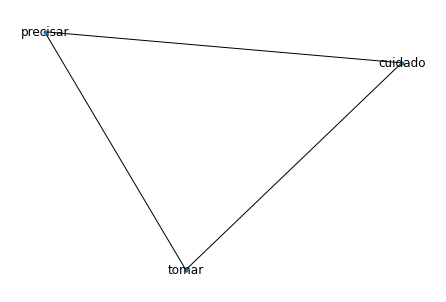

In [12]:

#exemplo de grafo com nx
edges = [('precisar', 'tomar'), ('precisar', 'cuidado'), ('tomar','cuidado')]
G = nx.Graph()
G.add_edges_from(edges)
nx.draw_spring(G,node_size = 10, with_labels = True)

In [38]:
#atributos do tweet

path  = "tweetsJson/wilsonwitzel.json"
arq = open(path)
data  = json.load(arq)
i=0
for (key,value) in data.items():
        print(key)
        print('\n')

arq.close()

_id


contributors


coordinates


created_at


display_text_range


entities


favorite_count


favorited


full_text


geo


id


id_str


in_reply_to_screen_name


in_reply_to_status_id


in_reply_to_status_id_str


in_reply_to_user_id


in_reply_to_user_id_str


is_quote_status


lang


place


possibly_sensitive


retweet_count


retweeted


source


truncated


user


quoted_status


quoted_status_id


quoted_status_id_str


quoted_status_permalink


extended_entities


retweeted_status




In [16]:
#faz rede de cliques a partir de arquivo
path = "Janelas/1-2_8-2.txt"
arq = open(path)
edges,cliques,qtdNodesInitialState = netMetrics.extractVectorFromFile(arq)
arq.close()

In [5]:
rede_justaposta_gephi('Janelas/8-4_13-4.txt')

sucesso, cheque a pasta graph


In [38]:
#gerando as wordclouds

for i in range(8,16):
    caminho = 'Janelas/T'+str(i)+'.txt'
    destino = 'T'+str(i)
    nuvem_de_palavras(caminho,destino)

Janelas/T8.txt é um arquivo vazio
Janelas/T9.txt é um arquivo vazio
sucesso, cheque Wordclouds/Janelas/T10.txt
Janelas/T11.txt é um arquivo vazio
sucesso, cheque Wordclouds/Janelas/T12.txt
Janelas/T13.txt é um arquivo vazio
Janelas/T14.txt é um arquivo vazio
Janelas/T15.txt é um arquivo vazio


In [3]:
networkMetrics.principal(13, 'resultados_2020_marco_maio') #gera as metricas das janelas de 0 a 12 (nesse caso)

graph


198
302


In [14]:
teste = {}
teste['a'] = 12
teste['b'] = 1
teste['c'] = 14
teste['d'] = 1
teste['e'] = 2
teste

{'a': 12, 'b': 1, 'c': 14, 'd': 1, 'e': 2}

In [16]:
import operator
sorted_x = sorted(teste.items(), key=operator.itemgetter(1))
sorted_x.reverse()
sorted_x

[('c', 14), ('a', 12), ('e', 2), ('d', 1), ('b', 1)]

In [5]:
#gera bag of words

for i in range(13):
    origem = 'Janelas/T'+str(i)+'.txt'
    destino = 'T'+str(i)
    bag_of_words(origem,destino)

198
302
sucesso, cheque a pasta bagOfWords
147
191
sucesso, cheque a pasta bagOfWords
326
529
sucesso, cheque a pasta bagOfWords
378
662
sucesso, cheque a pasta bagOfWords
324
540
sucesso, cheque a pasta bagOfWords
407
703
sucesso, cheque a pasta bagOfWords
163
216
sucesso, cheque a pasta bagOfWords
12
12
sucesso, cheque a pasta bagOfWords
0
0
sucesso, cheque a pasta bagOfWords
0
0
sucesso, cheque a pasta bagOfWords
2
2
sucesso, cheque a pasta bagOfWords
0
0
sucesso, cheque a pasta bagOfWords
131
172
sucesso, cheque a pasta bagOfWords


In [3]:
origem = "Janelas/T0.txt"
destino = "T0"

for i in range(13):
    origem = "Janelas/T"+str(i)+".txt"
    destino  = "T"+str(i)
    graus_e_vizinhos(origem, destino)


sucesso, cheque a pasta Graus
sucesso, cheque a pasta Graus
sucesso, cheque a pasta Graus
sucesso, cheque a pasta Graus
sucesso, cheque a pasta Graus
sucesso, cheque a pasta Graus
sucesso, cheque a pasta Graus
sucesso, cheque a pasta Graus
sucesso, cheque a pasta Graus
sucesso, cheque a pasta Graus
sucesso, cheque a pasta Graus
sucesso, cheque a pasta Graus
sucesso, cheque a pasta Graus


In [6]:
processa_e_agrupa_tweets_json(2021)

processando GovernoDoCeara

processando rogeriomarinho

processando jdoriajr

processando GermannJoae

processando CarmenLucia_SR

processando wilsonlimaAM

processando Casagrande_ES

processando RafaelGreca_

processando saudegoias

processando alexandre

processando GovernoRO

processando CarlosMoises

processando Astro_Pontes

processando MinLuizRamos

processando ernestofaraujo

processando wdiaspi

processando informesead

processando ronaldocaiado

processando casacivilbr

processando AdvocaciaGeral

processando IrisRezendeM

sample tweet: Na ativação da Capitania Fluvial da Marinha em Goiás e investidura do cargo de Capitão dos Portos - Capitão de Fragata Felipe Santiago. https://t.co/ynrHDQWfPM

processando EdvaldoNogueira

processando marchezan_

processando fabiovboas

processando prefalvaro45

processando sesacre

processando PauloCamara40

processando SemsaManaus

processando jorgeofco

processando SaudeMG

processando CamiloSantanaCE

processando FR_BSB

processando saudeg

In [7]:
inicio = "1-1"
fim = "31-12"
janela = 5

agrupaPorJanela2(inicio, fim, janela)

janela aumentou, agora vai ate 11-1

E o dia agora é6-1

janela aumentou, agora vai ate 16-1

E o dia agora é11-1

janela aumentou, agora vai ate 21-1

E o dia agora é16-1

janela aumentou, agora vai ate 26-1

E o dia agora é21-1

janela aumentou, agora vai ate 1-2

E o dia agora é26-1

janela aumentou, agora vai ate 6-2

E o dia agora é1-2

janela aumentou, agora vai ate 11-2

E o dia agora é6-2

janela aumentou, agora vai ate 16-2

E o dia agora é11-2

janela aumentou, agora vai ate 21-2

E o dia agora é16-2

janela aumentou, agora vai ate 26-2

E o dia agora é21-2

janela aumentou, agora vai ate 3-3

E o dia agora é26-2

janela aumentou, agora vai ate 8-3

E o dia agora é3-3

janela aumentou, agora vai ate 13-3

E o dia agora é8-3

janela aumentou, agora vai ate 18-3

E o dia agora é13-3

janela aumentou, agora vai ate 23-3

E o dia agora é18-3

janela aumentou, agora vai ate 28-3

E o dia agora é23-3

janela aumentou, agora vai ate 3-4

E o dia agora é28-3

janela aumentou, agora v

In [10]:
agrupaPorJanela(inicio, fim,janela)

janela aumentou, agora vai ate 11-1

E o dia agora é6-1

janela aumentou, agora vai ate 16-1

E o dia agora é11-1

janela aumentou, agora vai ate 21-1

E o dia agora é16-1

janela aumentou, agora vai ate 26-1

E o dia agora é21-1

janela aumentou, agora vai ate 1-2

E o dia agora é26-1

janela aumentou, agora vai ate 6-2

E o dia agora é1-2

janela aumentou, agora vai ate 11-2

E o dia agora é6-2

janela aumentou, agora vai ate 16-2

E o dia agora é11-2

janela aumentou, agora vai ate 21-2

E o dia agora é16-2

janela aumentou, agora vai ate 26-2

E o dia agora é21-2

janela aumentou, agora vai ate 3-3

E o dia agora é26-2

janela aumentou, agora vai ate 8-3

E o dia agora é3-3

janela aumentou, agora vai ate 13-3

E o dia agora é8-3

janela aumentou, agora vai ate 18-3

E o dia agora é13-3

janela aumentou, agora vai ate 23-3

E o dia agora é18-3

janela aumentou, agora vai ate 28-3

E o dia agora é23-3

janela aumentou, agora vai ate 3-4

E o dia agora é28-3

janela aumentou, agora v

processando SaudePE

processando JusticaGovBR

processando RobertoCamposN1

processando drcarloseduard

processando GovernoDoCeara

processando GovernoES

processando costa_rui

processando maurocarlesse

processando casacivilbr

processando marquinhostrad_

processando AmendoncaMJSP

processando TeichNelson

processando gladsoncameli

processando rsallesmma

processando ernestofaraujo

processando Raimund30319810

processando wilsonwitzel

processando PauloCamara40

processando GermannJoae

processando Saude_Maranhao

processando gilmarmendes

processando saudepbgov

processando Sesau_Roraima

processando GeanLoureiro

processando saudepublicasc

processando alexandre

processando DamaresAlves

processando LucianoRezende

processando DefesaGovBr

processando fatimabezerra

processando brunocovas

processando celmarcosrocha

processando PMMacapa

processando lhmandetta

processando CinthiaCRibeiro

processando SaudeEdmar

sample tweet: Agradeço ao ministro @lhmandetta pelo trabalho à f

In [5]:
cria_pastas_usuarios()

In [17]:
processa_tweets_all_users(2020)

processando SaudePE

processando JusticaGovBR

processando RobertoCamposN1

processando drcarloseduard

processando GovernoDoCeara

processando GovernoES

processando costa_rui

processando maurocarlesse

processando casacivilbr

processando marquinhostrad_

processando AmendoncaMJSP

processando TeichNelson

processando gladsoncameli

processando rsallesmma

processando ernestofaraujo

processando Raimund30319810

processando wilsonwitzel

processando PauloCamara40

processando GermannJoae

processando Saude_Maranhao

processando gilmarmendes

processando saudepbgov

processando Sesau_Roraima

processando GeanLoureiro

processando saudepublicasc

processando alexandre

processando DamaresAlves

processando LucianoRezende

processando DefesaGovBr

processando fatimabezerra

processando brunocovas

processando celmarcosrocha

processando PMMacapa

processando lhmandetta

processando CinthiaCRibeiro

processando SaudeEdmar

sample tweet: Agradeço ao ministro @lhmandetta pelo trabalho à f

In [20]:
processa_e_agrupa_tweets_json(2020)

processando SaudePE

processando JusticaGovBR

processando RobertoCamposN1

processando drcarloseduard

processando GovernoDoCeara

processando GovernoES

processando costa_rui

processando maurocarlesse

processando casacivilbr

processando marquinhostrad_

processando AmendoncaMJSP

processando TeichNelson

processando gladsoncameli

processando rsallesmma

processando ernestofaraujo

processando Raimund30319810

processando wilsonwitzel

processando PauloCamara40

processando GermannJoae

processando Saude_Maranhao

processando gilmarmendes

processando saudepbgov

processando Sesau_Roraima

processando GeanLoureiro

processando saudepublicasc

processando alexandre

processando DamaresAlves

processando LucianoRezende

processando DefesaGovBr

processando fatimabezerra

processando brunocovas

processando celmarcosrocha

processando PMMacapa

processando lhmandetta

processando CinthiaCRibeiro

processando SaudeEdmar

sample tweet: Agradeço ao ministro @lhmandetta pelo trabalho à f

In [27]:
agrupaPorJanela2('13-3','18-5',5)
agrupaPorJanela('13-3','18-5',5)

janela aumentou, agora vai ate 23-3

E o dia agora é18-3

janela aumentou, agora vai ate 28-3

E o dia agora é23-3

janela aumentou, agora vai ate 3-4

E o dia agora é28-3

janela aumentou, agora vai ate 8-4

E o dia agora é3-4

janela aumentou, agora vai ate 13-4

E o dia agora é8-4

janela aumentou, agora vai ate 18-4

E o dia agora é13-4

janela aumentou, agora vai ate 23-4

E o dia agora é18-4

janela aumentou, agora vai ate 28-4

E o dia agora é23-4

janela aumentou, agora vai ate 3-5

E o dia agora é28-4

janela aumentou, agora vai ate 8-5

E o dia agora é3-5

janela aumentou, agora vai ate 13-5

E o dia agora é8-5

janela aumentou, agora vai ate 18-5

E o dia agora é13-5

janela aumentou, agora vai ate 23-5

E o dia agora é18-5

janela aumentou, agora vai ate 23-3

E o dia agora é18-3

janela aumentou, agora vai ate 28-3

E o dia agora é23-3

janela aumentou, agora vai ate 3-4

E o dia agora é28-3

janela aumentou, agora vai ate 8-4

E o dia agora é3-4

janela aumentou, agora va

In [35]:
agrupaJanelaAllUsers('13-3','18-5',5)

FileNotFoundError: [Errno 2] No such file or directory: 'Users/SaudePE/Janelas/000_13-3_18-3.txt'

In [19]:
#!pip install python-lorem
#!pip install english-words      
    

  Created wheel for english-words: filename=english_words-1.1.0-py3-none-any.whl size=1106679 sha256=db84179ecbc0c958b9d8efe7113fba883225cc8e8359db491a97d76ed50f92ae
  Stored in directory: c:\users\juann\appdata\local\pip\cache\wheels\0e\24\52\b4989db82a438482aa65b3c6c0537e988fd40546b792747b1a
Successfully built english-words


In [38]:
#cria_diretorios_janelas_users()

In [47]:
destino = 'basesSinteticas/pouco_conexa.txt'
base_sintetica_pouco_conexa(destino)

destino = 'basesSinteticas/conexa.txt'
base_sintetica_conexa(destino)

destino = 'basesSinteticas/muito_conexa.txt'
base_sintetica_muito_conexa(destino)


sucesso, cheque o local de destino
sucesso, cheque o local de destino


In [3]:
origem = 'basesSinteticas/pouco_conexa.txt'
destino = 'pouco_conexa'
networkMetrics.principal2(origem,destino)

Sucesso, cheque o arquivo destino na pasta graph


In [4]:
origem = 'basesSinteticas/conexa.txt'
destino = 'conexa'
networkMetrics.principal2(origem,destino)

Sucesso, cheque o arquivo destino na pasta graph


In [5]:
origem = 'basesSinteticas/muito_conexa.txt'
destino = 'muito_conexa'
networkMetrics.principal2(origem,destino)

Sucesso, cheque o arquivo destino na pasta graph


In [3]:

path = 'basesSinteticas/pouco_conexa.txt'
destino_nodes = "nodes_pouco_conexa"
destino_edges = "edges_pouco_conexa"
rede_justaposta_gephi(path, destino_nodes, destino_edges)

sucesso, cheque a pasta graph


In [4]:
path = 'basesSinteticas/conexa.txt'
destino_nodes = "nodes_conexa"
destino_edges = "edges_conexa"
rede_justaposta_gephi(path, destino_nodes, destino_edges)

sucesso, cheque a pasta graph


In [5]:
path = 'basesSinteticas/muito_conexa.txt'
destino_nodes = "nodes_muito_conexa"
destino_edges = "edges_muito_conexa"
rede_justaposta_gephi(path, destino_nodes, destino_edges)

sucesso, cheque a pasta graph


In [12]:
'''ToDo:Fazer bases sinteticas formando uma janela conexa de alguns dias e ir 
#transicionando gradualmente pra uma janela desconexa
#Fazer o mesmo com conexa pra conexa e
#desconexa para conexa
#Método: Fazer a base com 200 linhas de 20 palavras (=4000 palavras), e cada dia são 20 linhas
#é como se fossem bases de 10 dias
#e farei um deslize de apenas um dia entre as janelas
#então gerarei as metricas de cada uma e verei os resultados
'''
tam_linha = 20
num_linhas = 200

destino = 'basesSinteticas/pouco_conexa_teste.txt'
base_sintetica_pouco_conexa(destino, tam_linha, num_linhas)

destino = 'basesSinteticas/conexa_teste.txt'
base_sintetica_conexa(destino, tam_linha, num_linhas)

destino = 'basesSinteticas/conexa2_teste.txt'
base_sintetica_conexa(destino, tam_linha, num_linhas)




sucesso, cheque o local de destino
sucesso, cheque o local de destino
sucesso, cheque o local de destino


In [4]:
#Fazendo de pouco conexa para conexa

#pouco eficiente mas funciona
def transicao_janelas_sinteticas(base1,base2,nome_destino,n_linhas=200,tam_dia=20,tam_linha=20):
    '''Considerando que os arquivos das janelas originais tem n_linhas linhas, 
    e que cada dia tem tam_dia linhas, faz as n_linhas/tam_dia -1 janelas de transição
    entre a primeira(base1) e a segunda(base2) janelas, com deslize de um dia.
    Exemplo: se as janelas originais tem 200 linhas, e cada dia são 20 linhas, são um total
    de 10 dias em cada janela original.
    A primeira janela produzida vai do segundo dia do primeiro arquivo até o primeiro(inclusive)
    do segundo;e então pula tam_dia linhas no primeiro arquivo pra ir do terceiro dia do primeiro
    até o segundo dia do segundo, e por aí vai, até ir do ultimo dia do primeiro para o nono do 
    segundo(inclusive)
    as janelas geradas serao escritas no formato <nome_destino>1.txt, <nome_destino>2.txt, etc.,
    na pasta basesSinteticas/Transicao
    '''
    
    num_janelas = (n_linhas//tam_dia)-1 #este é o número de janelas que serão geradas com as
                                          #bases dadas, vide exemplo acima
    
    arq1 = open(base1,'r')
    lista_arq1 = []

    for line in arq1:
        lista_arq1.append(line.split())
    arq1.close()
    
    arq2 = open(base2,'r')
    lista_arq2 = []
    
    for line in arq2:
        lista_arq2.append(line.split())
    arq2.close()
    
    inicio_arq1 = tam_dia #começa do indice tam_dia, pegando portanto a partir do segundo dia
    fim_arq2 = tam_dia #termina no indice tam_dia-1 ;está assim pro range
                        #e pega até o primeiro dia do segundo arquivo na primeira iteração
        
    for i in range(num_janelas):
        str_destino = 'basesSinteticas/Transicao/'+nome_destino+str(i+1)+'.txt'
        destino = open(str_destino,'w+')
        for j in range(inicio_arq1, len(lista_arq1)): #vai escrever num_linhas - inicio_arq1 linhas
            linha = lista_arq1[j] 
            destino.write(linha[0])#escreve a primeira palavra sem o espaço antes
            for k in range(1,tam_linha):#escrevendo o resto das palavras;são tam_linha palavras
                destino.write(' ')
                destino.write(linha[k])
            destino.write('\n')
    
        #aqui já escreveu tudo o que tinha que escrever do primeiro arquivo pra essa janela
        inicio_arq1 += tam_dia #vai começar a próxima do próximo dia
        
        for j in range(fim_arq2): #vai escrever fim_arq2 linhas
            linha = lista_arq2[j] 
            destino.write(linha[0]) #escreve a primeira palavra sem o espaço antes
            for k in range(1,tam_linha): #escrevendo o resto das palavras;são tam_linha palavras
                destino.write(' ')
                destino.write(linha[k])
            destino.write('\n')
    
        fim_arq2+=tam_dia #na proxima vez vai pegar o segundo arquivo até o próximo dia
        #quando chegou aqui ja escreveu uma janela inteira
    
        destino.close()
    
    print("sucesso, cheque os "+str(num_janelas)+" arquivos na pasta basesSinteticas/Transicao")
        
#desconexa pra conexa
base1 = 'basesSinteticas/pouco_conexa_teste.txt'
base2 = 'basesSinteticas/conexa_teste.txt'
nome_destino = 'desconexa_pra_conexa'
transicao_janelas_sinteticas(base1,base2,nome_destino)

#conexa pra conexa
base1 = 'basesSinteticas/conexa_teste.txt'
base2 = 'basesSinteticas/conexa2_teste.txt'
nome_destino = 'conexa_pra_conexa'
transicao_janelas_sinteticas(base1,base2,nome_destino)

#conexa pra desconexa
base1 = 'basesSinteticas/conexa_teste.txt'
base2 = 'basesSinteticas/pouco_conexa_teste.txt'
nome_destino = 'conexa_pra_desconexa'
transicao_janelas_sinteticas(base1,base2,nome_destino)



sucesso, cheque os 9 arquivos na pasta basesSinteticas/Transicao
sucesso, cheque os 9 arquivos na pasta basesSinteticas/Transicao
sucesso, cheque os 9 arquivos na pasta basesSinteticas/Transicao


In [18]:
 #gerando métricas de todas essas transições
nome_base = 'basesSinteticas/Transicao/desconexa_pra_conexa'
for i in range(1,10):
    origem = nome_base+str(i)+'.txt'
    destino = nome_base[26:]+str(i)
    networkMetrics.principal2(origem,destino)


nome_base = 'basesSinteticas/Transicao/conexa_pra_conexa'
for i in range(1,10):
    origem = nome_base+str(i)+'.txt'
    destino = nome_base[26:]+str(i)
    networkMetrics.principal2(origem,destino)
    
nome_base = 'basesSinteticas/Transicao/conexa_pra_desconexa'
for i in range(1,10):
    origem = nome_base+str(i)+'.txt'
    destino = nome_base[26:]+str(i)
    networkMetrics.principal2(origem,destino)


Sucesso, cheque o arquivo destino na pasta graph
Sucesso, cheque o arquivo destino na pasta graph
Sucesso, cheque o arquivo destino na pasta graph
Sucesso, cheque o arquivo destino na pasta graph
Sucesso, cheque o arquivo destino na pasta graph
Sucesso, cheque o arquivo destino na pasta graph
Sucesso, cheque o arquivo destino na pasta graph
Sucesso, cheque o arquivo destino na pasta graph
Sucesso, cheque o arquivo destino na pasta graph
Sucesso, cheque o arquivo destino na pasta graph
Sucesso, cheque o arquivo destino na pasta graph
Sucesso, cheque o arquivo destino na pasta graph
Sucesso, cheque o arquivo destino na pasta graph
Sucesso, cheque o arquivo destino na pasta graph
Sucesso, cheque o arquivo destino na pasta graph
Sucesso, cheque o arquivo destino na pasta graph
Sucesso, cheque o arquivo destino na pasta graph
Sucesso, cheque o arquivo destino na pasta graph
Sucesso, cheque o arquivo destino na pasta graph
Sucesso, cheque o arquivo destino na pasta graph
Sucesso, cheque o ar

In [28]:
#Analisar metricas das transicoes entre as bases sinteticas

#Pegar as seguites métricas:
#graph density[3]
#initial density[4]
#networkDegree[5]
#clustering coefficient[7]
#fragmentation[8]
#fragClique[9]
#Variação de densidade: graphDensity / initiaDensity 

metricas_desconexa_pra_conexa =[]
nome_base = 'basesSinteticas/Transicao/Metricas/desconexa_pra_conexa'
for i in range(1,10):
    path = nome_base+str(i)+'.csv'
    arq = open(path, 'r')
    j=0
    linha = []
    metricas = []
    for line in arq: #pula o cabeçalho
        if(j==0):
            j=1
            continue
        
        linha = line.split(',')
        graph_density = float(linha[3])
        initial_density  = float(linha[4])
        variacao = graph_density/initial_density -1
        metricas.append(variacao)
        metricas.append((float(linha[5])/float(linha[6])) - 1)#varnetworkDegree
        metricas.append(float(linha[7]))#clustering coefficient
        metricas.append(float(linha[8]))#fragmentation
        metricas.append(float(linha[9]))#fragCliques
        
        metricas_desconexa_pra_conexa.append(metricas)
        
    
metricas_conexa_pra_conexa =[]
nome_base = 'basesSinteticas/Transicao/Metricas/conexa_pra_conexa'
for i in range(1,10):
    path = nome_base+str(i)+'.csv'
    arq = open(path, 'r')
    j=0
    linha = []
    metricas = []
    for line in arq: #pula o cabeçalho
        if(j==0):
            j=1
            continue
        
        linha = line.split(',')
        graph_density = float(linha[3])
        initial_density  = float(linha[4])
        variacao = graph_density/initial_density -1
        metricas.append(variacao)
        metricas.append((float(linha[5])/float(linha[6])) - 1)#varnetworkDegree
        metricas.append(float(linha[7]))#clustering coefficient
        metricas.append(float(linha[8]))#fragmentation
        metricas.append(float(linha[9]))#fragCliques
        
        metricas_conexa_pra_conexa.append(metricas)        

    
metricas_conexa_pra_desconexa =[]
nome_base = 'basesSinteticas/Transicao/Metricas/conexa_pra_desconexa'
for i in range(1,10):
    path = nome_base+str(i)+'.csv'
    arq = open(path, 'r')
    j=0
    linha = []
    metricas = []
    for line in arq: #pula o cabeçalho
        if(j==0):
            j=1
            continue
        
        linha = line.split(',')
        graph_density = float(linha[3])
        initial_density  = float(linha[4])
        variacao = graph_density/initial_density -1
        metricas.append(variacao)
        metricas.append((float(linha[5])/float(linha[6])) - 1)#varnetworkDegree
        metricas.append(float(linha[7]))#clustering coefficient
        metricas.append(float(linha[8]))#fragmentation
        metricas.append(float(linha[9]))#fragCliques
        
        metricas_conexa_pra_desconexa.append(metricas)
    



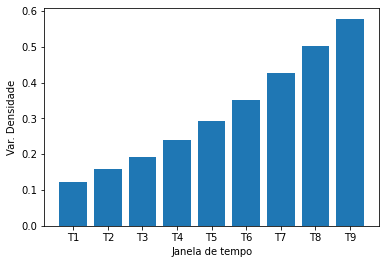

[0.12257513926490948, 0.1582068148013822, 0.19190373188334875, 0.24072615265180697, 0.29393166928282133, 0.3523681492627342, 0.4259279318221265, 0.5031457125493768, 0.5787171788708585]


In [31]:
#Plot: DESCONEXA PARA CONEXA

ordem_das_metricas = ['variação de densidade', 'varNetworkDegree', 'clustering coefficient', 'fragmentation',
                     'fragCliques']



titulo = ordem_das_metricas[0]+': desconexa pra conexa'
var_dens_desc_p_conex = []
for i in range(9):
    metricas = metricas_desconexa_pra_conexa[i]
    var_dens_desc_p_conex.append(metricas[0])
    
#x = [i for i in range(1,10)]
x = ["T"+str(i) for i in range(1,10)]
y = var_dens_desc_p_conex
plt.bar(x,y)
#plt.title(titulo)
plt.xlabel("Janela de tempo")
plt.ylabel("Var. Densidade")
plt.show()
print(y)

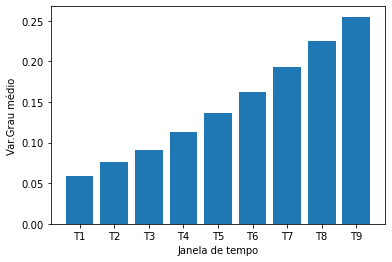

[0.05913378355743948, 0.07564329748806653, 0.0911374834149643, 0.11314585524381737, 0.1366009734430289, 0.1618794657413023, 0.19297047886247953, 0.22478539541067688, 0.25515127058872333]


In [32]:
titulo = ordem_das_metricas[1]+': desconexa pra conexa'
var_grau_medio_desc_p_conex = []
for i in range(9):
    metricas = metricas_desconexa_pra_conexa[i]
    var_grau_medio_desc_p_conex.append(metricas[1])
    
#x = [i for i in range(1,10)]
y = var_grau_medio_desc_p_conex
plt.bar(x,y)
#plt.title(titulo)
plt.xlabel("Janela de tempo")
plt.ylabel("Var.Grau médio")
plt.show()
print(y)

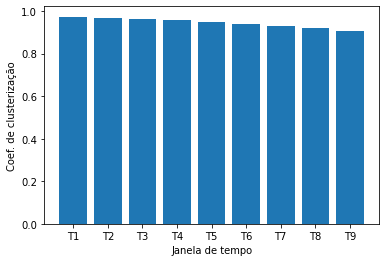

[0.9729559362550837, 0.9673344723924585, 0.9628804713106791, 0.9557485996120855, 0.9479122710709575, 0.9397709826072799, 0.9292712648480892, 0.9180808365582517, 0.9067916747376454]


In [33]:
titulo = ordem_das_metricas[2]+': desconexa pra conexa'
coef_cluster_desc_p_conex = []
for i in range(9):
    metricas = metricas_desconexa_pra_conexa[i]
    coef_cluster_desc_p_conex.append(metricas[2])
    
#x = [i for i in range(1,10)]
y = coef_cluster_desc_p_conex
plt.bar(x,y)
#plt.title(titulo)
plt.xlabel("Janela de tempo")
plt.ylabel("Coef. de clusterização")
plt.show()
print(y)

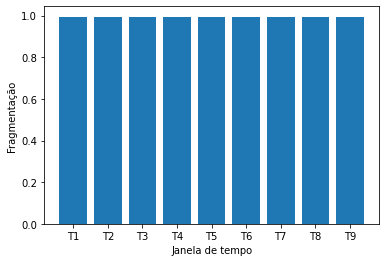

[0.9946598297497512, 0.9944885804303611, 0.994327782233194, 0.9940941877641315, 0.9938391429134807, 0.993559716486376, 0.9932083322002556, 0.992839781549459, 0.9924792015026136]


In [34]:
titulo = ordem_das_metricas[3]+': desconexa pra conexa'
frag_desc_p_conex = []
for i in range(9):
    metricas = metricas_desconexa_pra_conexa[i]
    frag_desc_p_conex.append(metricas[3])
    
#x = [i for i in range(1,10)]
y = frag_desc_p_conex
plt.bar(x,y)
#plt.title(titulo)
plt.xlabel("Janela de tempo")
plt.ylabel("Fragmentação")
plt.show()
print(y)

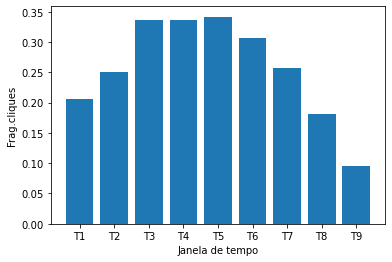

[0.20603015075376885, 0.25125628140703515, 0.33668341708542715, 0.33668341708542715, 0.3417085427135678, 0.3065326633165829, 0.2562814070351759, 0.18090452261306533, 0.09547738693467336]


In [35]:
titulo = ordem_das_metricas[4]+': desconexa pra conexa'
frag_cliques_desc_p_conex = []
for i in range(9):
    metricas = metricas_desconexa_pra_conexa[i]
    frag_cliques_desc_p_conex.append(metricas[4])
    
#x = [i for i in range(1,10)]
y = frag_cliques_desc_p_conex
plt.bar(x,y)
#plt.title(titulo)
plt.xlabel("Janela de tempo")
plt.ylabel("Frag.cliques")
plt.show()
print(y)

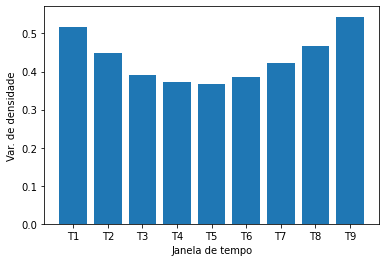

[0.5174398827072688, 0.4486401258730133, 0.39033649802343207, 0.37324840943126913, 0.3683557145510008, 0.38455933648554375, 0.42177567142377925, 0.4666091363048974, 0.5440322635818209]


In [36]:
#PLOT: CONEXA PRA CONEXA

titulo = ordem_das_metricas[0]+': conexa pra conexa'
var_dens_conex_p_conex = []
for i in range(9):
    metricas = metricas_conexa_pra_conexa[i]
    var_dens_conex_p_conex.append(metricas[0])
    
#x = [i for i in range(1,10)]
y = var_dens_conex_p_conex
plt.bar(x,y)
#plt.title(titulo)
plt.xlabel("Janela de tempo")
plt.ylabel("Var. de densidade")
plt.show()
print(y)

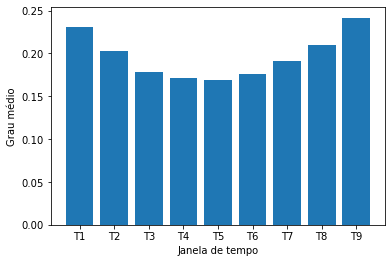

[0.23111614107527156, 0.20291132793909594, 0.1784988879918583, 0.1712799089947028, 0.169160360406714, 0.17607891613428972, 0.19168841294183014, 0.21025510122688318, 0.24171236801184892]


In [37]:
titulo = ordem_das_metricas[1]+': conexa pra conexa'
var_grau_medio_conex_p_conex = []
for i in range(9):
    metricas = metricas_conexa_pra_conexa[i]
    var_grau_medio_conex_p_conex.append(metricas[1])
    
#x = [i for i in range(1,10)]
y = var_grau_medio_conex_p_conex
x = ["T"+str(i) for i in range(1,10)]
plt.bar(x,y)
#plt.title(titulo)
plt.xlabel("Janela de tempo")
plt.ylabel("Grau médio")
plt.show()
print(y)

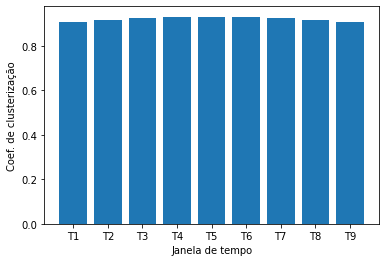

[0.9065264082250628, 0.915304632677924, 0.9265564137403952, 0.929536013518255, 0.9318575548871062, 0.9299871466529539, 0.9254867220551222, 0.9192808668770689, 0.9092718602528893]


In [38]:
titulo = ordem_das_metricas[2]+': conexa pra conexa'
coef_cluster_conex_p_conex = []
for i in range(9):
    metricas = metricas_conexa_pra_conexa[i]
    coef_cluster_conex_p_conex.append(metricas[2])
    
#x = [i for i in range(1,10)]
y = coef_cluster_conex_p_conex
plt.bar(x,y)
#plt.title(titulo)
plt.xlabel("Janela de tempo")
plt.ylabel("Coef. de clusterização")
plt.show()
print(y)

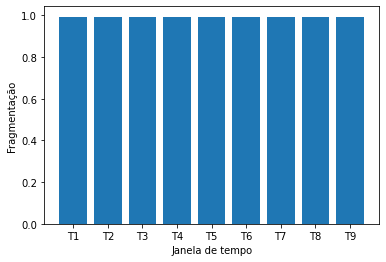

[0.9927777981868263, 0.9931056163564812, 0.9933836193599459, 0.9934654601542062, 0.9934883984076313, 0.9934114638897706, 0.993233296365086, 0.993019004840769, 0.9926495051956392]


In [39]:
titulo = ordem_das_metricas[3]+': conexa pra conexa'
frag_conex_p_conex = []
for i in range(9):
    metricas = metricas_conexa_pra_conexa[i]
    frag_conex_p_conex.append(metricas[3])
    
#x = [i for i in range(1,10)]
y = frag_conex_p_conex
plt.bar(x,y)
#plt.title(titulo)
plt.xlabel("Janela de tempo")
plt.ylabel("Fragmentação")
plt.show()
print(y)

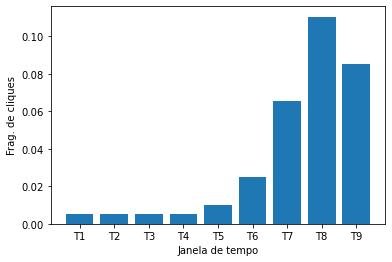

[0.005025125628140704, 0.005025125628140704, 0.005025125628140704, 0.005025125628140704, 0.010050251256281407, 0.02512562814070352, 0.06532663316582915, 0.11055276381909548, 0.08542713567839195]


In [40]:
titulo = ordem_das_metricas[4]+': conexa pra conexa'
frag_cliques_conex_p_conex = []
for i in range(9):
    metricas = metricas_conexa_pra_conexa[i]
    frag_cliques_conex_p_conex.append(metricas[4])
    
#x = [i for i in range(1,10)]
y = frag_cliques_conex_p_conex
plt.bar(x,y)
#plt.title(titulo)
plt.xlabel("Janela de tempo")
plt.ylabel("Frag. de cliques")
plt.show()
print(y)

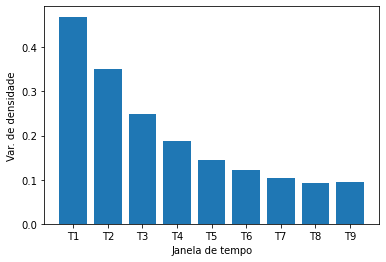

[0.4693193972710423, 0.3500024646104263, 0.2481890176046122, 0.18716697121322645, 0.14380947877113792, 0.12155966615663649, 0.10394612457563435, 0.09183785076441953, 0.09469606385975271]


In [41]:
#PLOT: CONEXA PRA DESCONEXA

titulo = ordem_das_metricas[0]+': conexa pra desconexa'
y = []
for i in range(9):
    metricas = metricas_conexa_pra_desconexa[i]
    y.append(metricas[0])
    
#x = [i for i in range(1,10)]
plt.bar(x,y)
#plt.title(titulo)
plt.xlabel("Janela de tempo")
plt.ylabel("Var. de densidade")
plt.show()
print(y)

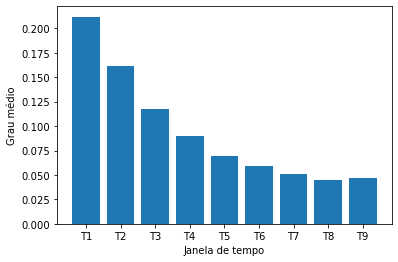

[0.21193111446575696, 0.16187352470843774, 0.11734308356002066, 0.08977058137887872, 0.06971076566406498, 0.05928196583484291, 0.050930202635026456, 0.045150110709175184, 0.046517392382088074]


In [42]:


titulo = ordem_das_metricas[1]+': conexa pra desconexa'
y = []
for i in range(9):
    metricas = metricas_conexa_pra_desconexa[i]
    y.append(metricas[1])
    
#x = [i for i in range(1,10)]
plt.bar(x,y)
#plt.title(titulo)
plt.xlabel("Janela de tempo")
plt.ylabel("Grau médio")
plt.show()
print(y)

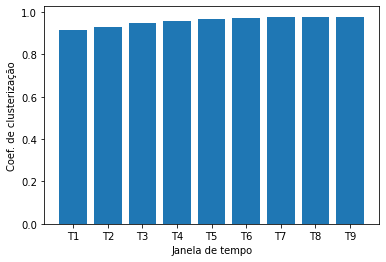

[0.9141463938231832, 0.9307642331226067, 0.9491450683737496, 0.9591126970055002, 0.9674389201357851, 0.9717732713793726, 0.975447280895052, 0.9779494214632816, 0.977340118595953]


In [43]:

titulo = ordem_das_metricas[2]+': conexa pra desconexa'
y = []
for i in range(9):
    metricas = metricas_conexa_pra_desconexa[i]
    y.append(metricas[2])
    
#x = [i for i in range(1,10)]
plt.bar(x,y)
#plt.title(titulo)
plt.xlabel("Janela de tempo")
plt.ylabel("Coef. de clusterização")
plt.show()
print(y)

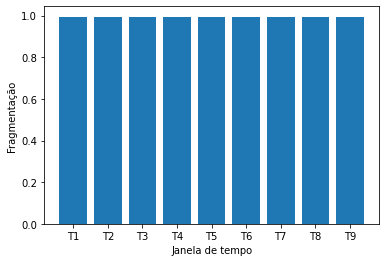

[0.9930125447500626, 0.993582166259797, 0.9940677450946228, 0.9943586555892473, 0.9945649739682273, 0.9946709787854978, 0.9947546684362405, 0.9948122002851105, 0.9947986196631613]


In [44]:
titulo = ordem_das_metricas[3]+': conexa pra desconexa'
y = []
for i in range(9):
    metricas = metricas_conexa_pra_desconexa[i]
    y.append(metricas[3])
    
#x = [i for i in range(1,10)]
plt.bar(x,y)
#plt.title(titulo)
plt.xlabel("Janela de tempo")
plt.ylabel("Fragmentação")
plt.show()
print(y)

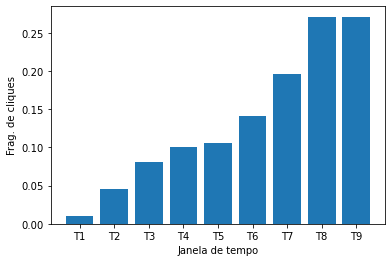

[0.010050251256281407, 0.04522613065326633, 0.08040201005025126, 0.10050251256281408, 0.10552763819095477, 0.1407035175879397, 0.19597989949748743, 0.271356783919598, 0.271356783919598]


In [45]:
titulo = ordem_das_metricas[4]+': conexa pra desconexa'
y = []
for i in range(9):
    metricas = metricas_conexa_pra_desconexa[i]
    y.append(metricas[4])
    
x = ["T"+str(i) for i in range(1,10)]
plt.bar(x,y)
#plt.title(titulo)
plt.xlabel("Janela de tempo")
plt.ylabel("Frag. de cliques")
plt.show()
print(y)

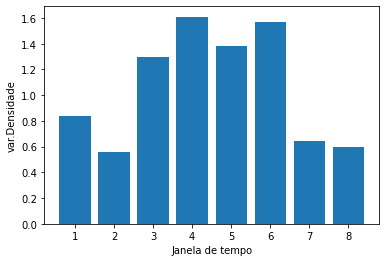

In [46]:
#fazendo um grafico por metrica englobando todas as janelas de 2020
#COVID!!!!! (começa aqui)



path = "graph/resultados_2020_marco_maio.csv"
#path = "graph/deslize_1_resultados_marco_maio_2020.csv"
metricas,j = plot_metricas_csv(path)
x = [i for i in range(1,j)]
plt.bar(x,metricas['var_densidade'])
#plt.title("variação de densidade 03/2020 a 05/2020")
plt.xlabel("Janela de tempo")
plt.ylabel("var.Densidade")
plt.show()


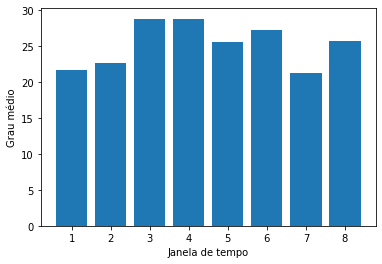

In [40]:
plt.bar(x,metricas['network_degree'])
#plt.title("grau médio 03/2020 a 05/2020")
plt.xlabel("Janela de tempo")
plt.ylabel("Grau médio")
plt.show()

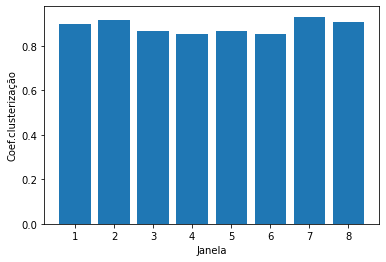

In [17]:
plt.bar(x,metricas['clustering_coefficient'])
#plt.title("Coeficiente de clusterização de 03/2020 a 05/2020")
plt.xlabel("Janela")
plt.ylabel("Coef.clusterização")
plt.show()

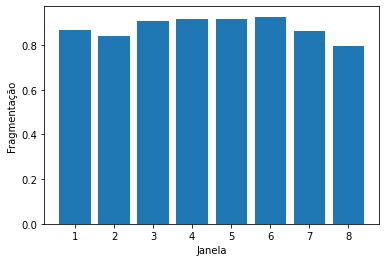

In [18]:
plt.bar(x,metricas['fragmentation'])
#plt.title("Fragmentação de 03/2020 a 05/2020")
plt.xlabel("Janela")
plt.ylabel("Fragmentação")
plt.show()

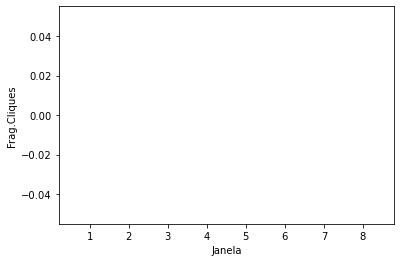

In [19]:
plt.bar(x,metricas['frag_cliques'])
#plt.title("Fragmentação de cliques de 03/2020 a 05/2020")
plt.xlabel("Janela")
plt.ylabel("Frag.Cliques")
plt.show()

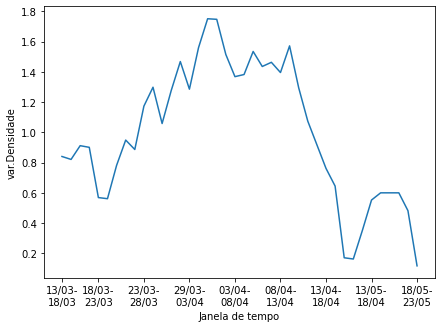

In [72]:
path = "graph/deslize_1_resultados_marco_maio_2020.csv"
metricas,j = plot_metricas_csv2(path)
x = [i for i in range(1,j)]
plt.figure(figsize=(7,5))
x_ticks_1 = [1,5,10,15,20,25,30,35,40]
x_ticks_2 = ['13/03-\n18/03','18/03-\n23/03','23/03-\n28/03','29/03-\n03/04','03/04-\n08/04','08/04-\n13/04','13/04-\n18/04','13/05-\n18/04','18/05-\n23/05']

plt.xticks(x_ticks_1, x_ticks_2)
plt.plot(x,metricas['var_densidade'])
#plt.title("variação de densidade 03/2020 a 05/2020")
plt.xlabel("Janela de tempo")
plt.ylabel("var.Densidade")
plt.show()


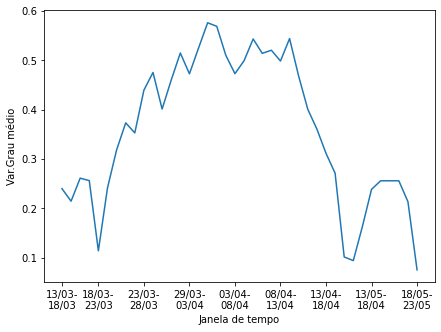

In [30]:
plt.figure(figsize=(7,5))
plt.xticks(x_ticks_1, x_ticks_2)

plt.plot(x,metricas['var_network_degree'])
#plt.title("grau médio 03/2020 a 05/2020")
plt.xlabel("Janela de tempo")
plt.ylabel("Var.Grau médio")
plt.show()

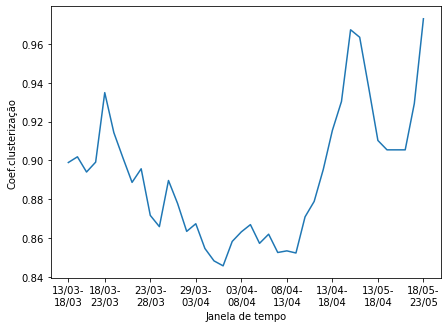

In [57]:
plt.figure(figsize=(7,5))
plt.xticks(x_ticks_1, x_ticks_2)

plt.plot(x,metricas['clustering_coefficient'])
#plt.title("Coeficiente de clusterização de 03/2020 a 05/2020")
plt.xlabel("Janela de tempo")
plt.ylabel("Coef.clusterização")
plt.show()

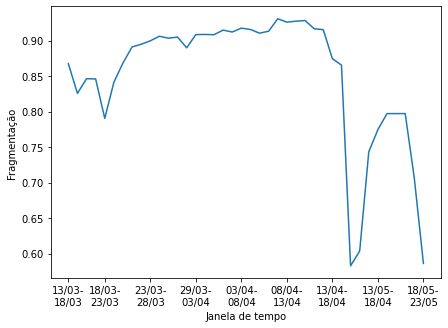

In [58]:
plt.figure(figsize=(7,5))
plt.xticks(x_ticks_1, x_ticks_2)

plt.plot(x,metricas['fragmentation'])
#plt.title("Fragmentação de 03/2020 a 05/2020")
plt.xlabel("Janela de tempo")
plt.ylabel("Fragmentação")
plt.show()

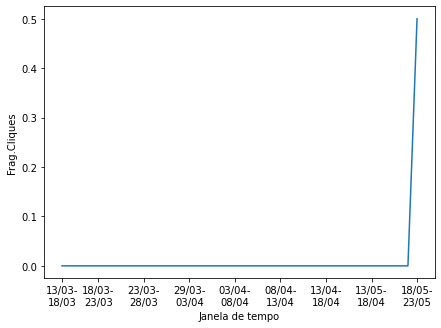

In [59]:
plt.figure(figsize=(7,5))
plt.xticks(x_ticks_1, x_ticks_2)

plt.plot(x,metricas['frag_cliques'])
#plt.title("Fragmentação de cliques de 03/2020 a 05/2020")
plt.xlabel("Janela de tempo")
plt.ylabel("Frag.Cliques")
plt.show()

In [29]:
print(metricas['frag_cliques'])

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5]


In [4]:
#Para analisar as janelas com deslize de 1 dia:
#1.Alterar funções de agrupar por janela pra ter deslize parametrizável(ok)
#Chamar processa_e_agrupa_tweets_json(2020) (ok)
#chamar agrupa_por_janela(ok)
#chamar agrupa_por_janela2(ok)
#chamar "networkMetrics.principal" com o numero de janelas gerado(ok)
#Opcional: fazer todos os grafos justapostos (precisa automatizar o nome das janelas, ou so usar T0, T1, T2...)
#fazer graficos com essas janelas

In [6]:
processa_e_agrupa_tweets_json(2020)

processando acmneto_

processando alexandre

processando govroraima

processando MinEconomia

processando SespaPara

processando firmino_filho

processando PrevOficial

processando celmarcosrocha

processando SaudePE

processando DamaresAlves

processando PauloGuedesMin

processando GovernoMS

processando rogeriomarinho

processando SemsaManaus

processando TeichNelson

processando GeraldoJulioPSB

processando drcarloseduard

processando CinthiaCRibeiro

processando Reinaldo45psdb

processando EduardoLeite_

processando jairbolsonaro

processando saudegoias

processando anvisa_oficial

processando FlavioDino

processando FR_BSB

processando saudegovpi

processando Luciano_Cartaxo

processando prefalvaro45

processando SF_Moro

processando AbrahamWeint

processando joaoazevedolins

processando fatimabezerra

processando neneupinheiro

processando ernestofaraujo

processando PMMacapa

processando RodrigoMaia

processando LuizFux

processando MCrivella

processando saudetocantins

process

In [6]:
inicio = "13-3"
fim = "28-5"
janela = 5
deslize = 1

agrupaPorJanela(inicio, fim, janela, deslize)

janela aumentou, agora vai ate 19-3

E o dia agora é14-3

janela aumentou, agora vai ate 20-3

E o dia agora é15-3

janela aumentou, agora vai ate 21-3

E o dia agora é16-3

janela aumentou, agora vai ate 22-3

E o dia agora é17-3

janela aumentou, agora vai ate 23-3

E o dia agora é18-3

janela aumentou, agora vai ate 24-3

E o dia agora é19-3

janela aumentou, agora vai ate 25-3

E o dia agora é20-3

janela aumentou, agora vai ate 26-3

E o dia agora é21-3

janela aumentou, agora vai ate 27-3

E o dia agora é22-3

janela aumentou, agora vai ate 28-3

E o dia agora é23-3

janela aumentou, agora vai ate 29-3

E o dia agora é24-3

janela aumentou, agora vai ate 30-3

E o dia agora é25-3

janela aumentou, agora vai ate 1-4

E o dia agora é27-3

janela aumentou, agora vai ate 2-4

E o dia agora é28-3

janela aumentou, agora vai ate 3-4

E o dia agora é29-3

janela aumentou, agora vai ate 4-4

E o dia agora é30-3

janela aumentou, agora vai ate 5-4

E o dia agora é31-3

janela aumentou, ag

In [7]:
agrupaPorJanela2(inicio, fim, janela, deslize)

janela aumentou, agora vai ate 19-3

E o dia agora é14-3

janela aumentou, agora vai ate 20-3

E o dia agora é15-3

janela aumentou, agora vai ate 21-3

E o dia agora é16-3

janela aumentou, agora vai ate 22-3

E o dia agora é17-3

janela aumentou, agora vai ate 23-3

E o dia agora é18-3

janela aumentou, agora vai ate 24-3

E o dia agora é19-3

janela aumentou, agora vai ate 25-3

E o dia agora é20-3

janela aumentou, agora vai ate 26-3

E o dia agora é21-3

janela aumentou, agora vai ate 27-3

E o dia agora é22-3

janela aumentou, agora vai ate 28-3

E o dia agora é23-3

janela aumentou, agora vai ate 29-3

E o dia agora é24-3

janela aumentou, agora vai ate 30-3

E o dia agora é25-3

janela aumentou, agora vai ate 1-4

E o dia agora é27-3

janela aumentou, agora vai ate 2-4

E o dia agora é28-3

janela aumentou, agora vai ate 3-4

E o dia agora é29-3

janela aumentou, agora vai ate 4-4

E o dia agora é30-3

janela aumentou, agora vai ate 5-4

E o dia agora é31-3

janela aumentou, ag

In [9]:
networkMetrics.principal(71,"deslize_1_resultados_marco_maio_2020")

graph


In [28]:
2+2

4

In [9]:
#Conta alternativa pra fragmentação
edges = [("Flamengo", "Vasco"),("Flamengo", "hoje"), ("Vasco", "hoje"), ("Fla2", "campeão")]

G = nx.Graph()
G.add_edges_from(edges)

aux = 0
components = nx.connected_components(G)
S = [G.subgraph(c).copy() for c in nx.connected_components(G)]
for i in S:
    qtdeNodes = len(i.nodes)
    aux+=qtdeNodes*(qtdeNodes - 1)

F = 1 - aux/(len(G.nodes())*(len(G.nodes()) - 1))
print(F)
print(aux)
#print(G)

0.6
8


In [16]:
metricas

{'var_densidade': [0.8408545375845577,
  0.8214232028696316,
  0.9122782639068743,
  0.901322705265037,
  0.5693977853743661,
  0.5618748082410112,
  0.781914940155386,
  0.9493082711702165,
  0.8870589455075089,
  1.1735235035804013,
  1.2984824299336477,
  1.0586256294277314,
  1.2765672736527351,
  1.4680853309885564,
  1.2856827022030282,
  1.5598956816079022,
  1.7509127284395558,
  1.7471813513033854,
  1.5146250726910138,
  1.3683297843959141,
  1.3824067322519338,
  1.5347288105224188,
  1.4355002203954705,
  1.4631782667514504,
  1.3956148350574704,
  1.571679950990296,
  1.2950134676464229,
  1.074318700649998,
  0.9181772398667858,
  0.7622927575014631,
  0.6453085676865655,
  0.17161780481651423,
  0.16339666927313834,
  0.3531076698331539,
  0.5531074843734933,
  0.6006757892315995,
  0.6006757892315995,
  0.6006757892315995,
  0.48284313725490224,
  0.11824175824175831],
 'network_degree': [21.685279187817212,
  22.050955414012737,
  23.016574585635396,
  22.9000000000000

In [17]:
j

41

Text(0, 0.5, 'Valor das métricas')

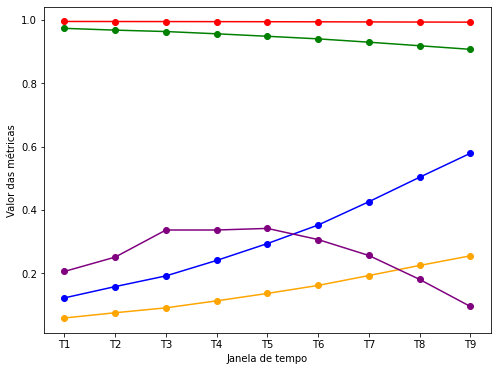

In [28]:
#Desconexa pra conexa PLOT
#PLOTS JUNTOS
#Desconexa pra conexa
x = ["T"+str(i) for i in range(1,10)]
Y = [var_dens_desc_p_conex, var_grau_medio_desc_p_conex, coef_cluster_desc_p_conex, frag_desc_p_conex, frag_cliques_desc_p_conex]

plt.figure(figsize=(8,6))
plt.plot(x,Y[0], color = 'blue', label = 'V('+u"\u0394"+')') #var dens 
plt.scatter(x,Y[0], color = 'blue', label = 'V('+u"\u0394"+')') #var dens 
plt.plot(x,Y[1], color = 'orange', label = 'V('+u"\u27e8"+'k'+u"\u27e9"+')') #var grau medio
plt.scatter(x,Y[1], color = 'orange', label = 'V('+u"\u27e8"+'k'+u"\u27e9"+')') #var grau medio
plt.plot(x,Y[2], color = 'green', label = 'C') #coef cluster
plt.scatter(x,Y[2], color = 'green', label = 'C') #coef cluster
plt.plot(x,Y[3], color = 'red', label = 'F') #Fragmentacao
plt.scatter(x,Y[3], color = 'red', label = 'F') #Fragmentacao
plt.plot(x,Y[4], color = 'purple', label = 'Fcliques') #fragcliques
plt.scatter(x,Y[4], color = 'purple', label = 'Fcliques') #fragcliques

plt.xlabel("Janela de tempo", fontsize = 10)
plt.ylabel("Valor das métricas", fontsize = 10)
#plt.legend(prop={'size': 13})

Text(0, 0.5, 'Valor das métricas')

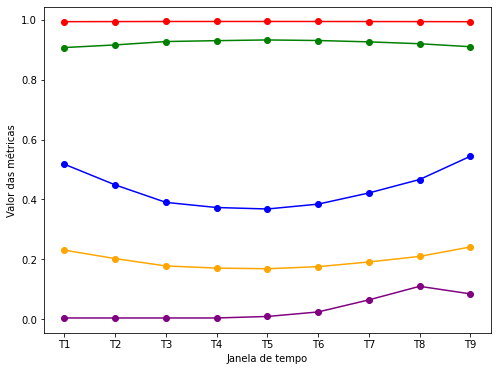

In [33]:
#Conexa pra conexa PLOT

x = ["T"+str(i) for i in range(1,10)]
Y = [var_dens_conex_p_conex, var_grau_medio_conex_p_conex, coef_cluster_conex_p_conex, frag_conex_p_conex, frag_cliques_conex_p_conex]

plt.figure(figsize=(8,6))
plt.plot(x,Y[0], color = 'blue', label = 'V('+u"\u0394"+')') #var dens
plt.scatter(x,Y[0], color = 'blue', label = 'V('+u"\u0394"+')') #var dens
plt.plot(x,Y[1], color = 'orange', label = 'V('+u"\u27e8"+'k'+u"\u27e9"+')') #var grau medio
plt.scatter(x,Y[1], color = 'orange', label = 'V('+u"\u27e8"+'k'+u"\u27e9"+')') #var grau medio
plt.plot(x,Y[2], color = 'green', label = 'C') #coef cluster
plt.scatter(x,Y[2], color = 'green', label = 'C') #coef cluster
plt.plot(x,Y[3], color = 'red', label = 'F') #Fragmentacao
plt.scatter(x,Y[3], color = 'red', label = 'F') #Fragmentacao
plt.plot(x,Y[4], color = 'purple', label = 'Fcliques') #fragcliques
plt.scatter(x,Y[4], color = 'purple', label = 'Fcliques') #fragcliques

plt.xlabel("Janela de tempo", fontsize = 10)
plt.ylabel("Valor das métricas", fontsize = 10)
#plt.legend(prop={'size': 10})


<Figure size 576x432 with 0 Axes>

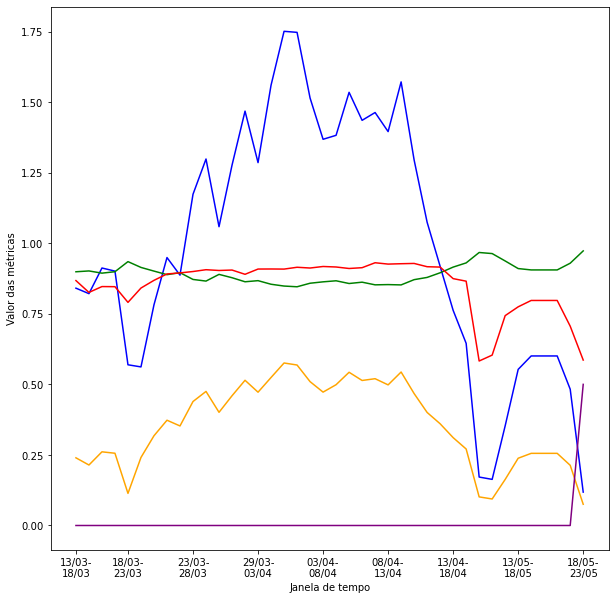

In [10]:
#Plot COVID
path = "graph/deslize_1_resultados_marco_maio_2020.csv"
metricas,j = plot_metricas_csv2(path)
x = [i for i in range(1,j)]
plt.figure(figsize=(8,6))
x_ticks_1 = [1,5,10,15,20,25,30,35,40]
x_ticks_2 = ['13/03-\n18/03','18/03-\n23/03','23/03-\n28/03','29/03-\n03/04','03/04-\n08/04','08/04-\n13/04','13/04-\n18/04','13/05-\n18/05','18/05-\n23/05']

plt.figure(figsize=(10,10))
plt.xticks(x_ticks_1, x_ticks_2)
#plt.scatter(x,metricas['var_densidade'], color = 'blue')
plt.plot(x,metricas['var_densidade'], color = 'blue', label= 'V('+u"\u0394"+')')
#plt.scatter(x,metricas['var_network_degree'], color = 'orange')
plt.plot(x,metricas['var_network_degree'], color = 'orange', label = 'V('+u"\u27e8"+'k'+u"\u27e9"+')')
#plt.scatter(x,metricas['clustering_coefficient'], color = 'green')
plt.plot(x,metricas['clustering_coefficient'], color = 'green', label = 'C')
#plt.scatter(x,metricas['fragmentation'], color = 'red')
plt.plot(x,metricas['fragmentation'], color = 'red', label = 'F')
#plt.scatter(x,metricas['frag_cliques'], color = 'purple')
plt.plot(x,metricas['frag_cliques'], color = 'purple', label = 'Fcliques')
#plt.title("variação de densidade 03/2020 a 05/2020")
plt.xlabel("Janela de tempo")
plt.ylabel("Valor das métricas")
#plt.legend(prop={'size': 15}, ncol = 5)
plt.show()


In [3]:
#pegando métricas da base pouco conexa isoladamente

path = 'graph/pouco_conexa.csv'
metricas, j = plot_metricas_csv2(path)
metricas

{'var_densidade': [0.1265977655889281],
 'var_network_degree': [0.06338185890258008],
 'clustering_coefficient': [0.9715208157380468],
 'fragmentation': [0.9570854225956543],
 'frag_cliques': [0.125]}

In [5]:
path = 'graph/conexa.csv'
metricas, j = plot_metricas_csv2(path)
metricas

{'var_densidade': [0.6238113575415698],
 'var_network_degree': [0.2691110810445212],
 'clustering_coefficient': [0.8974118077651112],
 'fragmentation': [0.9373805286401687],
 'frag_cliques': [0.0]}

In [6]:
path = 'graph/muito_conexa.csv'
metricas, j = plot_metricas_csv2(path)
metricas

{'var_densidade': [7.917313124873672],
 'var_network_degree': [1.0856722821900213],
 'clustering_coefficient': [0.8076342694872709],
 'fragmentation': [0.2932884494003787],
 'frag_cliques': [0.0]}

## TWEETS POR JANELA / DIA

In [9]:
n_janelas = 71
count = 1
tweets_por_janela = []
while (count<= n_janelas):
    path = 'Janelas/T'+str(count)+'.txt'
    arq = open(path,'r')
    i=0
    for line in arq:
        i+=1
        
    tweets_por_janela.append(i)
    count+=1
    arq.close()

tweets_por_janela

[15,
 17,
 17,
 11,
 10,
 14,
 19,
 19,
 23,
 26,
 23,
 26,
 27,
 30,
 36,
 39,
 42,
 38,
 35,
 34,
 33,
 32,
 40,
 36,
 42,
 37,
 29,
 26,
 17,
 15,
 3,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 3,
 6,
 8,
 9,
 9,
 9,
 6,
 3,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

(array([17., 15.,  0.,  3.,  0.,  0.,  2.,  0.,  1.,  3.,  1.,  1.,  0.,
         0.,  1.,  2.,  0.,  3.,  0.,  2.,  0.,  0.,  0.,  2.,  0.,  0.,
         3.,  1.,  0.,  1.,  1.,  0.,  1.,  1.,  1.,  1.,  2.,  1.,  1.,
         1.,  1.,  2.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
        39., 40., 41., 42.]),
 <BarContainer object of 42 artists>)

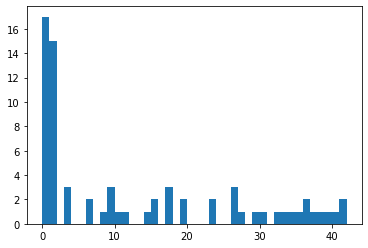

In [11]:
plt.hist(tweets_por_janela,42)

In [ ]:
#Tuítes por dia
#base pequena
#VOU DESCARTAR ESSE PQ NA CELULA ABAIXO JÁ ESTÁ PRONTO

data_init = '13-3'
data_fim = '17-5'
data=data_init

data_fim_list = data_fim.split('-')
dia_fim = data_fim_list[0]
mes_fim = data_fim_list[1]

n_janelas = 71
count = 1
tweets_por_dia = []
dias_com_tweet = []
while (True):
    path = 'BaseCovidBackup/'+data+'.txt'
    
    try:
        arq = open(path,'r')
        i=0
        for line in arq:
            i+=1
        
        tweets_por_dia.append(i)
        arq.close()
        dias_com_tweet.append(data)
        
    except: #o arquivo não existe pq não tinha tuíte
        
        tweets_por_dia.append(0)
        
    data_list = data.split('-')
    dia = data_list[0]
    mes = data_list[1]
    seguinte = diaSeguinte(dia, mes)
    dia_novo = seguinte[0]
    mes_novo = seguinte[1]
    data = dia_novo+"-"+mes_novo
    
    if(compara_data(seguinte, (dia_fim, mes_fim)): #se já passamos da data final
       break

tweets_por_dia

In [12]:
processa_e_agrupa_tweets_json(2020)

processando GeanLoureiro

processando gladsoncameli

processando ruipalmeira

processando FR_BSB

processando brunocovas

processando saudegovpi

processando TerezaCrisMS

processando RosaWeberSTF

processando SemsaManaus

processando Sesau_Roraima

processando fatimabezerra

processando Teresa_Surita

processando SaudeMG

processando joaoazevedolins

processando zenaldocoutinho

processando PauloGuedesMin

processando saudegovba

processando alexandre

processando mribeiroMEC

processando sesacre

processando PMMacapa

processando DefesaGovBr

processando anvisa_oficial

processando GovernoES

processando rogeriomarinho

processando SespaPara

processando jdoriajr

processando maurocarlesse

processando saudepublicasc

processando TeichNelson

processando SF_Moro

processando AmendoncaMJSP

processando rsallesmma

processando belivaldochagas

processando jairbolsonaro

processando AdvocaciaGeral

processando RenanFilho_

processando wilsonwitzel

processando SaudePE

processando saude

In [4]:
inicio = '13-3'
fim = '18-5'
dia = '13-3'
tweets_por_dia = []
dias_com_tweets = []

while True:
    count = 0   
    path = 'BaseCovidBackup/'+dia+'.txt'
    try:
        arq = open(path,'r')
        for line in arq:
            count+=1
        tweets_por_dia.append(count)
        arq.close()
        dias_com_tweets.append(dia)
        
    except: #arquivo nao existe entao nao tem tweets no dia
        tweets_por_dia.append(0)
        
    data = dia.split('-')
    day = int(data[0])
    month = int(data[1])
    
    novo_dia = diaSeguinte(day,month)
    day = str(novo_dia[0])
    month = str(novo_dia[1])
    dia = day+'-'+month
    
    if (dia == '18-5'):
        break
        
tweets_por_dia


[5,
 0,
 1,
 6,
 6,
 1,
 1,
 2,
 1,
 0,
 5,
 5,
 6,
 2,
 5,
 3,
 2,
 8,
 9,
 8,
 9,
 5,
 1,
 6,
 6,
 7,
 8,
 4,
 9,
 2,
 12,
 2,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 3,
 3,
 2,
 1,
 0,
 0,
 0,
 0,
 0,
 0]

In [20]:
len(tweets_por_dia)

71

(array([34.,  9.,  6.,  3.,  1.,  5.,  5.,  1.,  3.,  3.,  0.,  1.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.]),
 <BarContainer object of 12 artists>)

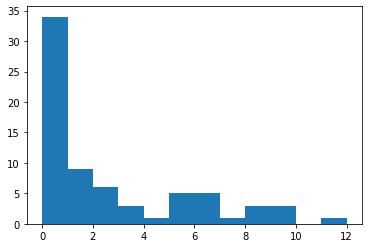

In [24]:
plt.hist(tweets_por_dia,12)

<BarContainer object of 71 artists>

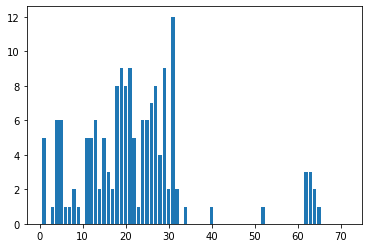

In [27]:
plt.bar([i for i in range(1,72)],tweets_por_dia)

In [19]:
inicio = '13-3'
fim = '18-5'
dia = '13-3'
tweets_por_dia = []
dias_com_tweets = []

while True:
    count = 0   
    path = 'BaseCovidBackup/'+dia+'.txt'
    try:
        arq = open(path,'r')
        for line in arq:
            count+=1
        tweets_por_dia.append(count)
        arq.close()
        dias_com_tweets.append(dia)
        
    except: #arquivo nao existe entao nao tem tweets no dia
        tweets_por_dia.append(0)
        
    data = dia.split('-')
    day = int(data[0])
    month = int(data[1])
    
    novo_dia = diaSeguinte(day,month)
    day = str(novo_dia[0])
    month = str(novo_dia[1])
    dia = day+'-'+month
    
    if (dia == '18-5'):
        break
        
tweets_por_dia


[5,
 0,
 1,
 6,
 6,
 1,
 1,
 2,
 1,
 0,
 5,
 5,
 6,
 2,
 5,
 3,
 2,
 8,
 9,
 8,
 9,
 5,
 1,
 6,
 6,
 7,
 8,
 4,
 9,
 2,
 12,
 2,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 3,
 3,
 2,
 1]

In [5]:
sum(tweets_por_dia)

159

In [13]:
(159-15)/32

4.5

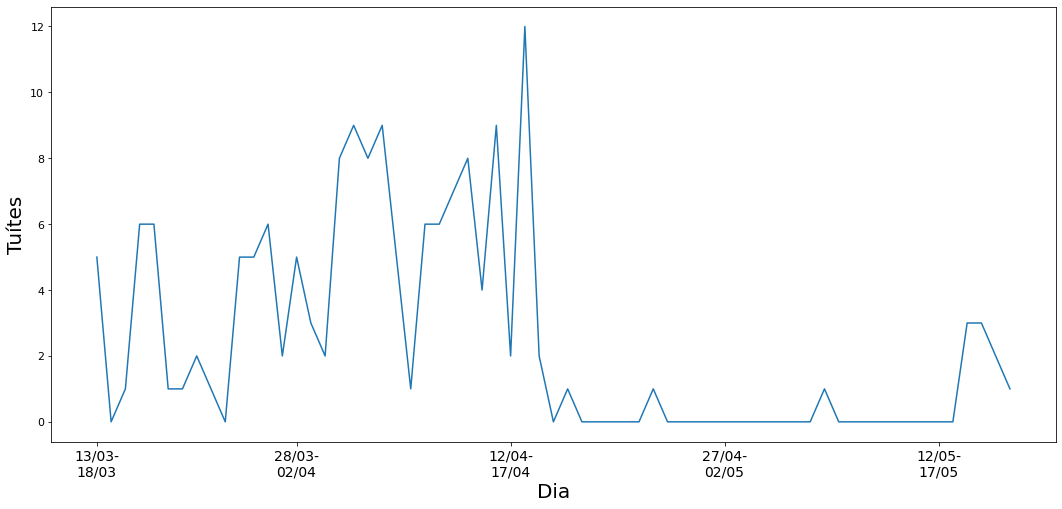

In [20]:
#tuítes por dia  - base pequena
plt.figure(figsize=(18,8))
x_ticks_1 = [0,14,29,44,59,69]
x_ticks_2 = ['13/03-\n18/03','28/03-\n02/04','12/04-\n17/04','27/04-\n02/05','12/05-\n17/05','22/05-\n28/05']
plt.xticks(x_ticks_1, x_ticks_2, fontsize = 14)
plt.yticks(fontsize = 11)
plt.xlabel("Dia", fontsize=20)
plt.ylabel("Tuítes", fontsize=20)


plt.plot([i for i in range(len(tweets_por_dia))],tweets_por_dia)

In [4]:
#Plotando tuítes por janela - todas as janelas

n_janelas = 71
count = 1
tweets_por_janela = []
while (count<= n_janelas):
    path = 'BaseCovidBackup/T'+str(count)+'.txt'
    arq = open(path,'r')
    i=0
    for line in arq:
        i+=1
        
    tweets_por_janela.append(i)
    count+=1
    arq.close()

tweets_por_janela

[15,
 17,
 17,
 11,
 10,
 14,
 19,
 19,
 23,
 26,
 23,
 26,
 27,
 30,
 36,
 39,
 42,
 38,
 35,
 34,
 33,
 32,
 40,
 36,
 42,
 37,
 29,
 26,
 17,
 15,
 3,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 3,
 6,
 8,
 9,
 9,
 9,
 6,
 3,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

<BarContainer object of 71 artists>

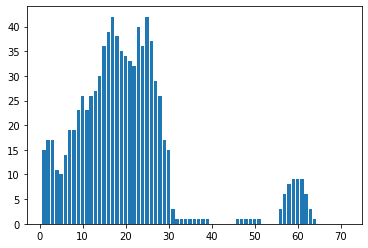

In [5]:
plt.bar([i for i in range(1,72)],tweets_por_janela)

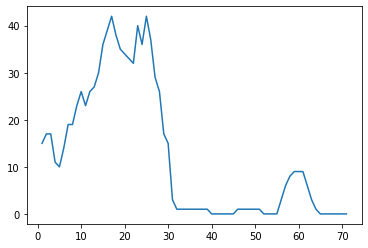

In [6]:
plt.plot([i for i in range(1,72)],tweets_por_janela)

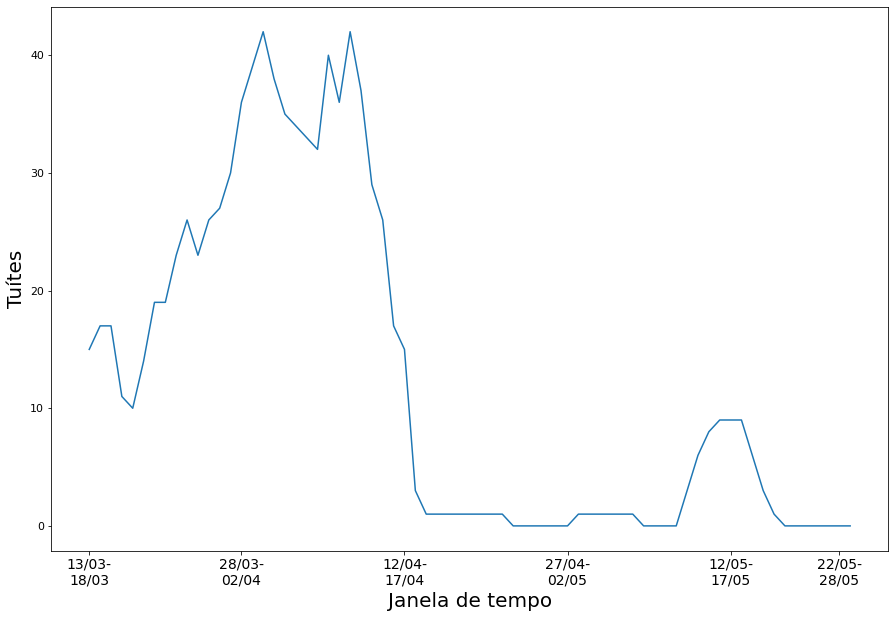

In [11]:
plt.figure(figsize=(15,10))
x_ticks_1 = [0,14,29,44,59,69]
x_ticks_2 = ['13/03-\n18/03','28/03-\n02/04','12/04-\n17/04','27/04-\n02/05','12/05-\n17/05','22/05-\n28/05']
plt.xticks(x_ticks_1, x_ticks_2, fontsize = 14)
plt.yticks(fontsize = 11)
plt.xlabel("Janela de tempo", fontsize=20)
plt.ylabel("Tuítes", fontsize=20)
plt.plot([i for i in range(71)],tweets_por_janela) 

In [12]:
#Plotando tuítes por janela - Base grande

n_janelas = 143
count = 0
tweets_por_janela = []
while (count<= n_janelas):
    path = 'Janelas_Full_Com_Stopwords/T'+str(count)+'.txt'
    arq = open(path,'r')
    i=0
    for line in arq:
        i+=1
        
    tweets_por_janela.append(i)
    count+=1
    arq.close()

tweets_por_janela

[74,
 86,
 96,
 113,
 109,
 112,
 109,
 112,
 105,
 95,
 116,
 129,
 144,
 161,
 239,
 532,
 1936,
 3540,
 4447,
 4518,
 4543,
 4336,
 3124,
 4194,
 3518,
 3486,
 3874,
 4083,
 3793,
 8588,
 7810,
 9369,
 9035,
 8781,
 6492,
 4342,
 2554,
 1998,
 2752,
 3269,
 3845,
 4133,
 4119,
 3074,
 2273,
 1719,
 1162,
 1839,
 3367,
 4653,
 5910,
 6693,
 7447,
 6759,
 5717,
 7249,
 6369,
 5999,
 5871,
 6127,
 6328,
 5254,
 9631,
 13302,
 20824,
 22310,
 21993,
 20609,
 18672,
 17569,
 18980,
 23707,
 24868,
 34800,
 35124,
 38422,
 34875,
 29936,
 35243,
 28888,
 26503,
 22556,
 20433,
 16969,
 20152,
 26095,
 34063,
 52989,
 50241,
 57010,
 61624,
 57705,
 47589,
 36813,
 28629,
 20988,
 19980,
 32815,
 49478,
 57558,
 58175,
 61534,
 62553,
 53888,
 45930,
 39325,
 39989,
 32716,
 21921,
 27294,
 33763,
 41992,
 42323,
 45984,
 49169,
 42992,
 37451,
 43530,
 54379,
 67792,
 68953,
 77131,
 75267,
 80242,
 78552,
 69113,
 79490,
 78324,
 77448,
 63025,
 65317,
 64631,
 54686,
 56843,
 64600,
 68

In [13]:
len(tweets_por_janela)

144

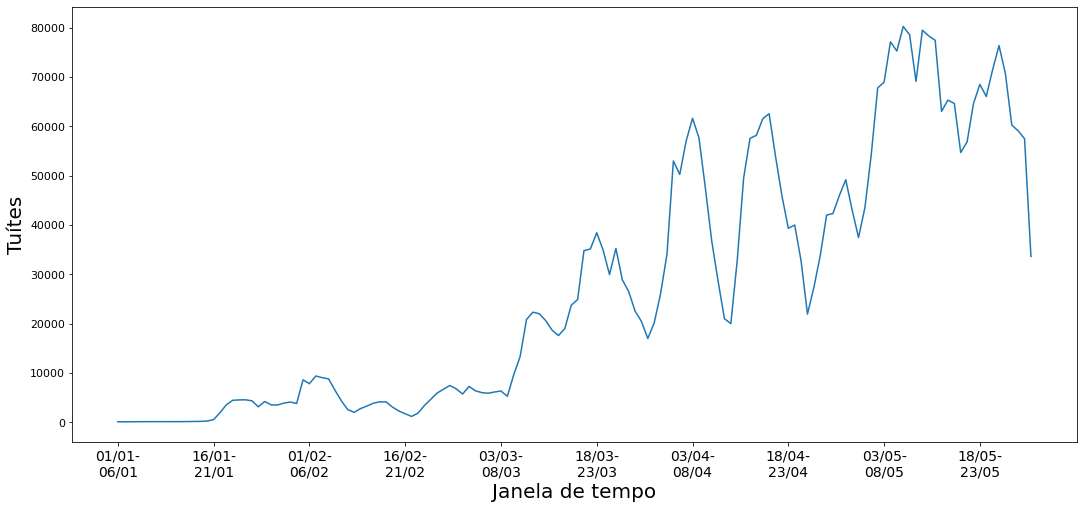

In [15]:
#Plotando tweets por janela da base grande
plt.figure(figsize=(18,8))
x_ticks_1 = [0,15,30,45,60,75,90,105,120,135]
x_ticks_2 = ['01/01-\n06/01','16/01-\n21/01','01/02-\n06/02','16/02-\n21/02','03/03-\n08/03','18/03-\n23/03','03/04-\n08/04','18/04-\n23/04','03/05-\n08/05', '18/05-\n23/05']
plt.xticks(x_ticks_1, x_ticks_2, fontsize = 14)
plt.yticks(fontsize = 11)
plt.xlabel("Janela de tempo", fontsize=20)
plt.ylabel("Tuítes", fontsize=20)
plt.plot([i for i in range(144)],tweets_por_janela) 

In [17]:
#tweets por dia -  base grande

inicio = '1-1'
fim = '30-5'
dia = '1-1'
tweets_por_dia = []
dias_com_tweets = []

while True:
    count = 0   
    path = 'Tweets_BaseGrande_Com_Lema/'+dia+'.txt'
    try:
        arq = open(path,'r')
        for line in arq:
            count+=1
        tweets_por_dia.append(count)
        arq.close()
        dias_com_tweets.append(dia)
        
    except: #arquivo nao existe entao nao tem tweets no dia
        tweets_por_dia.append(0)
        
    data = dia.split('-')
    day = int(data[0])
    month = int(data[1])
    
    novo_dia = diaSeguinte(day,month)
    day = str(novo_dia[0])
    month = str(novo_dia[1])
    dia = day+'-'+month
    
    if (dia == '18-5'):
        break
        
tweets_por_dia


[2,
 14,
 12,
 17,
 15,
 14,
 14,
 24,
 29,
 13,
 18,
 11,
 17,
 17,
 19,
 34,
 31,
 26,
 34,
 95,
 312,
 1438,
 1634,
 933,
 105,
 120,
 105,
 226,
 2705,
 257,
 193,
 493,
 434,
 2415,
 2345,
 1929,
 1752,
 159,
 181,
 126,
 195,
 141,
 1196,
 913,
 698,
 702,
 483,
 127,
 151,
 112,
 144,
 145,
 1160,
 1655,
 1437,
 1369,
 927,
 899,
 472,
 613,
 2969,
 489,
 557,
 771,
 728,
 814,
 1895,
 4866,
 4228,
 8293,
 2214,
 497,
 511,
 2929,
 3125,
 9702,
 6941,
 1658,
 10443,
 3253,
 6423,
 6157,
 2002,
 6965,
 4088,
 868,
 2476,
 4034,
 5503,
 7270,
 6811,
 10444,
 11385,
 8827,
 12272,
 11884,
 2892,
 328,
 609,
 643,
 4631,
 10876,
 15727,
 16991,
 8689,
 1260,
 7990,
 11896,
 7059,
 9033,
 2084,
 1924,
 717,
 1101,
 12434,
 15502,
 10313,
 2255,
 4378,
 4284,
 6256,
 9959,
 16391,
 13103,
 17791,
 5447,
 14435,
 8096,
 21367,
 11414,
 8352,
 15823,
 13270,
 7221,
 6943]

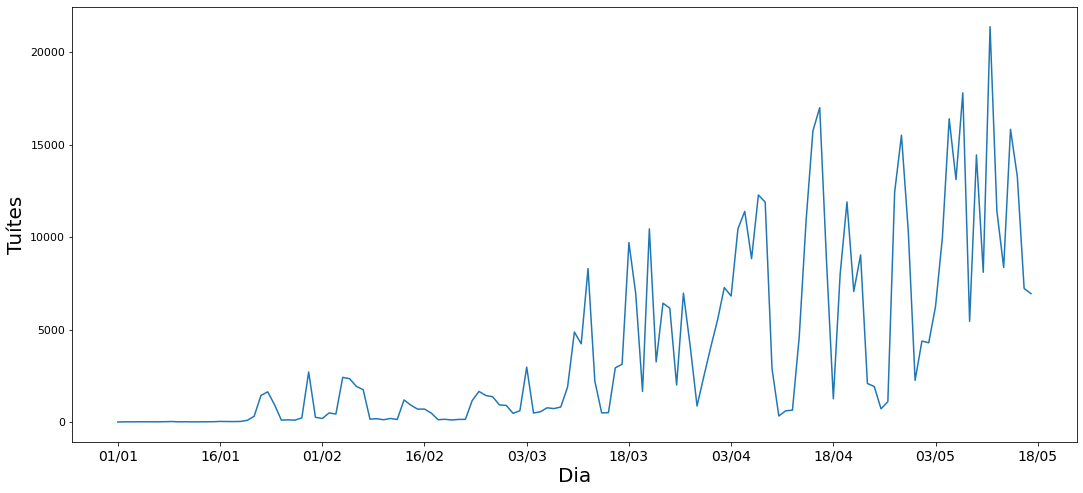

In [18]:
plt.figure(figsize=(18,8))
x_ticks_1 = [0,15,30,45,60,75,90,105,120,135]
x_ticks_2 = ['01/01','16/01','01/02','16/02','03/03','18/03','03/04','18/04','03/05', '18/05']
plt.xticks(x_ticks_1, x_ticks_2, fontsize = 14)
plt.yticks(fontsize = 11)
plt.xlabel("Dia", fontsize=20)
plt.ylabel("Tuítes", fontsize=20)


plt.plot([i for i in range(len(tweets_por_dia))],tweets_por_dia)

## LENDO TWEETS DA BASE GRANDE JSON
### Para processar com o BERT no Colab

In [10]:

#Lendo tweets base json 
#Cada tweet é uma linha do arquivo
#OBS: deu erro um pouco depois do 700.000 (antes do 710.000)
arq = open("basecovid_1.json","r")
i = 0
limite = 1000000
for linha in arq:
    if i>=limite:
        break
    dic = json.loads(linha) #dicionario com todas as infos do tweet
    data = dic['created_at']
    tweet = dic['text']  #texto do tweet
    
    tweet = processaTweet(tweet)
    tweet2 = tweet.replace("\n", "")
    
    if(len(tweet2)>=1):
        lemas = lematiza(tweet2)  #texto do tweet já processado e lematizado
        if (i%10000 == 0):
            print("sample tweet No"+str(i)+": ", lemas)
        agrupaPorData(lemas,data)    #coloca cada tweet ja lematizado numa
                                     #linha de um arquivo cujo título é sua data 
    
    i+=1
    
    
arq.close()



sample tweet No0:  declarar ir parar cloroquina
sample tweet No10000:  gostar saber voces estam defeso so ouco atual governador
sample tweet No20000:  29 municipios estar autonomia decretar dever
sample tweet No30000:  coronavirus ir mudar vidar voce achar namigo taxista raphael taxi itanhae
sample tweet No40000:  olavista cotar ministrar saude covid 19 nao matar porra viruzinho
sample tweet No50000:  falir nao niver nesse sexto sexto quarentenar
sample tweet No60000:  onu financiar prevencao covid19
sample tweet No70000:  kkkkkkkkk ta ler sr individuar dividir presidencia sr general capit
sample tweet No80000:  2020 ngm querer covid19
sample tweet No90000:  nesse thelma eleito campea corona virus extinguir terra
sample tweet No100000:  inves ler materias voce assistir 30 minuto interpretar melhor falir con
sample tweet No110000:  querer garoto gostar mais corona virus nao deixar
sample tweet No120000:  melhor enfrentar coronavirus lagartixa
sample tweet No130000:  so contar pandemia m

TypeError: string indices must be integers

In [4]:
# Calculando as métricas das janelas processadas com BERT
#Depois dessa primeira rodada, vai ter q botar append = True!

#Dessa vez, o cálculo da fragmentação está correto!
inicial = 21
final = 143
destino = "MetricasBaseGrandeBERT_F_true"
append = True
networkMetrics.principal3(inicial, final, destino, append)

Janela  21
escrevendo métricas no arquivo
Janela  22
escrevendo métricas no arquivo
Janela  23
escrevendo métricas no arquivo
Janela  24
escrevendo métricas no arquivo
Janela  25
escrevendo métricas no arquivo
Janela  26
escrevendo métricas no arquivo
Janela  27
escrevendo métricas no arquivo
Janela  28
escrevendo métricas no arquivo
Janela  29
escrevendo métricas no arquivo
Janela  30
escrevendo métricas no arquivo
Janela  31
escrevendo métricas no arquivo
Janela  32
escrevendo métricas no arquivo
Janela  33
escrevendo métricas no arquivo
Janela  34
escrevendo métricas no arquivo
Janela  35
escrevendo métricas no arquivo
Janela  36
escrevendo métricas no arquivo
Janela  37
escrevendo métricas no arquivo
Janela  38
escrevendo métricas no arquivo
Janela  39
escrevendo métricas no arquivo
Janela  40
escrevendo métricas no arquivo
Janela  41
escrevendo métricas no arquivo
Janela  42
escrevendo métricas no arquivo
Janela  43
escrevendo métricas no arquivo
Janela  44
escrevendo métricas no 

In [4]:

#Lendo tweets base json 
#Cada tweet é uma linha do arquivo
#OBS: deu erro um pouco depois do 700.000 (antes do 710.000)

#origem = "baseCovid1.json"
def extrai_tweets_json(origem, lematizar = True, rem_stopwords = True):
    
    
    arq = open(origem,"r")
    i = 0
    limite = 710000
    for linha in arq:
        if i>=limite:
            break
        dic = json.loads(linha) #dicionario com todas as infos do tweet
        data = dic['created_at']
        tweet = dic['text']  #texto do tweet
    
        tweet = processaTweet(tweet, remove_stopwords = rem_stopwords)
        tweet2 = tweet.replace("\n", "")
    
        if(len(tweet2)>=1):
            
            lemas = tweet2 #na vdd sem lematizar ainda
            if(lematizar):
                lemas = lematiza(tweet2)  #texto do tweet já processado e lematizado
                
            if (i%10000 == 0):
                print("sample tweet No"+str(i)+": ", lemas)
            agrupaPorData(lemas,data)    #coloca cada tweet ja lematizado numa
                                     #linha de um arquivo cujo título é sua data 
    
        i+=1
    
    
    arq.close()


    


In [8]:
origem = "baseCovid_1.json"

#vai salvar na pasta Tweets, separando por dia
extrai_tweets_json(origem, lematizar = False, rem_stopwords = False)

sample tweet No0:  ele declarou que ia parar com cloroquina depois
sample tweet No10000:  gostaria de saber que voces estam fazendo para nossa defesa pois so ouco atual governador nos
sample tweet No20000:  29 os municipios estados tem essa autonomia alguns devem decretar devido ao
sample tweet No30000:  como coronavirus vai mudar nossas vidas no que voce acha namigo taxista raphael do taxi em itanhae
sample tweet No40000:  olavista cotado para ministro da saude diz que covid 19 nao mata que uma porra de um viruzinho
sample tweet No50000:  fala nao meu niver nesse sexta sexta de quarentena
sample tweet No60000:  onu financia prevencao do covid19
sample tweet No70000:  kkkkkkkkk ta lendo isso sr individuo que divide presidencia com sr general capit
sample tweet No80000:  2020 ngm te quer covid19
sample tweet No90000:  foi nesse dia quando thelma foi eleita campea que corona virus foi extinto da terra
sample tweet No100000:  ao inves de ler materias voce deveria assistir os 30 minutos pr

TypeError: string indices must be integers

# Plotando métricas da base grande com BERT

In [6]:
path = "graph/MetricasBaseGrandeBERT_F_true.csv"
metricas,j = plot_metricas_csv2(path)

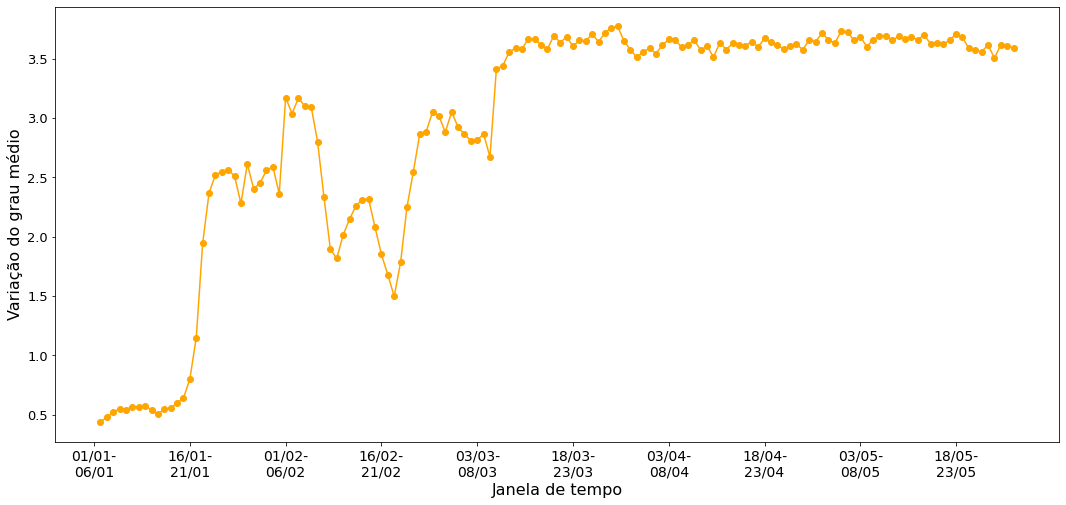

In [8]:

x = [i for i in range(1,j)]  #j é o número total de linhas do csv, incluindo o cabeçalho, por isso o range funciona


plt.figure(figsize=(18,8))
x_ticks_1 = [0,15,30,45,60,75,90,105,120,135]
x_ticks_2 = ['01/01-\n06/01','16/01-\n21/01','01/02-\n06/02','16/02-\n21/02','03/03-\n08/03','18/03-\n23/03','03/04-\n08/04','18/04-\n23/04','03/05-\n08/05', '18/05-\n23/05']
plt.xticks(x_ticks_1, x_ticks_2, fontsize = 14)
plt.yticks(fontsize = 13)

plt.scatter(x,metricas['var_network_degree'], color = 'orange')
plt.plot(x,metricas['var_network_degree'], color = 'orange')


plt.xlabel("Janela de tempo", size = 16)
plt.ylabel("Variação do grau médio", size = 16)
plt.show()


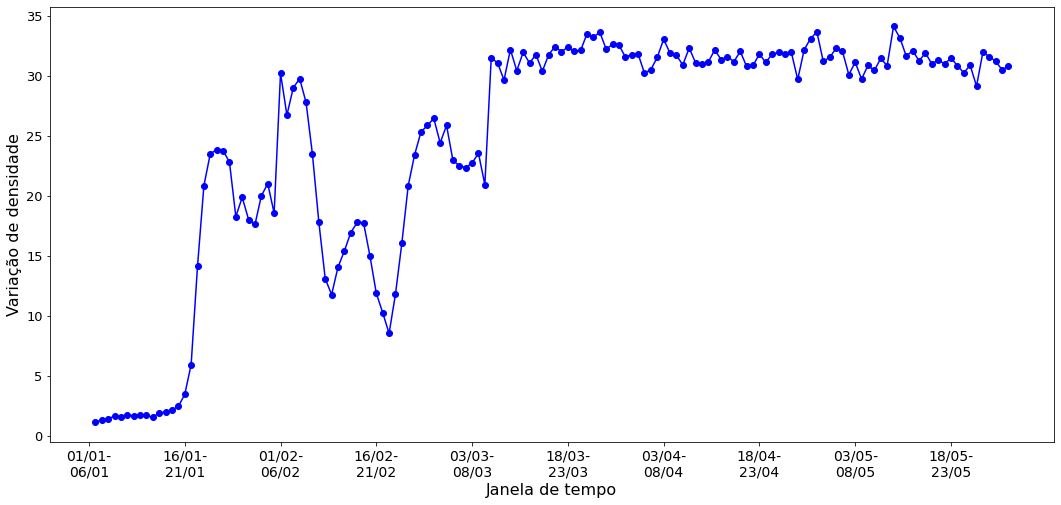

In [19]:
#densidade: blue; degree: orange; C: green; F: red; FragCliques: purple
plt.figure(figsize=(18,8))
x_ticks_1 = [0,15,30,45,60,75,90,105,120,135]
x_ticks_2 = ['01/01-\n06/01','16/01-\n21/01','01/02-\n06/02','16/02-\n21/02','03/03-\n08/03','18/03-\n23/03','03/04-\n08/04','18/04-\n23/04','03/05-\n08/05', '18/05-\n23/05']
plt.xticks(x_ticks_1, x_ticks_2, fontsize = 14)
plt.yticks(fontsize = 13)

plt.scatter(x,metricas['var_densidade'], color = 'blue')
plt.plot(x,metricas['var_densidade'], color = 'blue')


plt.xlabel("Janela de tempo", size = 16)
plt.ylabel("Variação de densidade", size = 16)
plt.show()



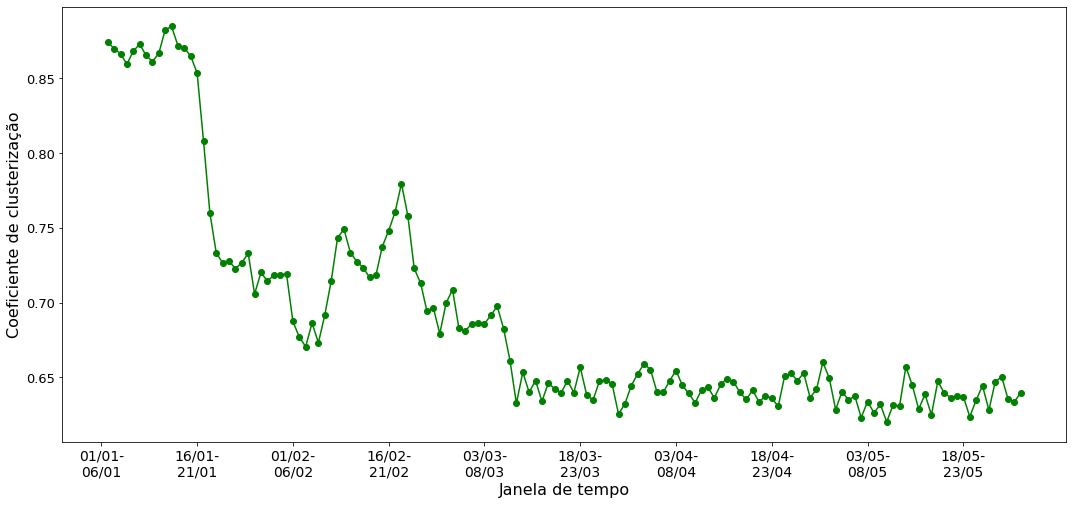

In [20]:
#clustering_coefficient: green, fragmentation = red, frag_cliques = purple

plt.figure(figsize=(18,8))
x_ticks_1 = [0,15,30,45,60,75,90,105,120,135]
x_ticks_2 = ['01/01-\n06/01','16/01-\n21/01','01/02-\n06/02','16/02-\n21/02','03/03-\n08/03','18/03-\n23/03','03/04-\n08/04','18/04-\n23/04','03/05-\n08/05', '18/05-\n23/05']
plt.xticks(x_ticks_1, x_ticks_2, fontsize = 14)
plt.yticks(fontsize = 13)

plt.scatter(x,metricas['clustering_coefficient'], color = 'green')
plt.plot(x,metricas['clustering_coefficient'], color = 'green')


plt.xlabel("Janela de tempo", size = 16)
plt.ylabel("Coeficiente de clusterização", size = 16)
plt.show()

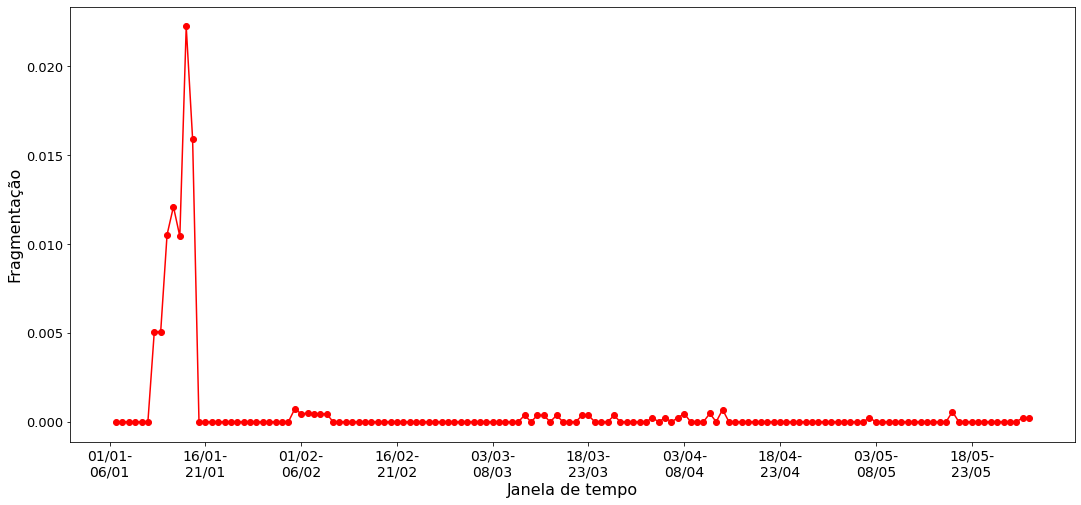

In [9]:
#clustering_coefficient: green, fragmentation = red, frag_cliques = purple
#Fragmentação CORRETA!

plt.figure(figsize=(18,8))
x_ticks_1 = [0,15,30,45,60,75,90,105,120,135]
x_ticks_2 = ['01/01-\n06/01','16/01-\n21/01','01/02-\n06/02','16/02-\n21/02','03/03-\n08/03','18/03-\n23/03','03/04-\n08/04','18/04-\n23/04','03/05-\n08/05', '18/05-\n23/05']
plt.xticks(x_ticks_1, x_ticks_2, fontsize = 14)
plt.yticks(fontsize = 13)

plt.scatter(x,metricas['fragmentation'], color = 'red')
plt.plot(x,metricas['fragmentation'], color = 'red')


plt.xlabel("Janela de tempo", size = 16)
plt.ylabel("Fragmentação", size = 16)
plt.show()

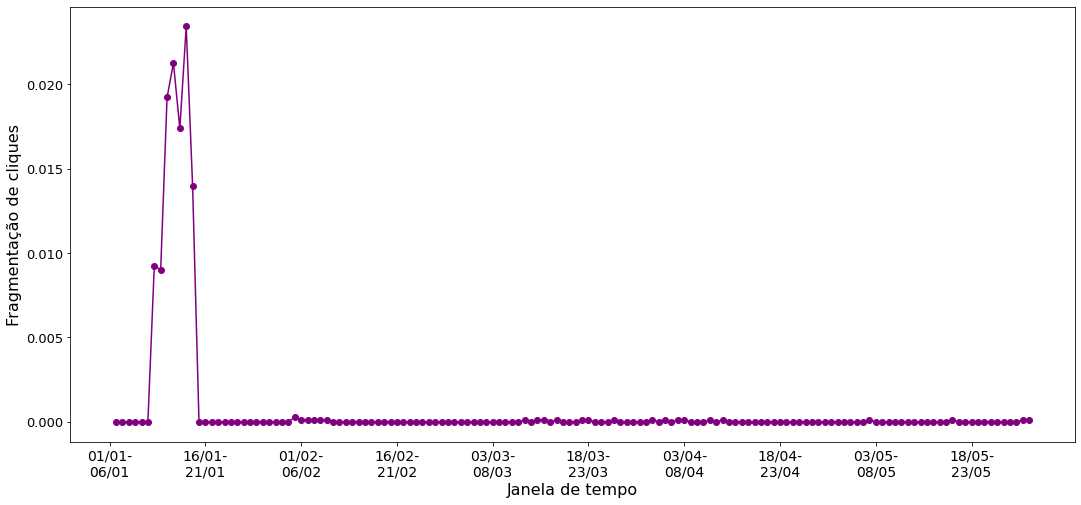

In [23]:
#clustering_coefficient: green, fragmentation = red, frag_cliques = purple

plt.figure(figsize=(18,8))
x_ticks_1 = [0,15,30,45,60,75,90,105,120,135]
x_ticks_2 = ['01/01-\n06/01','16/01-\n21/01','01/02-\n06/02','16/02-\n21/02','03/03-\n08/03','18/03-\n23/03','03/04-\n08/04','18/04-\n23/04','03/05-\n08/05', '18/05-\n23/05']
plt.xticks(x_ticks_1, x_ticks_2, fontsize = 14)
plt.yticks(fontsize = 13)

plt.scatter(x,metricas['frag_cliques'], color = 'purple')
plt.plot(x,metricas['frag_cliques'], color = 'purple')


plt.xlabel("Janela de tempo", size = 16)
plt.ylabel("Fragmentação de cliques", size = 16)
plt.show()

In [7]:
string2 = string.replace("\n", "")
print(string2)

abcd  e


In [8]:
tweet = ["abcd \n e", "fghij \n k"]
print(tweet)
tweet2 = [token.replace("\n", "") for token in tweet]
print(tweet2)

['abcd \n e', 'fghij \n k']
['abcd  e', 'fghij  k']


In [9]:
#Analisar base grande do Twitter:

#1. Gerar janelas
#2. Calcular métricas (ver as funções aqui e no .py, número de janelas arquivo destino?)
#3. Gerar gráfico (lembrar de nomear corretamente as janelas)

#4. (no Cores) Analisar informações do gráfico e fazer paralelos com eventos

inicio = "1-1"
fim = "31-5"
janela = 5 #6 dias na verdade pq a função é idiota 
deslize =1 

agrupaPorJanela2(inicio, fim, janela,deslize)

janela aumentou, agora vai ate 7-1

E o dia agora é2-1

janela aumentou, agora vai ate 8-1

E o dia agora é3-1

janela aumentou, agora vai ate 9-1

E o dia agora é4-1

janela aumentou, agora vai ate 10-1

E o dia agora é5-1

janela aumentou, agora vai ate 11-1

E o dia agora é6-1

janela aumentou, agora vai ate 12-1

E o dia agora é7-1

janela aumentou, agora vai ate 13-1

E o dia agora é8-1

janela aumentou, agora vai ate 14-1

E o dia agora é9-1

janela aumentou, agora vai ate 15-1

E o dia agora é10-1

janela aumentou, agora vai ate 16-1

E o dia agora é11-1

janela aumentou, agora vai ate 17-1

E o dia agora é12-1

janela aumentou, agora vai ate 18-1

E o dia agora é13-1

janela aumentou, agora vai ate 19-1

E o dia agora é14-1

janela aumentou, agora vai ate 20-1

E o dia agora é15-1

janela aumentou, agora vai ate 21-1

E o dia agora é16-1

janela aumentou, agora vai ate 22-1

E o dia agora é17-1

janela aumentou, agora vai ate 23-1

E o dia agora é18-1

janela aumentou, agora va

In [10]:
agrupaPorJanela(inicio, fim, janela,deslize) #pra ter as datas

janela aumentou, agora vai ate 7-1

E o dia agora é2-1

janela aumentou, agora vai ate 8-1

E o dia agora é3-1

janela aumentou, agora vai ate 9-1

E o dia agora é4-1

janela aumentou, agora vai ate 10-1

E o dia agora é5-1

janela aumentou, agora vai ate 11-1

E o dia agora é6-1

janela aumentou, agora vai ate 12-1

E o dia agora é7-1

janela aumentou, agora vai ate 13-1

E o dia agora é8-1

janela aumentou, agora vai ate 14-1

E o dia agora é9-1

janela aumentou, agora vai ate 15-1

E o dia agora é10-1

janela aumentou, agora vai ate 16-1

E o dia agora é11-1

janela aumentou, agora vai ate 17-1

E o dia agora é12-1

janela aumentou, agora vai ate 18-1

E o dia agora é13-1

janela aumentou, agora vai ate 19-1

E o dia agora é14-1

janela aumentou, agora vai ate 20-1

E o dia agora é15-1

janela aumentou, agora vai ate 21-1

E o dia agora é16-1

janela aumentou, agora vai ate 22-1

E o dia agora é17-1

janela aumentou, agora vai ate 23-1

E o dia agora é18-1

janela aumentou, agora va

# REcalculando fragmentação pra base grande com lema

In [3]:
#Rodar a partir daqui de novo
#ATENÇÃO À PASTA COM AS JANELAS!
inicial = 0
final = 143
destino = "Fragmentacao_base_grande_com_lema"
append = False

networkMetrics.principal4(inicial, final, destino, append)

Janela  0
escrevendo Fragmentação no arquivo
Janela  1
escrevendo Fragmentação no arquivo
Janela  2
escrevendo Fragmentação no arquivo
Janela  3
escrevendo Fragmentação no arquivo
Janela  4
escrevendo Fragmentação no arquivo
Janela  5
escrevendo Fragmentação no arquivo
Janela  6
escrevendo Fragmentação no arquivo
Janela  7
escrevendo Fragmentação no arquivo
Janela  8
escrevendo Fragmentação no arquivo
Janela  9
escrevendo Fragmentação no arquivo
Janela  10
escrevendo Fragmentação no arquivo
Janela  11
escrevendo Fragmentação no arquivo
Janela  12
escrevendo Fragmentação no arquivo
Janela  13
escrevendo Fragmentação no arquivo
Janela  14
escrevendo Fragmentação no arquivo
Janela  15
escrevendo Fragmentação no arquivo
Janela  16
escrevendo Fragmentação no arquivo
Janela  17
escrevendo Fragmentação no arquivo
Janela  18
escrevendo Fragmentação no arquivo
Janela  19
escrevendo Fragmentação no arquivo
Janela  20
escrevendo Fragmentação no arquivo
Janela  21
escrevendo Fragmentação no arquiv

## Plotando Fragmentação pra base grande com lema

In [5]:


path = "graph/Fragmentacao_base_grande_com_lema.csv"
frag,j = plot_fragmentacao(path)

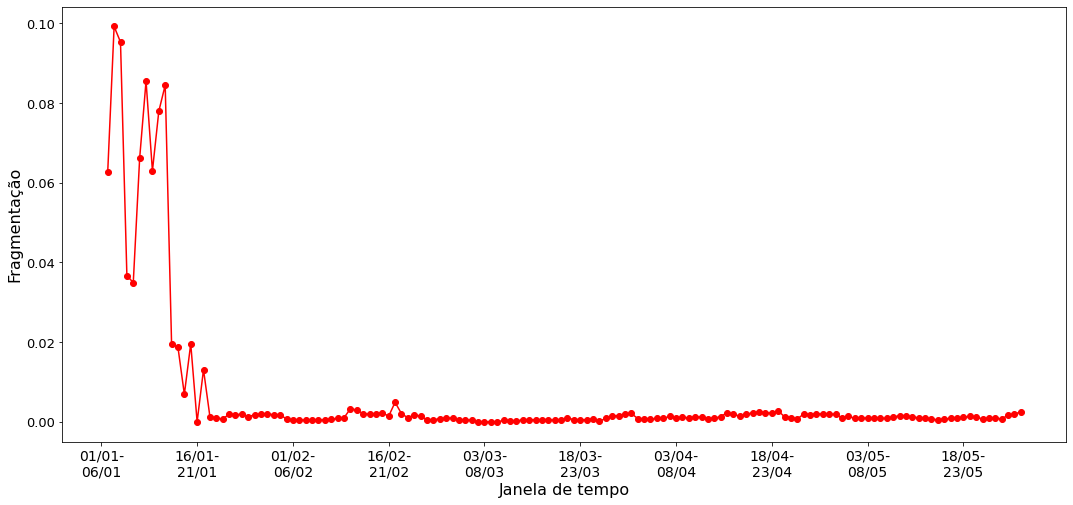

In [5]:
x = [i for i in range(1,j)]  #j é o número total de linhas do csv, incluindo o cabeçalho, por isso o range funciona


plt.figure(figsize=(18,8))
x_ticks_1 = [0,15,30,45,60,75,90,105,120,135]
x_ticks_2 = ['01/01-\n06/01','16/01-\n21/01','01/02-\n06/02','16/02-\n21/02','03/03-\n08/03','18/03-\n23/03','03/04-\n08/04','18/04-\n23/04','03/05-\n08/05', '18/05-\n23/05']
plt.xticks(x_ticks_1, x_ticks_2, fontsize = 14)
plt.yticks(fontsize = 13)

plt.scatter(x,frag['fragmentation'], color = 'red')
plt.plot(x,frag['fragmentation'], color = 'red')


plt.xlabel("Janela de tempo", size = 16)
plt.ylabel("Fragmentação", size = 16)
plt.show()

# Calculando métricas da base grande com lema

In [6]:
#alterar a função pra fazer aos poucos!!

networkMetrics.principal(144, 'resultados_base_grande_2020_jan_maio')

graph


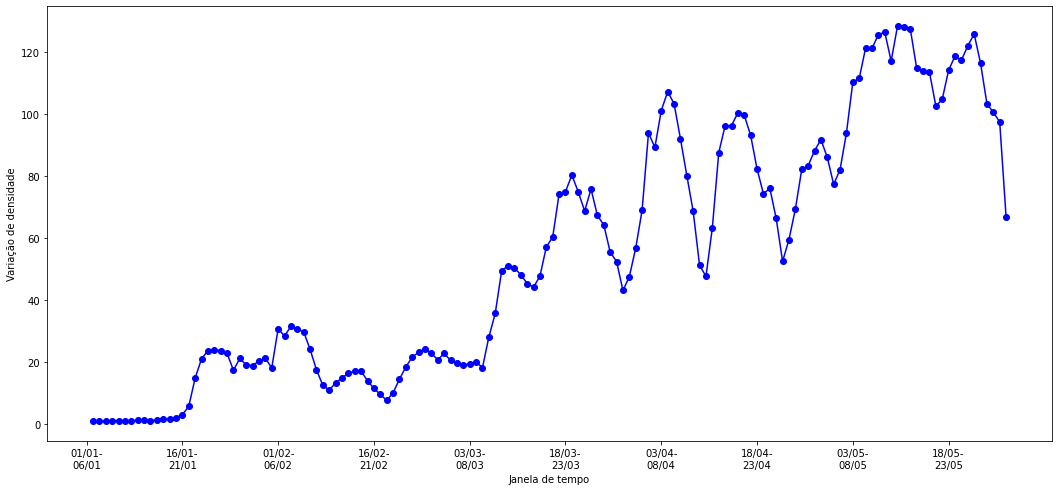

In [11]:
#Plot COVID
path = "graph/resultados_base_grande_2020_jan_maio.csv"
metricas,j = plot_metricas_csv2(path)
x = [i for i in range(1,j)]
plt.figure(figsize=(18,8))
x_ticks_1 = [0,15,30,45,60,75,90,105,120,135]
x_ticks_2 = ['01/01-\n06/01','16/01-\n21/01','01/02-\n06/02','16/02-\n21/02','03/03-\n08/03','18/03-\n23/03','03/04-\n08/04','18/04-\n23/04','03/05-\n08/05', '18/05-\n23/05']

plt.xticks(x_ticks_1, x_ticks_2)
plt.scatter(x,metricas['var_densidade'], color = 'blue')
plt.plot(x,metricas['var_densidade'], color = 'blue')

plt.xlabel("Janela de tempo")
plt.ylabel("Variação de densidade")
plt.show()

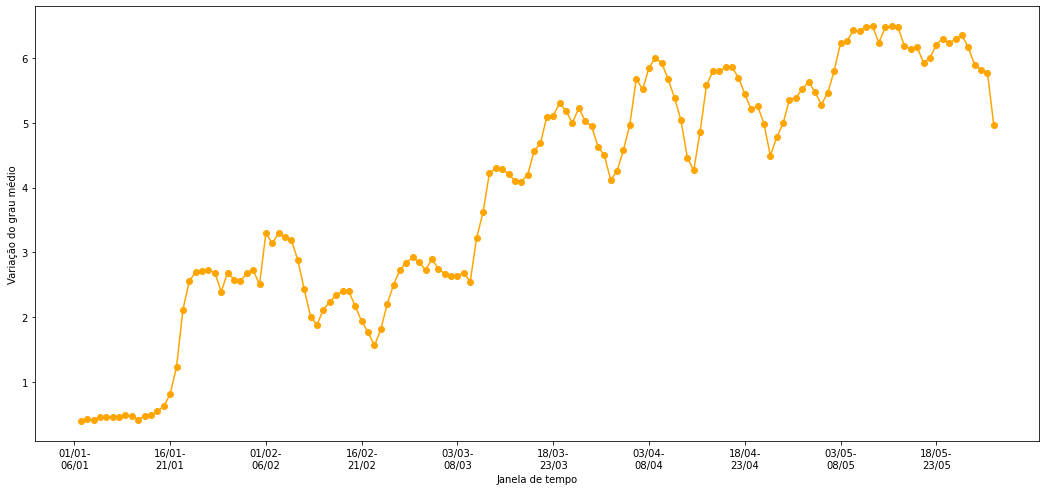

In [12]:

plt.figure(figsize=(18,8))
x_ticks_1 = [0,15,30,45,60,75,90,105,120,135]
x_ticks_2 = ['01/01-\n06/01','16/01-\n21/01','01/02-\n06/02','16/02-\n21/02','03/03-\n08/03','18/03-\n23/03','03/04-\n08/04','18/04-\n23/04','03/05-\n08/05', '18/05-\n23/05']
plt.xticks(x_ticks_1, x_ticks_2)

plt.scatter(x,metricas['var_network_degree'], color = 'orange')
plt.plot(x,metricas['var_network_degree'], color = 'orange')


plt.xlabel("Janela de tempo")
plt.ylabel("Variação do grau médio")
plt.show()

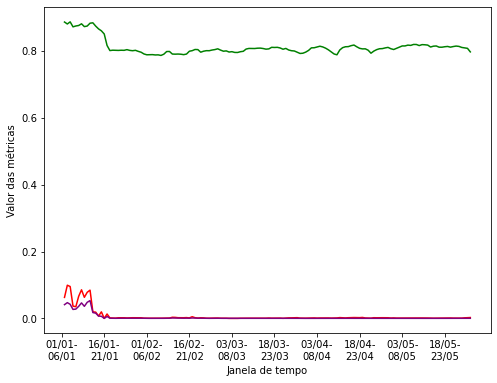

In [8]:
#observe que aqui a fragmentação veio de um arquivo (e portanto de uma variável) diferente

plt.figure(figsize=(8,6))
x_ticks_1 = [0,15,30,45,60,75,90,105,120,135]
x_ticks_2 = ['01/01-\n06/01','16/01-\n21/01','01/02-\n06/02','16/02-\n21/02','03/03-\n08/03','18/03-\n23/03','03/04-\n08/04','18/04-\n23/04','03/05-\n08/05', '18/05-\n23/05']
plt.xticks(x_ticks_1, x_ticks_2)


#plt.scatter(x,metricas['clustering_coefficient'], color = 'green')
plt.plot(x,metricas['clustering_coefficient'], color = 'green')
#plt.scatter(x,metricas['fragmentation'], color = 'red')
plt.plot(x,frag['fragmentation'], color = 'red')
#plt.scatter(x,metricas['frag_cliques'], color = 'purple')
plt.plot(x,metricas['frag_cliques'], color = 'purple')
#plt.title("variação de densidade 03/2020 a 05/2020")


plt.xlabel("Janela de tempo")
plt.ylabel("Valor das métricas")
plt.show()

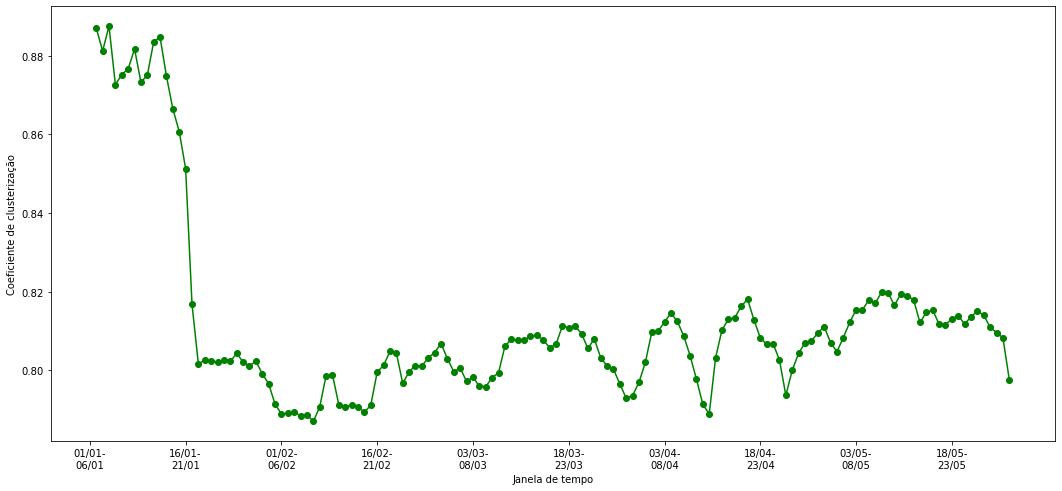

In [9]:
plt.figure(figsize=(18,8))
x_ticks_1 = [0,15,30,45,60,75,90,105,120,135]
x_ticks_2 = ['01/01-\n06/01','16/01-\n21/01','01/02-\n06/02','16/02-\n21/02','03/03-\n08/03','18/03-\n23/03','03/04-\n08/04','18/04-\n23/04','03/05-\n08/05', '18/05-\n23/05']
plt.xticks(x_ticks_1, x_ticks_2)


plt.scatter(x,metricas['clustering_coefficient'], color = 'green')
plt.plot(x,metricas['clustering_coefficient'], color = 'green')
#plt.scatter(x,metricas['fragmentation'], color = 'red')
#plt.plot(x,frag['fragmentation'], color = 'red')
#plt.scatter(x,metricas['frag_cliques'], color = 'purple')
#plt.plot(x,metricas['frag_cliques'], color = 'purple')
#plt.title("variação de densidade 03/2020 a 05/2020")


plt.xlabel("Janela de tempo")
plt.ylabel("Coeficiente de clusterização")
plt.show()

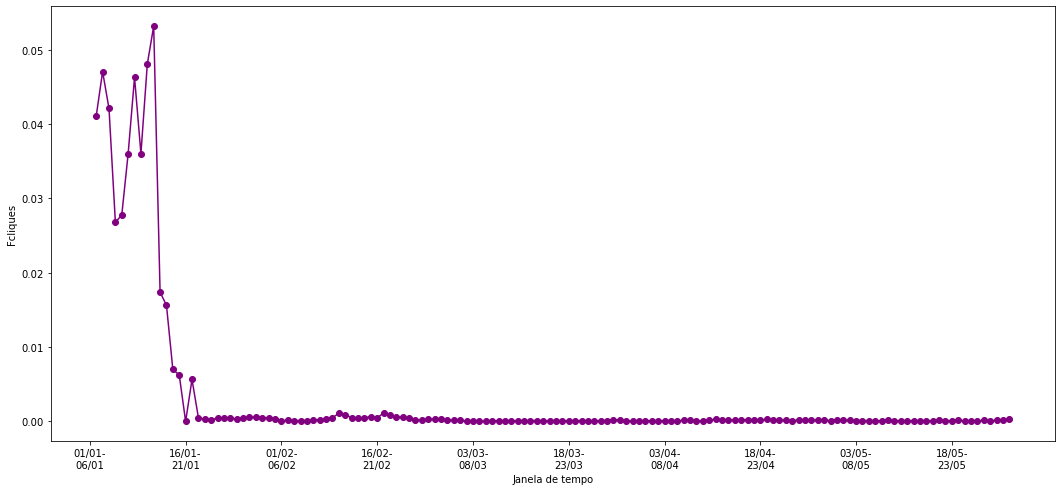

In [10]:
plt.figure(figsize=(18,8))
x_ticks_1 = [0,15,30,45,60,75,90,105,120,135]
x_ticks_2 = ['01/01-\n06/01','16/01-\n21/01','01/02-\n06/02','16/02-\n21/02','03/03-\n08/03','18/03-\n23/03','03/04-\n08/04','18/04-\n23/04','03/05-\n08/05', '18/05-\n23/05']
plt.xticks(x_ticks_1, x_ticks_2)


#plt.scatter(x,metricas['clustering_coefficient'], color = 'green')
#plt.plot(x,metricas['clustering_coefficient'], color = 'green')
#plt.scatter(x,metricas['fragmentation'], color = 'red')
#plt.plot(x,frag['fragmentation'], color = 'red')
plt.scatter(x,metricas['frag_cliques'], color = 'purple')
plt.plot(x,metricas['frag_cliques'], color = 'purple')
#plt.title("variação de densidade 03/2020 a 05/2020")


plt.xlabel("Janela de tempo")
plt.ylabel("Fcliques")
plt.show()

# REcalculando métricas da base pequena (com lema)

In [4]:
#Dessa vez, o cálculo da fragmentação está correto!
inicial = 0
final = 64   #a última janela com algum texto é de 17/05 a 22/05
destino = "MetricasBasePequena_F_true"
append = False
networkMetrics.principal3(inicial, final, destino, append)

Janela  0
escrevendo métricas no arquivo
Janela  1
escrevendo métricas no arquivo
Janela  2
escrevendo métricas no arquivo
Janela  3
escrevendo métricas no arquivo
Janela  4
escrevendo métricas no arquivo
Janela  5
escrevendo métricas no arquivo
Janela  6
escrevendo métricas no arquivo
Janela  7
escrevendo métricas no arquivo
Janela  8
escrevendo métricas no arquivo
Janela  9
escrevendo métricas no arquivo
Janela  10
escrevendo métricas no arquivo
Janela  11
escrevendo métricas no arquivo
Janela  12
escrevendo métricas no arquivo
Janela  13
escrevendo métricas no arquivo
Janela  14
escrevendo métricas no arquivo
Janela  15
escrevendo métricas no arquivo
Janela  16
escrevendo métricas no arquivo
Janela  17
escrevendo métricas no arquivo
Janela  18
escrevendo métricas no arquivo
Janela  19
escrevendo métricas no arquivo
Janela  20
escrevendo métricas no arquivo
Janela  21
escrevendo métricas no arquivo
Janela  22
escrevendo métricas no arquivo
Janela  23
escrevendo métricas no arquivo
Ja

In [ ]:
#IPC: Não tem texto suficiente entre 15/04 e 5/5. Então tem uma janela de 14/04 a 19/04, e depois pula pra 
#     06/05 a 11/05.

<Figure size 576x432 with 0 Axes>

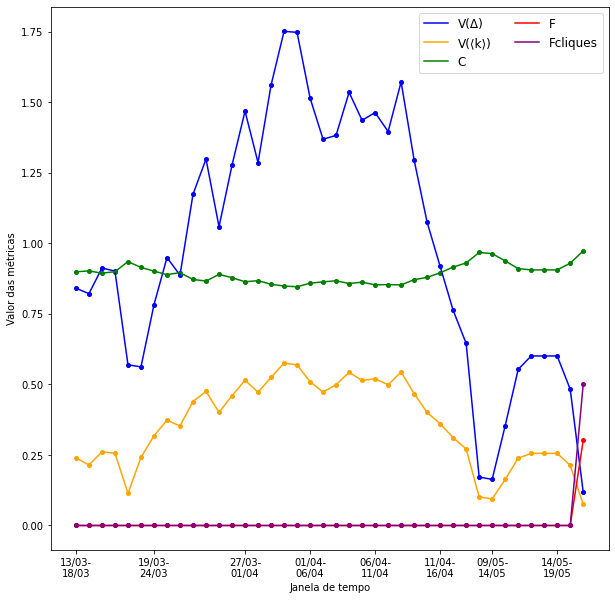

In [3]:
path = "graph/MetricasBasePequena_F_true.csv"
metricas,j = plot_metricas_csv2(path)
x = [i for i in range(1,j)]
plt.figure(figsize=(8,6))
#x_ticks_1 = [1,5,10,15,20,25,32,35,40]
#x_ticks_2 = ['13/03-\n18/03','18/03-\n23/03','23/03-\n28/03','29/03-\n03/04','03/04-\n08/04','08/04-\n13/04','06/05-\n11/05','13/05-\n18/05','18/05-\n23/05']
x_ticks_1 = [1,7,14,19,24,29,33,38]
x_ticks_2 = ['13/03-\n18/03','19/03-\n24/03','27/03-\n01/04','01/04-\n06/04','06/04-\n11/04','11/04-\n16/04','09/05-\n14/05','14/05-\n19/05']


plt.figure(figsize=(10,10))
plt.xticks(x_ticks_1, x_ticks_2)
plt.scatter(x,metricas['var_densidade'], color = 'blue', s=16)
plt.plot(x,metricas['var_densidade'], color = 'blue', label= 'V('+u"\u0394"+')')
plt.scatter(x,metricas['var_network_degree'], color = 'orange', s=16)
plt.plot(x,metricas['var_network_degree'], color = 'orange', label = 'V('+u"\u27e8"+'k'+u"\u27e9"+')')
plt.scatter(x,metricas['clustering_coefficient'], color = 'green', s=16)
plt.plot(x,metricas['clustering_coefficient'], color = 'green', label = 'C')
plt.scatter(x,metricas['fragmentation'], color = 'red', s=16)
plt.plot(x,metricas['fragmentation'], color = 'red', label = 'F')
plt.scatter(x,metricas['frag_cliques'], color = 'purple', s=16)
plt.plot(x,metricas['frag_cliques'], color = 'purple', label = 'Fcliques')
#plt.title("variação de densidade 03/2020 a 05/2020")
plt.xlabel("Janela de tempo")
plt.ylabel("Valor das métricas")
plt.legend(prop={'size': 12}, ncol = 2)
plt.show()

# Calculando métricas pra base grande reduzida com lema

In [3]:
inicial = 0
final = 143
destino = "MetricasBaseReduzidaLema_F_true"
append = True
networkMetrics.principal3(inicial, final, destino, append)

Janela  0
escrevendo métricas no arquivo
Janela  1
escrevendo métricas no arquivo
Janela  2
escrevendo métricas no arquivo
Janela  3
escrevendo métricas no arquivo
Janela  4
escrevendo métricas no arquivo
Janela  5
escrevendo métricas no arquivo
Janela  6
escrevendo métricas no arquivo
Janela  7
escrevendo métricas no arquivo
Janela  8
escrevendo métricas no arquivo
Janela  9
escrevendo métricas no arquivo
Janela  10
escrevendo métricas no arquivo
Janela  11
escrevendo métricas no arquivo
Janela  12
escrevendo métricas no arquivo
Janela  13
escrevendo métricas no arquivo
Janela  14
escrevendo métricas no arquivo
Janela  15
escrevendo métricas no arquivo
Janela  16
escrevendo métricas no arquivo
Janela  17
escrevendo métricas no arquivo
Janela  18
escrevendo métricas no arquivo
Janela  19
escrevendo métricas no arquivo
Janela  20
escrevendo métricas no arquivo
Janela  21
escrevendo métricas no arquivo
Janela  22
escrevendo métricas no arquivo
Janela  23
escrevendo métricas no arquivo
Ja

<Figure size 576x432 with 0 Axes>

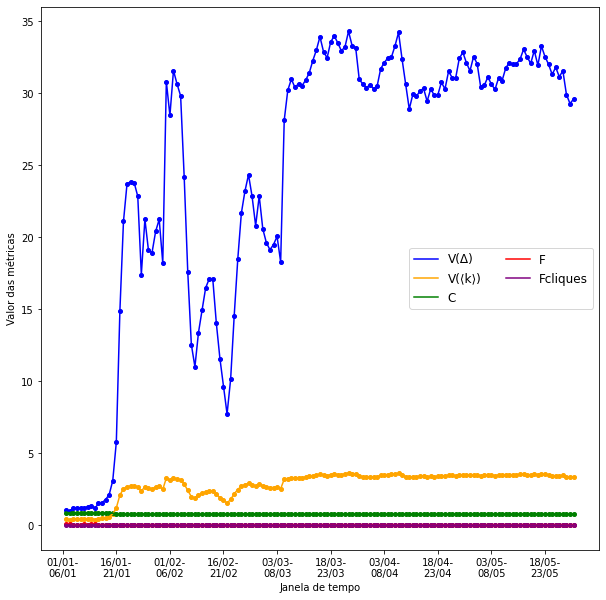

In [4]:
#Plotando metricas pra base grande reduzida com lema
path = "graph/MetricasBaseReduzidaLema_F_true.csv"
metricas,j = plot_metricas_csv2(path)
x = [i for i in range(1,j)]
plt.figure(figsize=(8,6))
x_ticks_1 = [0,15,30,45,60,75,90,105,120,135]
x_ticks_2 = ['01/01-\n06/01','16/01-\n21/01','01/02-\n06/02','16/02-\n21/02','03/03-\n08/03','18/03-\n23/03','03/04-\n08/04','18/04-\n23/04','03/05-\n08/05', '18/05-\n23/05']

plt.figure(figsize=(10,10))
plt.xticks(x_ticks_1, x_ticks_2)
plt.scatter(x,metricas['var_densidade'], color = 'blue', s=16)
plt.plot(x,metricas['var_densidade'], color = 'blue', label= 'V('+u"\u0394"+')')
plt.scatter(x,metricas['var_network_degree'], color = 'orange', s=16)
plt.plot(x,metricas['var_network_degree'], color = 'orange', label = 'V('+u"\u27e8"+'k'+u"\u27e9"+')')
plt.scatter(x,metricas['clustering_coefficient'], color = 'green', s=16)
plt.plot(x,metricas['clustering_coefficient'], color = 'green', label = 'C')
plt.scatter(x,metricas['fragmentation'], color = 'red', s=16)
plt.plot(x,metricas['fragmentation'], color = 'red', label = 'F')
plt.scatter(x,metricas['frag_cliques'], color = 'purple', s=16)
plt.plot(x,metricas['frag_cliques'], color = 'purple', label = 'Fcliques')
#plt.title("variação de densidade 03/2020 a 05/2020")
plt.xlabel("Janela de tempo")
plt.ylabel("Valor das métricas")
plt.legend(prop={'size': 12}, ncol = 2)
plt.show()

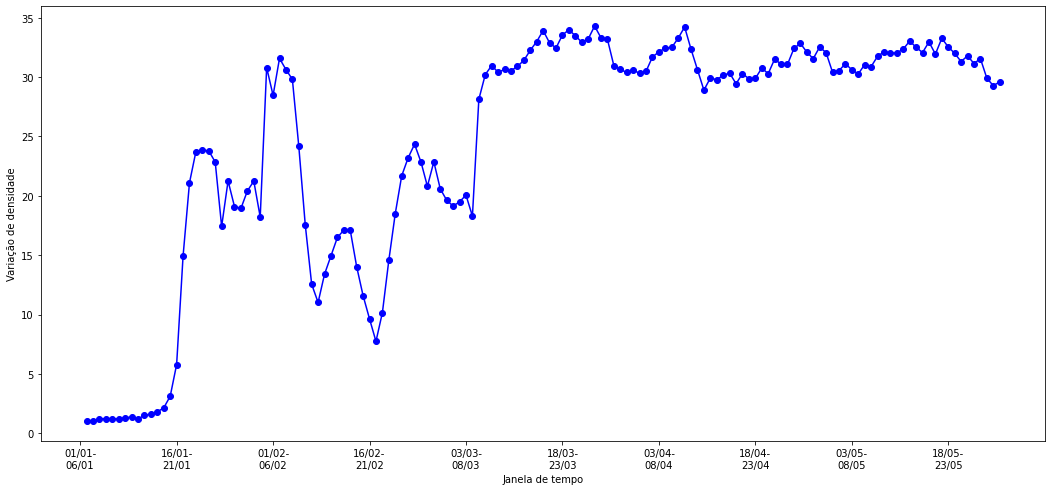

In [5]:
plt.figure(figsize=(18,8))
x_ticks_1 = [0,15,30,45,60,75,90,105,120,135]
x_ticks_2 = ['01/01-\n06/01','16/01-\n21/01','01/02-\n06/02','16/02-\n21/02','03/03-\n08/03','18/03-\n23/03','03/04-\n08/04','18/04-\n23/04','03/05-\n08/05', '18/05-\n23/05']

plt.xticks(x_ticks_1, x_ticks_2)
plt.scatter(x,metricas['var_densidade'], color = 'blue')
plt.plot(x,metricas['var_densidade'], color = 'blue')

plt.xlabel("Janela de tempo")
plt.ylabel("Variação de densidade")
plt.show()

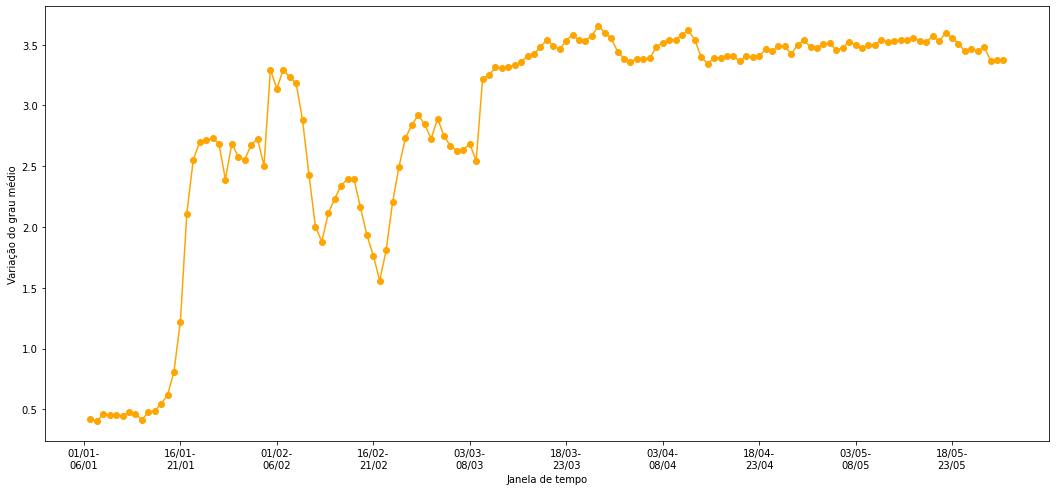

In [6]:
plt.figure(figsize=(18,8))
x_ticks_1 = [0,15,30,45,60,75,90,105,120,135]
x_ticks_2 = ['01/01-\n06/01','16/01-\n21/01','01/02-\n06/02','16/02-\n21/02','03/03-\n08/03','18/03-\n23/03','03/04-\n08/04','18/04-\n23/04','03/05-\n08/05', '18/05-\n23/05']
plt.xticks(x_ticks_1, x_ticks_2)

plt.scatter(x,metricas['var_network_degree'], color = 'orange')
plt.plot(x,metricas['var_network_degree'], color = 'orange')


plt.xlabel("Janela de tempo")
plt.ylabel("Variação do grau médio")
plt.show()

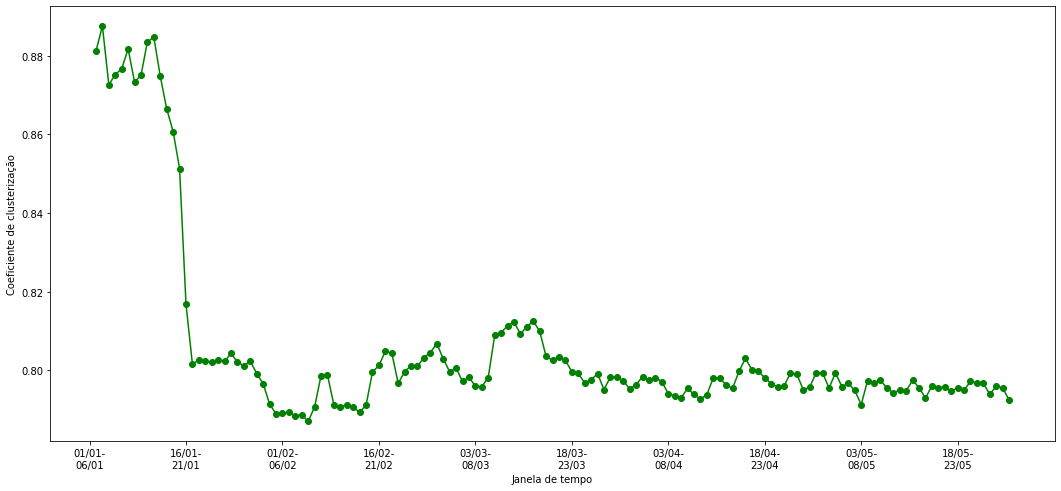

In [7]:
plt.figure(figsize=(18,8))
x_ticks_1 = [0,15,30,45,60,75,90,105,120,135]
x_ticks_2 = ['01/01-\n06/01','16/01-\n21/01','01/02-\n06/02','16/02-\n21/02','03/03-\n08/03','18/03-\n23/03','03/04-\n08/04','18/04-\n23/04','03/05-\n08/05', '18/05-\n23/05']
plt.xticks(x_ticks_1, x_ticks_2)


plt.scatter(x,metricas['clustering_coefficient'], color = 'green')
plt.plot(x,metricas['clustering_coefficient'], color = 'green')
#plt.scatter(x,metricas['fragmentation'], color = 'red')
#plt.plot(x,frag['fragmentation'], color = 'red')
#plt.scatter(x,metricas['frag_cliques'], color = 'purple')
#plt.plot(x,metricas['frag_cliques'], color = 'purple')
#plt.title("variação de densidade 03/2020 a 05/2020")


plt.xlabel("Janela de tempo")
plt.ylabel("Coeficiente de clusterização")
plt.show()

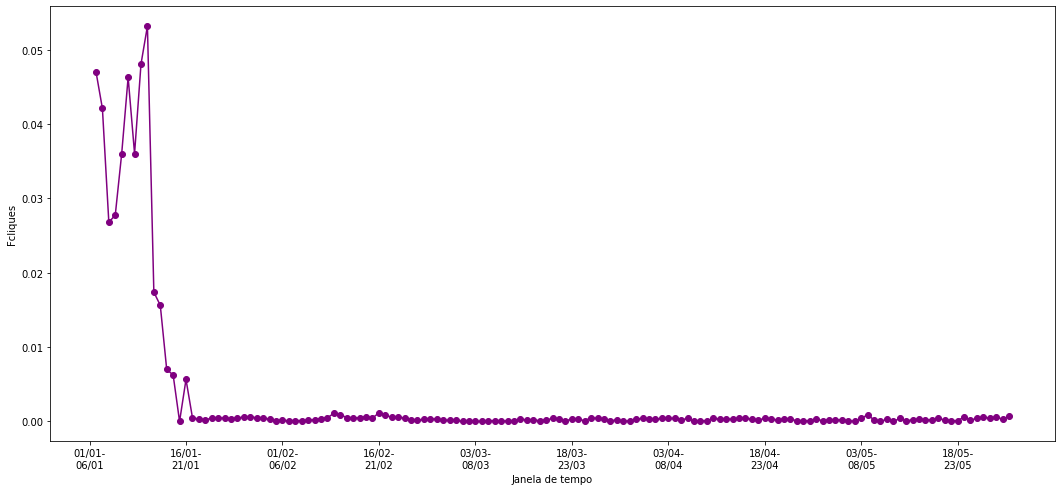

In [8]:
plt.figure(figsize=(18,8))
x_ticks_1 = [0,15,30,45,60,75,90,105,120,135]
x_ticks_2 = ['01/01-\n06/01','16/01-\n21/01','01/02-\n06/02','16/02-\n21/02','03/03-\n08/03','18/03-\n23/03','03/04-\n08/04','18/04-\n23/04','03/05-\n08/05', '18/05-\n23/05']
plt.xticks(x_ticks_1, x_ticks_2)


#plt.scatter(x,metricas['clustering_coefficient'], color = 'green')
#plt.plot(x,metricas['clustering_coefficient'], color = 'green')
#plt.scatter(x,metricas['fragmentation'], color = 'red')
#plt.plot(x,frag['fragmentation'], color = 'red')
plt.scatter(x,metricas['frag_cliques'], color = 'purple')
plt.plot(x,metricas['frag_cliques'], color = 'purple')
#plt.title("variação de densidade 03/2020 a 05/2020")


plt.xlabel("Janela de tempo")
plt.ylabel("Fcliques")
plt.show()

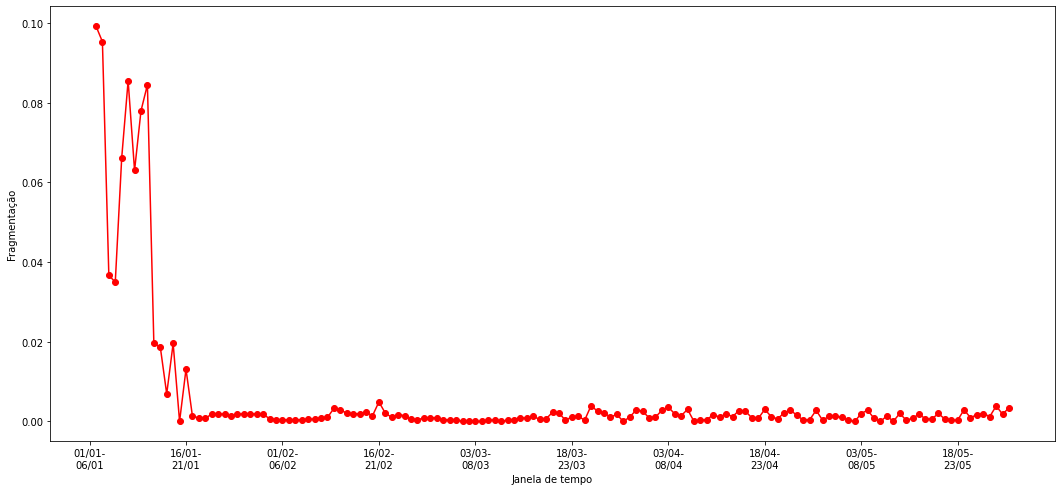

In [10]:
plt.figure(figsize=(18,8))
x_ticks_1 = [0,15,30,45,60,75,90,105,120,135]
x_ticks_2 = ['01/01-\n06/01','16/01-\n21/01','01/02-\n06/02','16/02-\n21/02','03/03-\n08/03','18/03-\n23/03','03/04-\n08/04','18/04-\n23/04','03/05-\n08/05', '18/05-\n23/05']
plt.xticks(x_ticks_1, x_ticks_2)


#plt.scatter(x,metricas['clustering_coefficient'], color = 'green')
#plt.plot(x,metricas['clustering_coefficient'], color = 'green')
plt.scatter(x,metricas['fragmentation'], color = 'red')
plt.plot(x,metricas['fragmentation'], color = 'red')
#plt.scatter(x,metricas['frag_cliques'], color = 'purple')
#plt.plot(x,metricas['frag_cliques'], color = 'purple')
#plt.title("variação de densidade 03/2020 a 05/2020")


plt.xlabel("Janela de tempo")
plt.ylabel("Fragmentação")
plt.show()

# Recalculando métricas pra base pouco conexa

In [19]:
#Dessa vez, o cálculo da fragmentação está correto!
inicial = 0
final = 0  
destino = "MetricasPoucoConexa"
append = False
networkMetrics.principal3(inicial, final, destino, append)

Janela  0
escrevendo métricas no arquivo
graph


In [ ]:
#Fragmentação deu 0.2336

# REcalculando métricas da transição entre as bases

# Conexa pra conexa

In [5]:
#Dps lembrar de calcular da pouco conexa pra conexa

#Dessa vez, o cálculo da fragmentação está correto!
inicial = 0
final = 8
destino = "MetricasConexa_p_Conexa_F_true"
append = False
networkMetrics.principal3(inicial, final, destino, append)

Janela  0
escrevendo métricas no arquivo
Janela  1
escrevendo métricas no arquivo
Janela  2
escrevendo métricas no arquivo
Janela  3
escrevendo métricas no arquivo
Janela  4
escrevendo métricas no arquivo
Janela  5
escrevendo métricas no arquivo
Janela  6
escrevendo métricas no arquivo
Janela  7
escrevendo métricas no arquivo
Janela  8
escrevendo métricas no arquivo
graph


<Figure size 936x432 with 0 Axes>

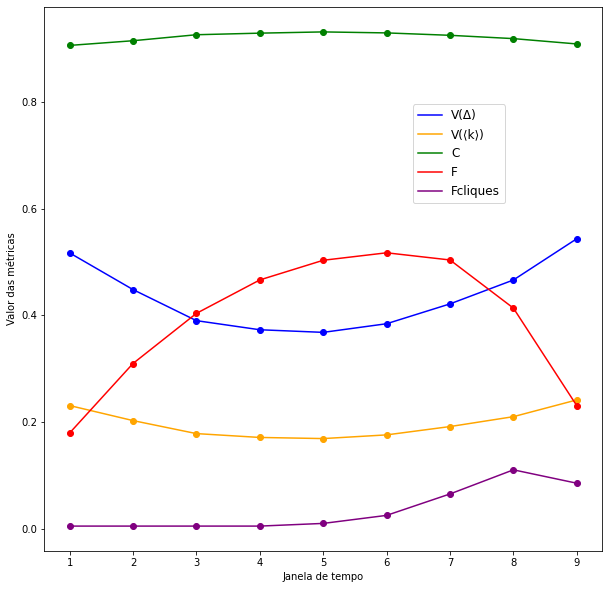

In [49]:
#Plotando conexa pra conexa


path = "graph/MetricasConexa_p_Conexa_F_true.csv"
metricas,j = plot_metricas_csv2(path)
x = [i for i in range(1,j)]
plt.figure(figsize=(13,6))
x_ticks_1 = [1,2,3,4,5,6,7,8,9]
x_ticks_2 = ['1','2','3','4','5','6','7','8', '9']

plt.figure(figsize=(10,10))
plt.xticks(x_ticks_1, x_ticks_2)
plt.scatter(x,metricas['var_densidade'], color = 'blue')
plt.plot(x,metricas['var_densidade'], color = 'blue', label= 'V('+u"\u0394"+')')
plt.scatter(x,metricas['var_network_degree'], color = 'orange')
plt.plot(x,metricas['var_network_degree'], color = 'orange', label = 'V('+u"\u27e8"+'k'+u"\u27e9"+')')
plt.scatter(x,metricas['clustering_coefficient'], color = 'green')
plt.plot(x,metricas['clustering_coefficient'], color = 'green', label = 'C')
plt.scatter(x,metricas['fragmentation'], color = 'red')
plt.plot(x,metricas['fragmentation'], color = 'red', label = 'F')
plt.scatter(x,metricas['frag_cliques'], color = 'purple')
plt.plot(x,metricas['frag_cliques'], color = 'purple', label = 'Fcliques')
#plt.title("variação de densidade 03/2020 a 05/2020")
plt.xlabel("Janela de tempo")
plt.ylabel("Valor das métricas")
plt.legend(prop={'size': 12}, ncol = 1, borderaxespad = 8.1)
plt.show()

In [3]:
#!pip install --upgrade matplotlib --user

In [11]:
!pip install pandas==1.3.3 --user

  Attempting uninstall: pandas
    Found existing installation: pandas 1.3.0
    Uninstalling pandas-1.3.0:
      Successfully uninstalled pandas-1.3.0


In [12]:
#!pip install --upgrade numpy --user

In [50]:
#Desconexa pra conexa


#Dessa vez, o cálculo da fragmentação está correto!
inicial = 0
final = 8
destino = "MetricasDesconexa_p_Conexa_F_true"
append = False
networkMetrics.principal3(inicial, final, destino, append)


Janela  0
escrevendo métricas no arquivo
Janela  1
escrevendo métricas no arquivo
Janela  2
escrevendo métricas no arquivo
Janela  3
escrevendo métricas no arquivo
Janela  4
escrevendo métricas no arquivo
Janela  5
escrevendo métricas no arquivo
Janela  6
escrevendo métricas no arquivo
Janela  7
escrevendo métricas no arquivo
Janela  8
escrevendo métricas no arquivo
graph


<Figure size 936x432 with 0 Axes>

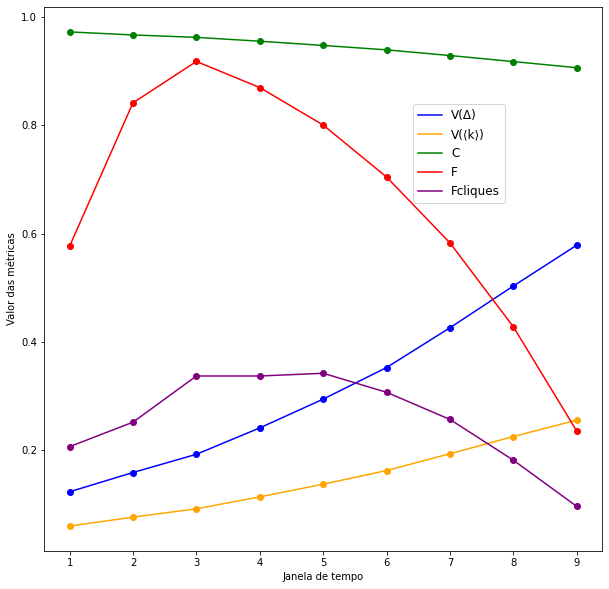

In [51]:

path = "graph/MetricasDesconexa_p_Conexa_F_true.csv"
metricas,j = plot_metricas_csv2(path)
x = [i for i in range(1,j)]
plt.figure(figsize=(13,6))
x_ticks_1 = [1,2,3,4,5,6,7,8,9]
x_ticks_2 = ['1','2','3','4','5','6','7','8', '9']

plt.figure(figsize=(10,10))
plt.xticks(x_ticks_1, x_ticks_2)
plt.scatter(x,metricas['var_densidade'], color = 'blue')
plt.plot(x,metricas['var_densidade'], color = 'blue', label= 'V('+u"\u0394"+')')
plt.scatter(x,metricas['var_network_degree'], color = 'orange')
plt.plot(x,metricas['var_network_degree'], color = 'orange', label = 'V('+u"\u27e8"+'k'+u"\u27e9"+')')
plt.scatter(x,metricas['clustering_coefficient'], color = 'green')
plt.plot(x,metricas['clustering_coefficient'], color = 'green', label = 'C')
plt.scatter(x,metricas['fragmentation'], color = 'red')
plt.plot(x,metricas['fragmentation'], color = 'red', label = 'F')
plt.scatter(x,metricas['frag_cliques'], color = 'purple')
plt.plot(x,metricas['frag_cliques'], color = 'purple', label = 'Fcliques')
#plt.title("variação de densidade 03/2020 a 05/2020")
plt.xlabel("Janela de tempo")
plt.ylabel("Valor das métricas")
plt.legend(prop={'size': 12}, ncol = 1, borderaxespad = 8.1)
plt.show()

# Alguns testes e plots 

In [9]:
networkMetrics.principal(31, 'janeiro_teste')

graph


In [4]:
#faz rede de cliques a partir de arquivo
path = "Janelas/033_4-2_9-2.txt"
arq = open(path)
edges,cliques,qtdNodesInitialState = networkMetrics.extractVectorFromFile(arq)
arq.close()

initial_state_gephi(path,"nodesT33init","edgesT33init")
rede_justaposta_gephi(path,'nodesT33', 'edgesT33')

sucesso, cheque a pasta graph


In [6]:
initial_state_gephi(path,"nodesT33init","edgesT33init")

In [3]:
path = "graph/resultados_base_grande_2020_jan_maio.csv"
metricas,j = plot_metricas_csv2(path)

In [8]:
#fazendo csv so com as métricas interessantes

arq = open('graph/metricas_processadas_jan_maio.csv', 'w+')

arq.write("var_densidade, var_network_degree, clustering_coefficient, fragmentation, frag_cliques\n")

var_densidade = metricas['var_densidade']
var_network_degree = metricas['var_network_degree']
clustering_coefficient = metricas['clustering_coefficient']
fragmentation = metricas['fragmentation']
frag_cliques = metricas['frag_cliques']

for i in range(len(var_densidade)):
    linha = str(var_densidade[i])+", "+str(var_network_degree[i])+", "+str(clustering_coefficient[i])+", "+str(fragmentation[i])+", "+str(frag_cliques[i])+"\n" 
    
    arq.write(linha)

arq.close()

In [6]:
var_densidade

[0.946082250639861,
 1.0408796166954861,
 0.995200173028437,
 1.2375712704818325,
 1.2083786568975747,
 1.23282878866961,
 1.201717835343124,
 1.3151375593417591,
 1.3560339697962562,
 1.1831681347502165,
 1.5333272021213453,
 1.5872512471098146,
 1.7990466574677955,
 2.144066336886662,
 3.1143033237063706,
 5.790610988554428,
 14.907577219979778,
 21.104596807786724,
 23.729076997168967,
 23.850265281467824,
 23.789985730157056,
 22.85041105003618,
 17.419785257398768,
 21.25546139623646,
 19.092759457811322,
 18.94451620603541,
 20.406818709466474,
 21.24764147813145,
 18.21690599984748,
 30.80829740139003,
 28.464048547211156,
 31.58084497470911,
 30.638488648913313,
 29.818219274248733,
 24.170391495345417,
 17.581412454636045,
 12.556263006440075,
 11.017660931660664,
 13.395524706468892,
 14.939799578619047,
 16.491220161764883,
 17.114304762320753,
 17.108058127985053,
 14.03102513602421,
 11.586082551146513,
 9.633683638909043,
 7.741126361355684,
 10.161172054909963,
 14.57256

<Figure size 576x576 with 0 Axes>

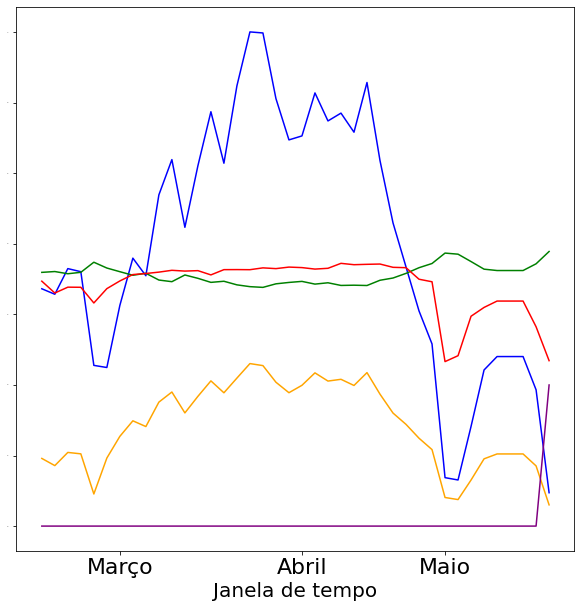

In [27]:
#Plot COVID
path = "graph/deslize_1_resultados_marco_maio_2020.csv"
metricas,j = plot_metricas_csv2(path)
x = [i for i in range(1,j)]
plt.figure(figsize=(8,8))
#x_ticks_1 = [1,5,10,15,20,25,30,35,40]
#x_ticks_2 = ['13/03-\n18/03','18/03-\n23/03','23/03-\n28/03','29/03-\n03/04','03/04-\n08/04','08/04-\n13/04','13/04-\n18/04','13/05-\n18/05','18/05-\n23/05']
x_ticks_1 = [7,21,32]
x_ticks_2 = ['Março', 'Abril', 'Maio']

plt.figure(figsize=(10,10))
plt.xticks(x_ticks_1, x_ticks_2, size = 22)
plt.yticks(size= 0)
#plt.scatter(x,metricas['var_densidade'], color = 'blue')
plt.plot(x,metricas['var_densidade'], color = 'blue', label= 'V('+u"\u0394"+')')
#plt.scatter(x,metricas['var_network_degree'], color = 'orange')
plt.plot(x,metricas['var_network_degree'], color = 'orange', label = 'V('+u"\u27e8"+'k'+u"\u27e9"+')')
#plt.scatter(x,metricas['clustering_coefficient'], color = 'green')
plt.plot(x,metricas['clustering_coefficient'], color = 'green', label = 'C')
#plt.scatter(x,metricas['fragmentation'], color = 'red')
plt.plot(x,metricas['fragmentation'], color = 'red', label = 'F')
#plt.scatter(x,metricas['frag_cliques'], color = 'purple')
plt.plot(x,metricas['frag_cliques'], color = 'purple', label = 'Fcliques')
#plt.title("variação de densidade 03/2020 a 05/2020")
plt.xlabel("Janela de tempo", size = 20)
#plt.ylabel("Valor das métricas", size = 22)
#plt.legend(prop={'size': 15}, ncol = 5)
plt.show()


(0.0, 1.75)

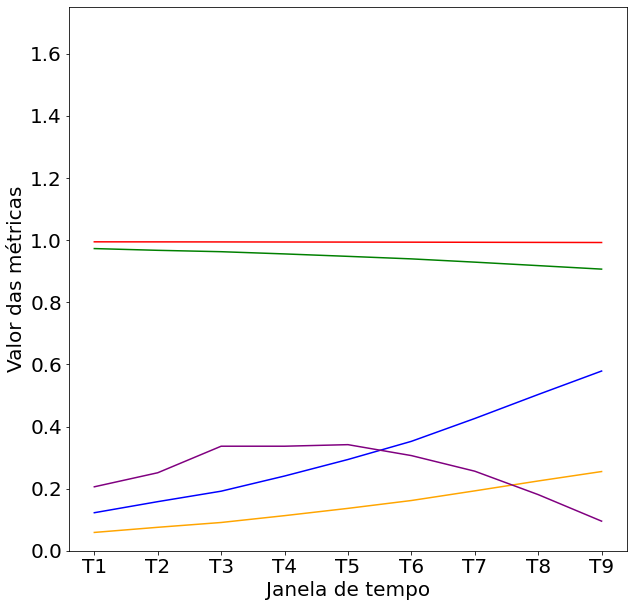

In [68]:
#Desconexa pra conexa PLOT
#PLOTS JUNTOS
#Desconexa pra conexa
x = ["T"+str(i) for i in range(1,10)]
Y = [var_dens_desc_p_conex, var_grau_medio_desc_p_conex, coef_cluster_desc_p_conex, frag_desc_p_conex, frag_cliques_desc_p_conex]

plt.figure(figsize=(10,10))
plt.plot(x,Y[0], color = 'blue', label = 'V('+u"\u0394"+')') #var dens 
#plt.scatter(x,Y[0], color = 'blue', label = 'V('+u"\u0394"+')') #var dens 
plt.plot(x,Y[1], color = 'orange', label = 'V('+u"\u27e8"+'k'+u"\u27e9"+')') #var grau medio
#plt.scatter(x,Y[1], color = 'orange', label = 'V('+u"\u27e8"+'k'+u"\u27e9"+')') #var grau medio
plt.plot(x,Y[2], color = 'green', label = 'C') #coef cluster
#plt.scatter(x,Y[2], color = 'green', label = 'C') #coef cluster
plt.plot(x,Y[3], color = 'red', label = 'F') #Fragmentacao
#plt.scatter(x,Y[3], color = 'red', label = 'F') #Fragmentacao
plt.plot(x,Y[4], color = 'purple', label = 'Fcliques') #fragcliques
#plt.scatter(x,Y[4], color = 'purple', label = 'Fcliques') #fragcliques
plt.xticks(size=20)
plt.xlabel("Janela de tempo", fontsize = 20)
plt.ylabel("Valor das métricas", fontsize = 20)
plt.yticks(size=20)
ax = plt.gca()
ax.set_ylim([0, 1.75])
#plt.legend(prop={'size': 13})

(0.0, 1.77)

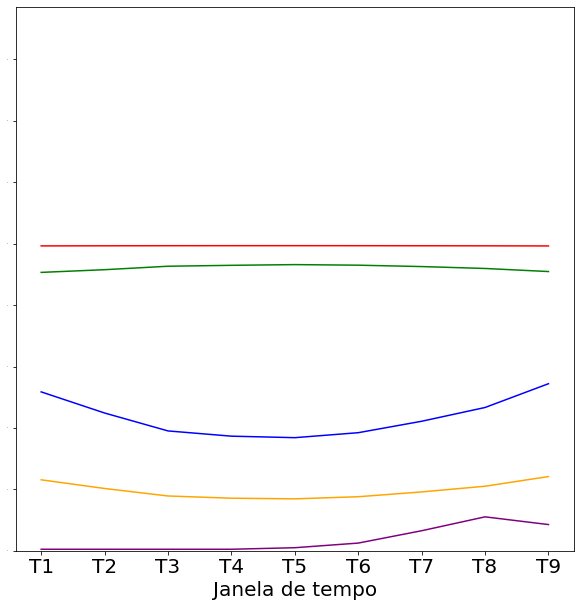

In [65]:
#Conexa pra conexa PLOT

x = ["T"+str(i) for i in range(1,10)]
Y = [var_dens_conex_p_conex, var_grau_medio_conex_p_conex, coef_cluster_conex_p_conex, frag_conex_p_conex, frag_cliques_conex_p_conex]

plt.figure(figsize=(10,10))
plt.plot(x,Y[0], color = 'blue', label = 'V('+u"\u0394"+')') #var dens
#plt.scatter(x,Y[0], color = 'blue', label = 'V('+u"\u0394"+')') #var dens
plt.plot(x,Y[1], color = 'orange', label = 'V('+u"\u27e8"+'k'+u"\u27e9"+')') #var grau medio
#plt.scatter(x,Y[1], color = 'orange', label = 'V('+u"\u27e8"+'k'+u"\u27e9"+')') #var grau medio
plt.plot(x,Y[2], color = 'green', label = 'C') #coef cluster
#plt.scatter(x,Y[2], color = 'green', label = 'C') #coef cluster
plt.plot(x,Y[3], color = 'red', label = 'F') #Fragmentacao
#plt.scatter(x,Y[3], color = 'red', label = 'F') #Fragmentacao
plt.plot(x,Y[4], color = 'purple', label = 'Fcliques') #fragcliques
#plt.scatter(x,Y[4], color = 'purple', label = 'Fcliques') #fragcliques

plt.xticks(size=20)
plt.xlabel("Janela de tempo", fontsize = 20)
#plt.ylabel("Valor das métricas", fontsize = 20)
plt.yticks(size=0)
ax = plt.gca()
ax.set_ylim([0, 1.77])

#plt.legend(prop={'size': 10})

## Testes

In [42]:
reduz_janela("Janelas\TESTE.txt", "Janelas\TESTE_DEST2.txt", 7)

12
inserindo 8
inserindo 2
inserindo 10
inserindo 1
inserindo 9
inserindo 4
inserindo 7
linhas:  ['linha 0\n', 'linha 1\n', 'linha 2\n', 'linha 3\n', 'linha 4\n', 'linha 5\n', 'linha 6\n', 'linha 7\n', 'linha 8\n', 'linha 9\n', 'linha 10\n', 'linha 11\n']
indices:  [1, 2, 4, 7, 8, 9, 10]


In [26]:
rng = np.random.default_rng()

In [18]:
indices = 12 * rng.random((1,7))

indices[0]

array([10.19383006, 11.21747479, 11.05638768,  3.92653636,  4.80413642,
       11.98751915,  7.61569535])

In [27]:
rng.random()

0.8611448267863739

In [31]:
int(rng.random() * 12)

11

In [40]:
l = [6, 5, 3, 2, 4, 9, 11]

l.sort()

l

[2, 3, 4, 5, 6, 9, 11]

In [46]:
pasta = "BLABLA_blabla"
num=15

origem = pasta+"\T"+str(num)+".txt"
print(origem)

BLABLA_blabla\T15.txt


In [3]:
2+2

4